# 帕累托最优分析：NPO、SimNPO 与 TVC 方法对比

本notebook分析不同遗忘学习方法在forget_05和forget_10场景下的表现，
找出各方法在以下三个指标上的帕累托最优解：
- **ES Un (extraction_strength)**: 遗忘集的提取强度，越低越好
- **ES Re (extraction_strength_retain)**: 保留集的提取强度，越高越好  
- **MU (model_utility)**: 模型效用，越高越好

数据来源：
- **NPO/SimNPO**: llama_2_chat 和 phi 文件夹
- **TVC**: hyperparam_search_forget*_*_mlp* 文件夹

In [45]:
import os
import json
import re
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from typing import List, Dict, Tuple

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 基础路径
BASE_PATH = Path('/cnz/data/project/my-open-unlearning/saves/unlearn')

## 1. 数据加载函数

In [46]:
def load_tofu_summary(summary_path: Path) -> Dict:
    """加载TOFU_SUMMARY.json文件"""
    try:
        with open(summary_path, 'r') as f:
            return json.load(f)
    except Exception as e:
        print(f"Error loading {summary_path}: {e}")
        return None

def parse_npo_simnpo_folder(folder_name: str) -> Dict:
    """解析NPO/SimNPO文件夹名称，提取参数"""
    # 模式: tofu_<model>_forget<XX>_<method>_beta<X>_gamma<X>_epoch<X>
    pattern = r'tofu_(.+?)_forget(\d+)_(NPO|SimNPO)_beta([\d.]+)_gamma([\d.]+)_epoch(\d+)'
    match = re.match(pattern, folder_name)
    if match:
        return {
            'model': match.group(1),
            'forget_set': f'forget{match.group(2)}',
            'method': match.group(3),
            'beta': float(match.group(4)),
            'gamma': float(match.group(5)),
            'epoch': int(match.group(6))
        }
    return None

def parse_tvc_folder(folder_name: str) -> Dict:
    """解析TVC文件夹名称，提取alpha和beta参数"""
    # 模式: evals_a<X>_b<X> 或 model_a<X>_b<X>
    pattern = r'(?:evals|model)_a([\d.]+)_b([\d.]+)'
    match = re.match(pattern, folder_name)
    if match:
        return {
            'alpha': float(match.group(1)),
            'beta': float(match.group(2))
        }
    return None

In [47]:
def load_npo_simnpo_data(base_path: Path, model_folder: str) -> pd.DataFrame:
    """加载NPO和SimNPO方法的数据"""
    data = []
    model_path = base_path / model_folder
    
    if not model_path.exists():
        print(f"Path not found: {model_path}")
        return pd.DataFrame()
    
    for folder in os.listdir(model_path):
        params = parse_npo_simnpo_folder(folder)
        if params and params['method'] in ['NPO', 'SimNPO']:
            # 查找TOFU_SUMMARY.json
            summary_path = model_path / folder / 'evals' / 'TOFU_SUMMARY.json'
            if summary_path.exists():
                metrics = load_tofu_summary(summary_path)
                if metrics:
                    record = {
                        **params,
                        'extraction_strength': metrics.get('extraction_strength'),
                        'extraction_strength_retain': metrics.get('extraction_strength_retain'),
                        'model_utility': metrics.get('model_utility'),
                        'source': model_folder,
                        'folder': folder
                    }
                    data.append(record)
    
    return pd.DataFrame(data)

def load_tvc_data(base_path: Path, tvc_folder: str, model_type: str, forget_set: str) -> pd.DataFrame:
    """加载TVC方法的数据"""
    data = []
    tvc_path = base_path / tvc_folder
    
    if not tvc_path.exists():
        print(f"Path not found: {tvc_path}")
        return pd.DataFrame()
    
    for folder in os.listdir(tvc_path):
        params = parse_tvc_folder(folder)
        if params:
            # 根据文件夹结构确定summary路径
            if folder.startswith('evals_'):
                summary_path = tvc_path / folder / 'TOFU_SUMMARY.json'
            elif folder.startswith('model_'):
                summary_path = tvc_path / folder / 'evals' / 'TOFU_SUMMARY.json'
            else:
                continue
                
            if summary_path.exists():
                metrics = load_tofu_summary(summary_path)
                if metrics:
                    record = {
                        'model': model_type,
                        'forget_set': forget_set,
                        'method': 'TVC',
                        'alpha': params['alpha'],
                        'beta': params['beta'],
                        'extraction_strength': metrics.get('extraction_strength'),
                        'extraction_strength_retain': metrics.get('extraction_strength_retain'),
                        'model_utility': metrics.get('model_utility'),
                        'source': tvc_folder,
                        'folder': folder
                    }
                    data.append(record)
    
    return pd.DataFrame(data)

## 2. 加载所有数据

In [48]:
# 加载NPO/SimNPO数据
df_llama = load_npo_simnpo_data(BASE_PATH, 'llama_2_chat')
df_phi = load_npo_simnpo_data(BASE_PATH, 'phi')

# 加载TVC数据
# 7B模型 (Llama-2-7b-chat-hf)
df_tvc_7b_f05 = load_tvc_data(BASE_PATH, 'hyperparam_search_forget05_7b_mlp', 'Llama-2-7b-chat-hf', 'forget05')
df_tvc_7b_f10 = load_tvc_data(BASE_PATH, 'hyperparam_search_forget10_7b_mlp', 'Llama-2-7b-chat-hf', 'forget10')

# Phi模型
df_tvc_phi_f05 = load_tvc_data(BASE_PATH, 'hyperparam_search_forget05_phi_mlp_e5', 'phi-1_5', 'forget05')
df_tvc_phi_f10 = load_tvc_data(BASE_PATH, 'hyperparam_search_forget10_phi_mlp_e5', 'phi-1_5', 'forget10')

print(f"Llama NPO/SimNPO数据: {len(df_llama)} 条")
print(f"Phi NPO/SimNPO数据: {len(df_phi)} 条")
print(f"TVC 7B forget05数据: {len(df_tvc_7b_f05)} 条")
print(f"TVC 7B forget10数据: {len(df_tvc_7b_f10)} 条")
print(f"TVC Phi forget05数据: {len(df_tvc_phi_f05)} 条")
print(f"TVC Phi forget10数据: {len(df_tvc_phi_f10)} 条")

Llama NPO/SimNPO数据: 66 条
Phi NPO/SimNPO数据: 62 条
TVC 7B forget05数据: 16 条
TVC 7B forget10数据: 29 条
TVC Phi forget05数据: 9 条
TVC Phi forget10数据: 9 条


In [49]:
# 合并所有数据
all_data = pd.concat([
    df_llama, df_phi,
    df_tvc_7b_f05, df_tvc_7b_f10,
    df_tvc_phi_f05, df_tvc_phi_f10
], ignore_index=True)

# 清理数据 - 移除包含NaN的行
all_data = all_data.dropna(subset=['extraction_strength', 'extraction_strength_retain', 'model_utility'])

print(f"\n总数据量: {len(all_data)} 条")
print(f"\n数据分布:")
print(all_data.groupby(['model', 'forget_set', 'method']).size())


总数据量: 190 条

数据分布:
model               forget_set  method
Llama-2-7b-chat-hf  forget05    NPO       16
                                SimNPO     9
                                TVC       16
                    forget10    NPO       15
                                SimNPO    25
                                TVC       29
phi-1_5             forget05    NPO       16
                                SimNPO    15
                                TVC        9
                    forget10    NPO       16
                                SimNPO    15
                                TVC        9
dtype: int64


In [50]:
# 显示数据样本
all_data.head(10)

,model,forget_set,method,beta,gamma,epoch,extraction_strength,extraction_strength_retain,model_utility,source,folder,alpha
0,Llama-2-7b-chat-hf,forget05,NPO,0.10,0.20,5.0,0.075832,0.378841,0.548291,llama_2_chat,tofu_Llama-2-7b-chat-hf_forget05_NPO_beta0.1_g...,NaN
1,Llama-2-7b-chat-hf,forget05,NPO,0.10,0.40,5.0,0.080803,0.290441,0.529947,llama_2_chat,tofu_Llama-2-7b-chat-hf_forget05_NPO_beta0.1_g...,NaN
2,Llama-2-7b-chat-hf,forget05,SimNPO,2.00,0.10,5.0,0.236316,0.701100,0.606340,llama_2_chat,tofu_Llama-2-7b-chat-hf_forget05_SimNPO_beta2....,NaN
3,Llama-2-7b-chat-hf,forget10,NPO,0.20,0.30,5.0,0.100706,0.446380,0.585767,llama_2_chat,tofu_Llama-2-7b-chat-hf_forget10_NPO_beta0.2_g...,NaN
4,Llama-2-7b-chat-hf,forget10,NPO,0.20,0.50,5.0,0.105539,0.312599,0.586960,llama_2_chat,tofu_Llama-2-7b-chat-hf_forget10_NPO_beta0.2_g...,NaN
5,Llama-2-7b-chat-hf,forget10,NPO,0.15,0.30,5.0,0.087020,0.359680,0.594729,llama_2_chat,tofu_Llama-2-7b-chat-hf_forget10_NPO_beta0.15_...,NaN
6,Llama-2-7b-chat-hf,forget10,NPO,0.15,0.50,5.0,0.089960,0.268241,0.550421,llama_2_chat,tofu_Llama-2-7b-chat-hf_forget10_NPO_beta0.15_...,NaN
7,Llama-2-7b-chat-hf,forget10,SimNPO,1.50,0.10,5.0,0.239054,0.562411,0.583756,llama_2_chat,tofu_Llama-2-7b-chat-hf_forget10_SimNPO_beta1....,NaN
8,Llama-2-7b-chat-hf,forget10,SimNPO,1.50,0.05,5.0,0.363370,0.558569,0.588630,llama_2_chat,tofu_Llama-2-7b-chat-hf_forget10_SimNPO_beta1....,NaN
9,Llama-2-7b-chat-hf,forget10,SimNPO,2.00,0.05,5.0,0.385735,0.556691,0.586023,llama_2_chat,tofu_Llama-2-7b-chat-hf_forget10_SimNPO_beta2....,NaN


## 3. 帕累托最优计算

帕累托最优的定义：一个解被称为帕累托最优，当且仅当不存在另一个解在所有目标上都不差，且在至少一个目标上更好。

我们的优化目标：
- ES Un (extraction_strength): 最小化
- ES Re (extraction_strength_retain): 最大化  
- MU (model_utility): 最大化

为了统一处理，我们将ES Un取负值，这样三个指标都是越大越好。

In [51]:
def normalize_metrics(df: pd.DataFrame, columns: List[str]) -> pd.DataFrame:
    """对指标进行标准化处理 (Min-Max归一化到0-1)"""
    df_normalized = df.copy()
    for col in columns:
        min_val = df[col].min()
        max_val = df[col].max()
        if max_val - min_val > 0:
            df_normalized[f'{col}_norm'] = (df[col] - min_val) / (max_val - min_val)
        else:
            df_normalized[f'{col}_norm'] = 0.5
    return df_normalized

def is_pareto_efficient(costs: np.ndarray) -> np.ndarray:
    """
    找出帕累托最优解。
    :param costs: 一个(n_points, n_objectives)的数组，每个目标都是越大越好
    :return: 布尔数组，True表示该点是帕累托最优
    """
    is_efficient = np.ones(costs.shape[0], dtype=bool)
    for i, c in enumerate(costs):
        if is_efficient[i]:
            # 保留至少在某一个维度上更好的点
            is_efficient[is_efficient] = np.any(costs[is_efficient] > c, axis=1) | np.all(costs[is_efficient] == c, axis=1)
            is_efficient[i] = True  # 保留自己
    return is_efficient

def find_pareto_optimal(df: pd.DataFrame) -> pd.DataFrame:
    """
    找出帕累托最优解。
    优化目标：ES Un最小化, ES Re最大化, MU最大化
    """
    if len(df) == 0:
        return df
    
    # 构建目标矩阵（所有目标都转化为最大化）
    # ES Un 取负（越小越好 -> 取负后越大越好）
    # ES Re 保持（越大越好）
    # MU 保持（越大越好）
    costs = np.column_stack([
        -df['extraction_strength_norm'].values,  # 取负，使得越小越好变成越大越好
        df['extraction_strength_retain_norm'].values,
        df['model_utility_norm'].values
    ])
    
    pareto_mask = is_pareto_efficient(costs)
    return df[pareto_mask].copy()

## 4. 按模型和遗忘集分组分析

In [52]:
def analyze_pareto_by_group(data: pd.DataFrame, model: str, forget_set: str) -> Dict:
    """对特定模型和遗忘集进行帕累托分析"""
    
    # 筛选数据
    if model == 'Llama-2-7b-chat-hf':
        mask = data['model'].str.contains('Llama-2-7b-chat-hf', na=False)
    else:
        mask = data['model'].str.contains('phi', na=False, case=False)
    
    mask = mask & (data['forget_set'] == forget_set)
    subset = data[mask].copy()
    
    if len(subset) == 0:
        return None
    
    # 标准化指标
    metrics = ['extraction_strength', 'extraction_strength_retain', 'model_utility']
    subset = normalize_metrics(subset, metrics)
    
    results = {}
    
    # 对每种方法找出帕累托最优
    for method in subset['method'].unique():
        method_data = subset[subset['method'] == method]
        pareto_points = find_pareto_optimal(method_data)
        results[method] = pareto_points
    
    # 全局帕累托分析（所有方法一起比较）
    all_pareto = find_pareto_optimal(subset)
    results['ALL'] = all_pareto
    
    return {
        'subset': subset,
        'pareto_by_method': results
    }

In [53]:
# 分析所有组合
analysis_results = {}

for model in ['Llama-2-7b-chat-hf', 'phi-1_5']:
    for forget_set in ['forget05', 'forget10']:
        key = f"{model}_{forget_set}"
        result = analyze_pareto_by_group(all_data, model, forget_set)
        if result:
            analysis_results[key] = result
            print(f"\n=== {key} ===")
            print(f"总数据点: {len(result['subset'])}")
            for method, pareto_df in result['pareto_by_method'].items():
                print(f"  {method}: {len(pareto_df)} 个帕累托最优点")


=== Llama-2-7b-chat-hf_forget05 ===
总数据点: 41
  NPO: 4 个帕累托最优点
  SimNPO: 3 个帕累托最优点
  TVC: 14 个帕累托最优点
  ALL: 15 个帕累托最优点

=== Llama-2-7b-chat-hf_forget10 ===
总数据点: 69
  NPO: 9 个帕累托最优点
  SimNPO: 11 个帕累托最优点
  TVC: 27 个帕累托最优点
  ALL: 32 个帕累托最优点

=== phi-1_5_forget05 ===
总数据点: 40
  NPO: 7 个帕累托最优点
  SimNPO: 13 个帕累托最优点
  TVC: 6 个帕累托最优点
  ALL: 6 个帕累托最优点

=== phi-1_5_forget10 ===
总数据点: 40
  NPO: 9 个帕累托最优点
  SimNPO: 11 个帕累托最优点
  TVC: 5 个帕累托最优点
  ALL: 9 个帕累托最优点


## 5. 结果展示

In [54]:
def display_pareto_results(analysis_results: Dict, model: str, forget_set: str):
    """展示帕累托最优结果"""
    key = f"{model}_{forget_set}"
    if key not in analysis_results:
        print(f"No data for {key}")
        return
    
    result = analysis_results[key]
    
    print(f"\n{'='*80}")
    print(f"模型: {model} | 遗忘集: {forget_set}")
    print(f"{'='*80}")
    
    for method in ['NPO', 'SimNPO', 'TVC']:
        if method in result['pareto_by_method']:
            pareto_df = result['pareto_by_method'][method]
            if len(pareto_df) > 0:
                print(f"\n--- {method} 方法帕累托最优解 ({len(pareto_df)}个) ---")
                
                # 选择要显示的列
                if method in ['NPO', 'SimNPO']:
                    display_cols = ['method', 'beta', 'gamma', 
                                   'extraction_strength', 'extraction_strength_retain', 'model_utility']
                else:  # TVC
                    display_cols = ['method', 'alpha', 'beta',
                                   'extraction_strength', 'extraction_strength_retain', 'model_utility']
                
                available_cols = [c for c in display_cols if c in pareto_df.columns]
                display(pareto_df[available_cols].round(4))
    
    # 全局帕累托最优
    print(f"\n--- 全局帕累托最优解 ---")
    global_pareto = result['pareto_by_method']['ALL']
    display_cols = ['method', 'extraction_strength', 'extraction_strength_retain', 'model_utility', 'folder']
    available_cols = [c for c in display_cols if c in global_pareto.columns]
    display(global_pareto[available_cols].round(4))

In [55]:
# 展示Llama-2-7b-chat-hf forget05结果
display_pareto_results(analysis_results, 'Llama-2-7b-chat-hf', 'forget05')


模型: Llama-2-7b-chat-hf | 遗忘集: forget05

--- NPO 方法帕累托最优解 (4个) ---


,method,beta,gamma,extraction_strength,extraction_strength_retain,model_utility
0,NPO,0.10,0.2,0.0758,0.3788,0.5483
25,NPO,0.15,0.2,0.0907,0.4462,0.5757
50,NPO,0.20,0.2,0.1050,0.5104,0.5820
52,NPO,0.05,0.2,0.0512,0.2873,0.5704



--- SimNPO 方法帕累托最优解 (3个) ---


,method,beta,gamma,extraction_strength,extraction_strength_retain,model_utility
44,SimNPO,2.00,0.20,0.1485,0.6961,0.6106
45,SimNPO,2.25,0.15,0.1806,0.7085,0.6095
58,SimNPO,2.00,0.15,0.1662,0.7041,0.6083



--- TVC 方法帕累托最优解 (14个) ---


,method,alpha,beta,extraction_strength,extraction_strength_retain,model_utility
128,TVC,0.9,0.8,0.1018,0.9124,0.6334
129,TVC,0.9,1.0,0.1010,0.8939,0.6348
130,TVC,1.1,0.9,0.0918,0.8917,0.6296
131,TVC,1.1,1.1,0.0938,0.8822,0.6335
134,TVC,1.2,0.8,0.0742,0.8407,0.5924
135,TVC,1.2,1.0,0.0860,0.8769,0.6299
136,TVC,1.0,0.8,0.0989,0.9042,0.6313
137,TVC,1.0,1.0,0.0992,0.8935,0.6336
138,TVC,1.2,0.9,0.0808,0.8808,0.6245
139,TVC,1.2,1.1,0.0836,0.8768,0.6303



--- 全局帕累托最优解 ---


,method,extraction_strength,extraction_strength_retain,model_utility,folder
52,NPO,0.0512,0.2873,0.5704,tofu_Llama-2-7b-chat-hf_forget05_NPO_beta0.05_...
128,TVC,0.1018,0.9124,0.6334,evals_a0.9_b0.8
129,TVC,0.1010,0.8939,0.6348,evals_a0.9_b1.0
130,TVC,0.0918,0.8917,0.6296,evals_a1.1_b0.9
131,TVC,0.0938,0.8822,0.6335,evals_a1.1_b1.1
134,TVC,0.0742,0.8407,0.5924,evals_a1.2_b0.8
135,TVC,0.0860,0.8769,0.6299,evals_a1.2_b1.0
136,TVC,0.0989,0.9042,0.6313,evals_a1.0_b0.8
137,TVC,0.0992,0.8935,0.6336,evals_a1.0_b1.0
138,TVC,0.0808,0.8808,0.6245,evals_a1.2_b0.9


In [56]:
# 展示Llama-2-7b-chat-hf forget10结果
display_pareto_results(analysis_results, 'Llama-2-7b-chat-hf', 'forget10')


模型: Llama-2-7b-chat-hf | 遗忘集: forget10

--- NPO 方法帕累托最优解 (9个) ---


,method,beta,gamma,extraction_strength,extraction_strength_retain,model_utility
3,NPO,0.20,0.3,0.1007,0.4464,0.5858
5,NPO,0.15,0.3,0.0870,0.3597,0.5947
19,NPO,0.20,0.2,0.1015,0.5264,0.5928
21,NPO,0.15,0.2,0.0826,0.4394,0.5844
37,NPO,0.10,0.2,0.0671,0.3200,0.5768
46,NPO,0.05,0.3,0.0518,0.1741,0.5487
47,NPO,0.05,0.5,0.0502,0.1520,0.5276
60,NPO,0.05,0.2,0.0518,0.2538,0.5735
61,NPO,0.05,0.4,0.0512,0.1596,0.5331



--- SimNPO 方法帕累托最优解 (11个) ---


,method,beta,gamma,extraction_strength,extraction_strength_retain,model_utility
28,SimNPO,1.5,0.175,0.1606,0.5456,0.5949
29,SimNPO,2.5,0.050,0.4412,0.5842,0.5893
30,SimNPO,3.5,0.050,0.4876,0.5780,0.5894
31,SimNPO,3.5,0.175,0.2909,0.5850,0.5864
39,SimNPO,1.5,0.150,0.1844,0.5529,0.5951
40,SimNPO,1.5,0.125,0.2028,0.5667,0.5926
41,SimNPO,2.0,0.150,0.2349,0.5736,0.5929
43,SimNPO,3.5,0.125,0.3601,0.5932,0.5870
48,SimNPO,2.0,0.100,0.2871,0.5776,0.5894
63,SimNPO,2.5,0.100,0.3199,0.5886,0.5818



--- TVC 方法帕累托最优解 (27个) ---


,method,alpha,beta,extraction_strength,extraction_strength_retain,model_utility
144,TVC,0.9,1.2,0.1027,0.9374,0.6303
145,TVC,0.8,1.2,0.1172,0.9332,0.6323
146,TVC,1.2,1.2,0.0835,0.9313,0.6266
147,TVC,1.0,1.2,0.0933,0.9383,0.6284
148,TVC,1.1,1.2,0.0878,0.9335,0.6279
149,TVC,0.9,0.8,0.0986,0.9531,0.6285
150,TVC,0.9,1.0,0.0946,0.9484,0.6280
151,TVC,1.1,0.7,0.0863,0.9507,0.6145
152,TVC,1.1,0.9,0.0884,0.9459,0.6242
153,TVC,1.1,1.1,0.0894,0.9425,0.6277



--- 全局帕累托最优解 ---


,method,extraction_strength,extraction_strength_retain,model_utility,folder
37,NPO,0.0671,0.3200,0.5768,tofu_Llama-2-7b-chat-hf_forget10_NPO_beta0.1_g...
46,NPO,0.0518,0.1741,0.5487,tofu_Llama-2-7b-chat-hf_forget10_NPO_beta0.05_...
47,NPO,0.0502,0.1520,0.5276,tofu_Llama-2-7b-chat-hf_forget10_NPO_beta0.05_...
60,NPO,0.0518,0.2538,0.5735,tofu_Llama-2-7b-chat-hf_forget10_NPO_beta0.05_...
61,NPO,0.0512,0.1596,0.5331,tofu_Llama-2-7b-chat-hf_forget10_NPO_beta0.05_...
144,TVC,0.1027,0.9374,0.6303,evals_a0.9_b1.2
145,TVC,0.1172,0.9332,0.6323,evals_a0.8_b1.2
146,TVC,0.0835,0.9313,0.6266,evals_a1.2_b1.2
147,TVC,0.0933,0.9383,0.6284,evals_a1.0_b1.2
148,TVC,0.0878,0.9335,0.6279,evals_a1.1_b1.2


In [57]:
# 展示phi-1_5 forget05结果
display_pareto_results(analysis_results, 'phi-1_5', 'forget05')


模型: phi-1_5 | 遗忘集: forget05

--- NPO 方法帕累托最优解 (7个) ---


,method,beta,gamma,extraction_strength,extraction_strength_retain,model_utility
66,NPO,0.10,0.2,0.0730,0.2178,0.3748
85,NPO,0.15,0.2,0.0925,0.2873,0.3844
106,NPO,0.05,0.3,0.0585,0.1049,0.3216
107,NPO,0.05,0.5,0.0556,0.0843,0.2832
112,NPO,0.20,0.2,0.0967,0.3598,0.3931
120,NPO,0.05,0.2,0.0614,0.1312,0.3523
121,NPO,0.05,0.4,0.0582,0.0917,0.3014



--- SimNPO 方法帕累托最优解 (13个) ---


,method,beta,gamma,extraction_strength,extraction_strength_retain,model_utility
70,SimNPO,2.00,0.200,0.1359,0.5383,0.3960
71,SimNPO,2.25,0.200,0.1429,0.5442,0.3990
78,SimNPO,2.00,0.150,0.1709,0.5485,0.4010
79,SimNPO,2.00,0.175,0.1530,0.5411,0.4004
87,SimNPO,2.50,0.200,0.1455,0.5492,0.3990
94,SimNPO,2.50,0.175,0.1615,0.5451,0.4001
100,SimNPO,2.50,0.125,0.1973,0.5559,0.4011
108,SimNPO,2.00,0.100,0.2203,0.5588,0.4039
109,SimNPO,2.25,0.100,0.2222,0.5550,0.4061
114,SimNPO,2.00,0.125,0.1846,0.5461,0.4020



--- TVC 方法帕累托最优解 (6个) ---


,method,alpha,beta,extraction_strength,extraction_strength_retain,model_utility
173,TVC,0.8,0.8,0.0872,0.6392,0.4131
175,TVC,1.2,0.8,0.0577,0.4990,0.3684
176,TVC,1.2,1.0,0.0571,0.4738,0.3957
177,TVC,1.0,0.8,0.0678,0.5838,0.4080
178,TVC,1.0,1.0,0.0638,0.4995,0.4033
180,TVC,1.2,1.2,0.0506,0.4163,0.3847



--- 全局帕累托最优解 ---


,method,extraction_strength,extraction_strength_retain,model_utility,folder
173,TVC,0.0872,0.6392,0.4131,model_a0.8_b0.8
175,TVC,0.0577,0.4990,0.3684,model_a1.2_b0.8
176,TVC,0.0571,0.4738,0.3957,model_a1.2_b1.0
177,TVC,0.0678,0.5838,0.4080,model_a1.0_b0.8
178,TVC,0.0638,0.4995,0.4033,model_a1.0_b1.0
180,TVC,0.0506,0.4163,0.3847,model_a1.2_b1.2


In [58]:
# 展示phi-1_5 forget10结果
display_pareto_results(analysis_results, 'phi-1_5', 'forget10')


模型: phi-1_5 | 遗忘集: forget10

--- NPO 方法帕累托最优解 (9个) ---


,method,beta,gamma,extraction_strength,extraction_strength_retain,model_utility
80,NPO,0.15,0.3,0.0894,0.2761,0.3912
89,NPO,0.20,0.2,0.0993,0.4194,0.3896
95,NPO,0.15,0.2,0.0852,0.3411,0.3869
101,NPO,0.10,0.2,0.0709,0.2753,0.3904
103,NPO,0.05,0.3,0.0476,0.1038,0.3516
104,NPO,0.05,0.5,0.0473,0.0810,0.3109
115,NPO,0.10,0.3,0.0694,0.1926,0.3859
117,NPO,0.05,0.2,0.0477,0.1406,0.3727
118,NPO,0.05,0.4,0.0476,0.0926,0.3342



--- SimNPO 方法帕累托最优解 (11个) ---


,method,beta,gamma,extraction_strength,extraction_strength_retain,model_utility
75,SimNPO,2.00,0.100,0.1616,0.4940,0.3980
76,SimNPO,2.50,0.175,0.1327,0.4719,0.3966
77,SimNPO,2.25,0.125,0.1536,0.4852,0.3960
82,SimNPO,2.50,0.150,0.1420,0.4824,0.3959
92,SimNPO,2.00,0.175,0.1226,0.4744,0.3958
93,SimNPO,2.50,0.100,0.1774,0.4970,0.4000
97,SimNPO,2.25,0.200,0.1202,0.4712,0.3943
110,SimNPO,2.00,0.200,0.1138,0.4603,0.3948
119,SimNPO,2.25,0.100,0.1707,0.4965,0.3980
126,SimNPO,2.50,0.125,0.1573,0.4811,0.3977



--- TVC 方法帕累托最优解 (5个) ---


,method,alpha,beta,extraction_strength,extraction_strength_retain,model_utility
182,TVC,0.8,0.8,0.1029,0.8384,0.4173
185,TVC,1.2,1.0,0.0613,0.7307,0.4171
186,TVC,1.0,0.8,0.0759,0.8109,0.4124
187,TVC,1.0,1.0,0.0724,0.7742,0.4169
189,TVC,1.2,1.2,0.0559,0.6855,0.4043



--- 全局帕累托最优解 ---


,method,extraction_strength,extraction_strength_retain,model_utility,folder
103,NPO,0.0476,0.1038,0.3516,tofu_phi-1_5_forget10_NPO_beta0.05_gamma0.3_ep...
104,NPO,0.0473,0.0810,0.3109,tofu_phi-1_5_forget10_NPO_beta0.05_gamma0.5_ep...
117,NPO,0.0477,0.1406,0.3727,tofu_phi-1_5_forget10_NPO_beta0.05_gamma0.2_ep...
118,NPO,0.0476,0.0926,0.3342,tofu_phi-1_5_forget10_NPO_beta0.05_gamma0.4_ep...
182,TVC,0.1029,0.8384,0.4173,model_a0.8_b0.8
185,TVC,0.0613,0.7307,0.4171,model_a1.2_b1.0
186,TVC,0.0759,0.8109,0.4124,model_a1.0_b0.8
187,TVC,0.0724,0.7742,0.4169,model_a1.0_b1.0
189,TVC,0.0559,0.6855,0.4043,model_a1.2_b1.2


In [59]:
# 解释为什么NPO的ES Re低仍然是帕累托最优
# 以 Llama-2-7b-chat-hf forget05 为例

key = 'Llama-2-7b-chat-hf_forget05'
subset = analysis_results[key]['subset']
global_pareto = analysis_results[key]['pareto_by_method']['ALL']

print("=" * 80)
print("帕累托最优解释：为什么ES Re低的NPO点仍是全局最优？")
print("=" * 80)

# 找出NPO中ES Un最低的点
npo_data = subset[subset['method'] == 'NPO']
npo_best_es_un = npo_data.loc[npo_data['extraction_strength'].idxmin()]

# 找出TVC中ES Re最高的点
tvc_data = subset[subset['method'] == 'TVC']
tvc_best_es_re = tvc_data.loc[tvc_data['extraction_strength_retain'].idxmax()]

print("\n【关键对比】NPO vs TVC:")
print(f"\nNPO (ES Un最低的点):")
print(f"  ES Un: {npo_best_es_un['extraction_strength']:.4f}  ← 非常低（遗忘效果好）")
print(f"  ES Re: {npo_best_es_un['extraction_strength_retain']:.4f}  ← 较低")
print(f"  MU:    {npo_best_es_un['model_utility']:.4f}")

print(f"\nTVC (ES Re最高的点):")
print(f"  ES Un: {tvc_best_es_re['extraction_strength']:.4f}  ← 较高")
print(f"  ES Re: {tvc_best_es_re['extraction_strength_retain']:.4f}  ← 非常高（保留效果好）")
print(f"  MU:    {tvc_best_es_re['model_utility']:.4f}")

print("\n" + "=" * 80)
print("【为什么两者都是帕累托最优？】")
print("=" * 80)
print("""
帕累托最优的定义：不存在另一个解在【所有】目标上都不差，且【至少一个】更好。

NPO点是帕累托最优，因为：
  - 虽然ES Re低，但ES Un非常低（遗忘效果极佳）
  - 没有任何其他点能在ES Un同样低的情况下，ES Re和MU都更高
  
TVC点是帕累托最优，因为：
  - 虽然ES Un较高，但ES Re非常高（保留效果极佳）
  - 没有任何其他点能在ES Re同样高的情况下，ES Un更低

这就是"权衡(Trade-off)"：
  - 想要更好的遗忘效果(低ES Un) → 牺牲保留能力(低ES Re)
  - 想要更好的保留能力(高ES Re) → 牺牲遗忘效果(高ES Un)
""")

# 验证：检查是否有点能"支配"NPO最优点
print("\n【验证】是否有点能支配NPO最优点？")
can_dominate = subset[
    (subset['extraction_strength'] <= npo_best_es_un['extraction_strength']) &
    (subset['extraction_strength_retain'] >= npo_best_es_un['extraction_strength_retain']) &
    (subset['model_utility'] >= npo_best_es_un['model_utility']) &
    ~((subset['extraction_strength'] == npo_best_es_un['extraction_strength']) &
      (subset['extraction_strength_retain'] == npo_best_es_un['extraction_strength_retain']) &
      (subset['model_utility'] == npo_best_es_un['model_utility']))
]
print(f"能支配NPO最优点的其他点数量: {len(can_dominate)}")
if len(can_dominate) == 0:
    print("→ 没有！所以NPO点确实是帕累托最优✓")

帕累托最优解释：为什么ES Re低的NPO点仍是全局最优？

【关键对比】NPO vs TVC:

NPO (ES Un最低的点):
  ES Un: 0.0512  ← 非常低（遗忘效果好）
  ES Re: 0.2873  ← 较低
  MU:    0.5704

TVC (ES Re最高的点):
  ES Un: 0.1018  ← 较高
  ES Re: 0.9124  ← 非常高（保留效果好）
  MU:    0.6334

【为什么两者都是帕累托最优？】

帕累托最优的定义：不存在另一个解在【所有】目标上都不差，且【至少一个】更好。

NPO点是帕累托最优，因为：
  - 虽然ES Re低，但ES Un非常低（遗忘效果极佳）
  - 没有任何其他点能在ES Un同样低的情况下，ES Re和MU都更高
  
TVC点是帕累托最优，因为：
  - 虽然ES Un较高，但ES Re非常高（保留效果极佳）
  - 没有任何其他点能在ES Re同样高的情况下，ES Un更低

这就是"权衡(Trade-off)"：
  - 想要更好的遗忘效果(低ES Un) → 牺牲保留能力(低ES Re)
  - 想要更好的保留能力(高ES Re) → 牺牲遗忘效果(高ES Un)


【验证】是否有点能支配NPO最优点？
能支配NPO最优点的其他点数量: 0
→ 没有！所以NPO点确实是帕累托最优✓


## 单点选择方法对比

从每种方法的多个帕累托点中选择**一个代表性**的点，常用以下几种方法：

1. **加权求和法** (Weighted Sum)：按权重计算综合得分
2. **到理想点距离法** (Distance to Ideal)：找离理想点最近的
3. **TOPSIS法**：同时考虑与正负理想点的距离
4. **几何平均法**：防止单项极端值的影响

In [60]:
def select_representative_point(df: pd.DataFrame, method_name: str = 'weighted_sum', 
                                  weights: tuple = (1, 1, 1),
                                  es_un_threshold: float = 0.2) -> pd.Series:
    """
    从帕累托点中选择一个代表性的点
    
    方法:
    - 'weighted_sum': 加权求和 (默认等权重)
    - 'ideal_distance': 到理想点的欧几里得距离
    - 'topsis': TOPSIS方法
    - 'geometric_mean': 几何平均
    
    参数:
    - es_un_threshold: ES Un阈值限制，只考虑ES Un <= threshold的点 (默认0.2)
    """
    if len(df) == 0:
        return None
    
    df = df.copy()
    
    # 添加ES Un阈值限制：只考虑ES Un <= threshold的点
    if es_un_threshold is not None:
        df_filtered = df[df['extraction_strength'] <= es_un_threshold].copy()
        if len(df_filtered) == 0:
            print(f"  警告：没有满足 ES Un <= {es_un_threshold} 的点，使用所有点进行选择")
            df_filtered = df.copy()
    else:
        df_filtered = df.copy()
    
    # 确保有标准化的值（都转换为越大越好）
    # ES Un: 取负后越大越好
    # ES Re: 越大越好
    # MU: 越大越好
    neg_es_un = -df_filtered['extraction_strength_norm'].values
    es_re = df_filtered['extraction_strength_retain_norm'].values
    mu = df_filtered['model_utility_norm'].values
    
    w1, w2, w3 = weights
    
    if method_name == 'weighted_sum':
        # 加权求和：Score = w1*(-ES_Un) + w2*ES_Re + w3*MU
        df_filtered['score'] = w1 * neg_es_un + w2 * es_re + w3 * mu
        best_idx = df_filtered['score'].idxmax()
        
    elif method_name == 'ideal_distance':
        # 到理想点的距离：理想点是 (1, 1, 1)，即所有标准化指标最优
        # 距离越小越好
        ideal = np.array([1, 1, 1])  # -ES_Un_norm, ES_Re_norm, MU_norm 的理想值
        distances = np.sqrt(
            w1 * (1 - neg_es_un)**2 + 
            w2 * (1 - es_re)**2 + 
            w3 * (1 - mu)**2
        )
        df_filtered['score'] = -distances  # 取负，使得越大越好
        best_idx = df_filtered['score'].idxmax()
        
    elif method_name == 'topsis':
        # TOPSIS: 同时考虑与正理想点和负理想点的距离
        # 正理想点: (1, 1, 1)
        # 负理想点: (0, 0, 0)
        d_pos = np.sqrt(w1*(1-neg_es_un)**2 + w2*(1-es_re)**2 + w3*(1-mu)**2)
        d_neg = np.sqrt(w1*(neg_es_un)**2 + w2*(es_re)**2 + w3*(mu)**2)
        # 相对接近度：越接近1越好
        df_filtered['score'] = d_neg / (d_pos + d_neg + 1e-10)
        best_idx = df_filtered['score'].idxmax()
        
    elif method_name == 'geometric_mean':
        # 几何平均：防止单项极端值
        # 需要确保值都是正数，加一个小偏移
        epsilon = 0.01
        geo_mean = np.power(
            (neg_es_un + 1 + epsilon) * (es_re + epsilon) * (mu + epsilon), 
            1/3
        )
        df_filtered['score'] = geo_mean
        best_idx = df_filtered['score'].idxmax()
    
    else:
        raise ValueError(f"Unknown method: {method_name}")
    
    return df_filtered.loc[best_idx]


# ES Un 阈值限制
ES_UN_THRESHOLD = 0.2

# 定义选择方法
selection_methods = {
    'weighted_sum': '加权求和 (等权重)',
    'ideal_distance': '到理想点距离',
    'topsis': 'TOPSIS',
    'geometric_mean': '几何平均'
}

print("=" * 100)
print(f"【代表点选择配置】")
print(f"  ES Un 阈值限制: <= {ES_UN_THRESHOLD}")
print("=" * 100)

【代表点选择配置】
  ES Un 阈值限制: <= 0.2


In [61]:
# 对每个分组、每种方法进行单点选择对比
results_comparison = []

for group_key, result in analysis_results.items():
    model, forget_set = group_key.rsplit('_', 1)
    
    for unlearn_method in ['NPO', 'SimNPO', 'TVC']:
        if unlearn_method not in result['pareto_by_method']:
            continue
        pareto_df = result['pareto_by_method'][unlearn_method]
        if len(pareto_df) == 0:
            continue
            
        for sel_method, sel_name in selection_methods.items():
            best_point = select_representative_point(pareto_df, sel_method, es_un_threshold=ES_UN_THRESHOLD)
            
            record = {
                'Model': model,
                'Forget Set': forget_set,
                'Unlearn Method': unlearn_method,
                'Selection': sel_name,
                'ES Un': best_point['extraction_strength'],
                'ES Re': best_point['extraction_strength_retain'],
                'MU': best_point['model_utility'],
            }
            
            # 添加参数信息
            if unlearn_method in ['NPO', 'SimNPO']:
                record['Params'] = f"β={best_point.get('beta', 'N/A')}, γ={best_point.get('gamma', 'N/A')}"
            else:
                record['Params'] = f"α={best_point.get('alpha', 'N/A')}, β={best_point.get('beta', 'N/A')}"
            
            results_comparison.append(record)

comparison_df = pd.DataFrame(results_comparison)

# 显示对比结果
print("\n【不同选择方法的结果对比】")
print(f"（已应用 ES Un <= {ES_UN_THRESHOLD} 阈值限制）\n")
for group_key in analysis_results.keys():
    model, forget_set = group_key.rsplit('_', 1)
    print(f"\n{'='*80}")
    print(f"模型: {model} | 遗忘集: {forget_set}")
    print(f"{'='*80}")
    
    subset = comparison_df[(comparison_df['Model'] == model) & 
                           (comparison_df['Forget Set'] == forget_set)]
    
    # 按方法分组显示
    for unlearn_method in ['NPO', 'SimNPO', 'TVC']:
        method_data = subset[subset['Unlearn Method'] == unlearn_method]
        if len(method_data) > 0:
            print(f"\n--- {unlearn_method} ---")
            display_cols = ['Selection', 'ES Un', 'ES Re', 'MU', 'Params']
            display(method_data[display_cols].round(4))


【不同选择方法的结果对比】
（已应用 ES Un <= 0.2 阈值限制）


模型: Llama-2-7b-chat-hf | 遗忘集: forget05

--- NPO ---


,Selection,ES Un,ES Re,MU,Params
0,加权求和 (等权重),0.1050,0.5104,0.5820,"β=0.2, γ=0.2"
1,到理想点距离,0.0512,0.2873,0.5704,"β=0.05, γ=0.2"
2,TOPSIS,0.1050,0.5104,0.5820,"β=0.2, γ=0.2"
3,几何平均,0.1050,0.5104,0.5820,"β=0.2, γ=0.2"



--- SimNPO ---


,Selection,ES Un,ES Re,MU,Params
4,加权求和 (等权重),0.1485,0.6961,0.6106,"β=2.0, γ=0.2"
5,到理想点距离,0.1485,0.6961,0.6106,"β=2.0, γ=0.2"
6,TOPSIS,0.1485,0.6961,0.6106,"β=2.0, γ=0.2"
7,几何平均,0.1485,0.6961,0.6106,"β=2.0, γ=0.2"



--- TVC ---


...

,Selection,ES Un,ES Re,MU,Params
36,加权求和 (等权重),0.0709,0.2753,0.3904,"β=0.1, γ=0.2"
37,到理想点距离,0.0709,0.2753,0.3904,"β=0.1, γ=0.2"
38,TOPSIS,0.0993,0.4194,0.3896,"β=0.2, γ=0.2"
39,几何平均,0.0993,0.4194,0.3896,"β=0.2, γ=0.2"



--- SimNPO ---


,Selection,ES Un,ES Re,MU,Params
40,加权求和 (等权重),0.1138,0.4603,0.3948,"β=2.0, γ=0.2"
41,到理想点距离,0.1138,0.4603,0.3948,"β=2.0, γ=0.2"
42,TOPSIS,0.1774,0.4970,0.4000,"β=2.5, γ=0.1"
43,几何平均,0.1138,0.4603,0.3948,"β=2.0, γ=0.2"



--- TVC ---


,Selection,ES Un,ES Re,MU,Params
44,加权求和 (等权重),0.0613,0.7307,0.4171,"α=1.2, β=1.0"
45,到理想点距离,0.0559,0.6855,0.4043,"α=1.2, β=1.2"
46,TOPSIS,0.0613,0.7307,0.4171,"α=1.2, β=1.0"
47,几何平均,0.0613,0.7307,0.4171,"α=1.2, β=1.0"


In [62]:
# 分析各选择方法是否一致
print("\n" + "=" * 100)
print("【各选择方法的一致性分析】")
print("=" * 100)
print("\n如果不同选择方法选出的参数相同，说明该点是'公认'的最佳代表\n")

for group_key in analysis_results.keys():
    model, forget_set = group_key.rsplit('_', 1)
    subset = comparison_df[(comparison_df['Model'] == model) & 
                           (comparison_df['Forget Set'] == forget_set)]
    
    print(f"\n--- {model} | {forget_set} ---")
    
    for unlearn_method in ['NPO', 'SimNPO', 'TVC']:
        method_data = subset[subset['Unlearn Method'] == unlearn_method]
        if len(method_data) > 0:
            unique_params = method_data['Params'].unique()
            if len(unique_params) == 1:
                print(f"  {unlearn_method}: ✓ 所有方法一致选择 {unique_params[0]}")
            else:
                print(f"  {unlearn_method}: ✗ 不同方法选择不同参数:")
                for _, row in method_data.iterrows():
                    print(f"      {row['Selection']}: {row['Params']}")


【各选择方法的一致性分析】

如果不同选择方法选出的参数相同，说明该点是'公认'的最佳代表


--- Llama-2-7b-chat-hf | forget05 ---
  NPO: ✗ 不同方法选择不同参数:
      加权求和 (等权重): β=0.2, γ=0.2
      到理想点距离: β=0.05, γ=0.2
      TOPSIS: β=0.2, γ=0.2
      几何平均: β=0.2, γ=0.2
  SimNPO: ✓ 所有方法一致选择 β=2.0, γ=0.2
  TVC: ✗ 不同方法选择不同参数:
      加权求和 (等权重): α=1.2, β=1.1
      到理想点距离: α=1.2, β=0.9
      TOPSIS: α=1.2, β=1.1
      几何平均: α=1.2, β=1.1

--- Llama-2-7b-chat-hf | forget10 ---
  NPO: ✓ 所有方法一致选择 β=0.2, γ=0.2
  SimNPO: ✓ 所有方法一致选择 β=1.5, γ=0.175
  TVC: ✗ 不同方法选择不同参数:
      加权求和 (等权重): α=0.9, β=0.9
      到理想点距离: α=1.2, β=1.2
      TOPSIS: α=1.0, β=1.0
      几何平均: α=0.9, β=0.9

--- phi-1_5 | forget05 ---
  NPO: ✓ 所有方法一致选择 β=0.2, γ=0.2
  SimNPO: ✗ 不同方法选择不同参数:
      加权求和 (等权重): β=2.0, γ=0.2
      到理想点距离: β=2.0, γ=0.2
      TOPSIS: β=2.25, γ=0.2
      几何平均: β=2.0, γ=0.2
  TVC: ✗ 不同方法选择不同参数:
      加权求和 (等权重): α=0.8, β=0.8
      到理想点距离: α=1.2, β=1.0
      TOPSIS: α=1.0, β=0.8
      几何平均: α=0.8, β=0.8

--- phi-1_5 | forget10 ---
  NPO: ✗ 不同方法选择不同参数:
     

In [63]:
# 生成最终推荐的代表点（使用TOPSIS方法，综合考虑最全面）
print("\n" + "=" * 100)
print(f"【推荐：每种方法的单一代表点 (TOPSIS方法, ES Un <= {ES_UN_THRESHOLD})】")
print("=" * 100)

final_recommendations = []

for group_key, result in analysis_results.items():
    model, forget_set = group_key.rsplit('_', 1)
    
    for unlearn_method in ['NPO', 'SimNPO', 'TVC']:
        if unlearn_method not in result['pareto_by_method']:
            continue
        pareto_df = result['pareto_by_method'][unlearn_method]
        if len(pareto_df) == 0:
            continue
        
        # 使用TOPSIS选择代表点，应用ES Un阈值限制
        best_point = select_representative_point(pareto_df, 'topsis', es_un_threshold=ES_UN_THRESHOLD)
        
        record = {
            'Model': model,
            'Forget Set': forget_set,
            'Method': unlearn_method,
            'ES Un': best_point['extraction_strength'],
            'ES Re': best_point['extraction_strength_retain'],
            'MU': best_point['model_utility'],
        }
        
        if unlearn_method in ['NPO', 'SimNPO']:
            record['Best Params'] = f"beta={best_point.get('beta', 'N/A')}, gamma={best_point.get('gamma', 'N/A')}"
        else:
            record['Best Params'] = f"alpha={best_point.get('alpha', 'N/A')}, beta={best_point.get('beta', 'N/A')}"
        
        final_recommendations.append(record)

final_df = pd.DataFrame(final_recommendations)
display(final_df.round(4))

# 保存推荐结果
# final_df.to_csv(output_dir / 'recommended_representative_points.csv', index=False)
# print(f"\n推荐结果已保存到: {output_dir / 'recommended_representative_points.csv'}")


【推荐：每种方法的单一代表点 (TOPSIS方法, ES Un <= 0.2)】


,Model,Forget Set,Method,ES Un,ES Re,MU,Best Params
0,Llama-2-7b-chat-hf,forget05,NPO,0.1050,0.5104,0.5820,"beta=0.2, gamma=0.2"
1,Llama-2-7b-chat-hf,forget05,SimNPO,0.1485,0.6961,0.6106,"beta=2.0, gamma=0.2"
2,Llama-2-7b-chat-hf,forget05,TVC,0.0836,0.8768,0.6303,"alpha=1.2, beta=1.1"
3,Llama-2-7b-chat-hf,forget10,NPO,0.1015,0.5264,0.5928,"beta=0.2, gamma=0.2"
4,Llama-2-7b-chat-hf,forget10,SimNPO,0.1606,0.5456,0.5949,"beta=1.5, gamma=0.175"
5,Llama-2-7b-chat-hf,forget10,TVC,0.0913,0.9479,0.6278,"alpha=1.0, beta=1.0"
6,phi-1_5,forget05,NPO,0.0967,0.3598,0.3931,"beta=0.2, gamma=0.2"
7,phi-1_5,forget05,SimNPO,0.1429,0.5442,0.3990,"beta=2.25, gamma=0.2"
8,phi-1_5,forget05,TVC,0.0678,0.5838,0.4080,"alpha=1.0, beta=0.8"
9,phi-1_5,forget10,NPO,0.0993,0.4194,0.3896,"beta=0.2, gamma=0.2"


## 6. 可视化分析

In [ ]:
def plot_pareto_frontier(analysis_results: Dict, model: str, forget_set: str):
    """绘制帕累托前沿的2D投影 - ICML风格"""
    key = f"{model}_{forget_set}"
    if key not in analysis_results:
        print(f"No data for {key}")
        return
    
    result = analysis_results[key]
    subset = result['subset']
    
    # ICML论文风格设置
    import matplotlib as mpl
    plt.style.use('seaborn-v0_8-whitegrid')
    mpl.rcParams.update({
        'font.family': 'serif',
        'font.serif': ['Times New Roman', 'DejaVu Serif'],
        'font.size': 10,
        'axes.labelsize': 10,
        'axes.titlesize': 11,
        'legend.fontsize': 9,
        'xtick.labelsize': 9,
        'ytick.labelsize': 9,
        'text.usetex': False,
        'axes.linewidth': 0.8,
        'grid.alpha': 0.3,
    })
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), dpi=150)
    
    # 定义颜色 - 使用更专业的配色
    colors = {
        'NPO': '#2E86AB',      # 蓝色
        'SimNPO': '#06A77D',   # 绿色
        'TVC': '#D62828'       # 红色
    }
    
    # 图1: ES Un vs ES Re
    ax = axes[0]
    for method in subset['method'].unique():
        method_data = subset[subset['method'] == method]
        
        ax.scatter(method_data['extraction_strength'], 
                  method_data['extraction_strength_retain'],
                  c=colors.get(method, 'gray'), 
                  alpha=0.6, 
                  s=50,
                  edgecolors='white',
                  linewidths=0.5,
                  label=method)
    
    ax.set_xlabel('ES Un (extraction_strength) ↓', fontsize=10)
    ax.set_ylabel('ES Re (extraction_strength_retain) ↑', fontsize=10)
    ax.set_title('ES Un vs ES Re', fontsize=11, fontweight='normal')
    ax.legend(fontsize=9, framealpha=0.9, edgecolor='gray', loc='best')
    ax.invert_xaxis()  # ES Un越低越好
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    
    # 图2: ES Un vs MU
    ax = axes[1]
    for method in subset['method'].unique():
        method_data = subset[subset['method'] == method]
        
        ax.scatter(method_data['extraction_strength'], 
                  method_data['model_utility'],
                  c=colors.get(method, 'gray'), 
                  alpha=0.6, 
                  s=50,
                  edgecolors='white',
                  linewidths=0.5,
                  label=method)
    
    ax.set_xlabel('ES Un (extraction_strength) ↓', fontsize=10)
    ax.set_ylabel('MU (model_utility) ↑', fontsize=10)
    ax.set_title('ES Un vs MU', fontsize=11, fontweight='normal')
    ax.legend(fontsize=9, framealpha=0.9, edgecolor='gray', loc='best')
    ax.invert_xaxis()
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    
    # 图3: ES Re vs MU
    ax = axes[2]
    for method in subset['method'].unique():
        method_data = subset[subset['method'] == method]
        
        ax.scatter(method_data['extraction_strength_retain'], 
                  method_data['model_utility'],
                  c=colors.get(method, 'gray'), 
                  alpha=0.6, 
                  s=50,
                  edgecolors='white',
                  linewidths=0.5,
                  label=method)
    
    ax.set_xlabel('ES Re (extraction_strength_retain) ↑', fontsize=10)
    ax.set_ylabel('MU (model_utility) ↑', fontsize=10)
    ax.set_title('ES Re vs MU', fontsize=11, fontweight='normal')
    ax.legend(fontsize=9, framealpha=0.9, edgecolor='gray', loc='best')
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    
    # plt.suptitle(f'{model} - {forget_set}', fontsize=12, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.savefig(f'dist_{model}_{forget_set}.png', bbox_inches='tight', dpi=300)
    plt.show()


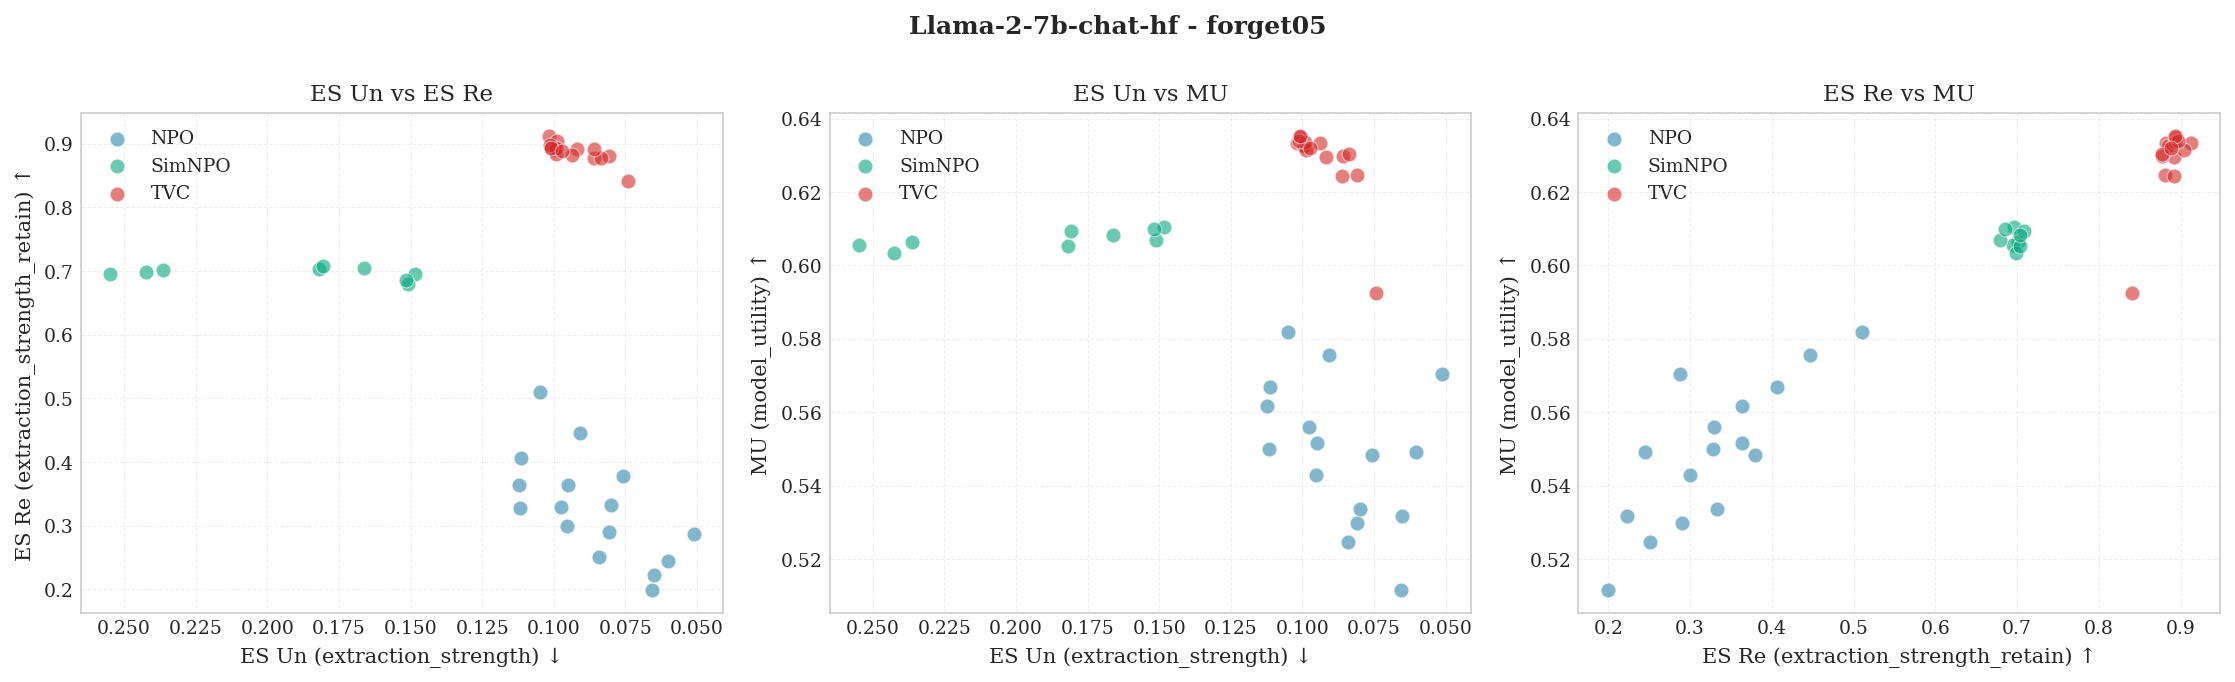

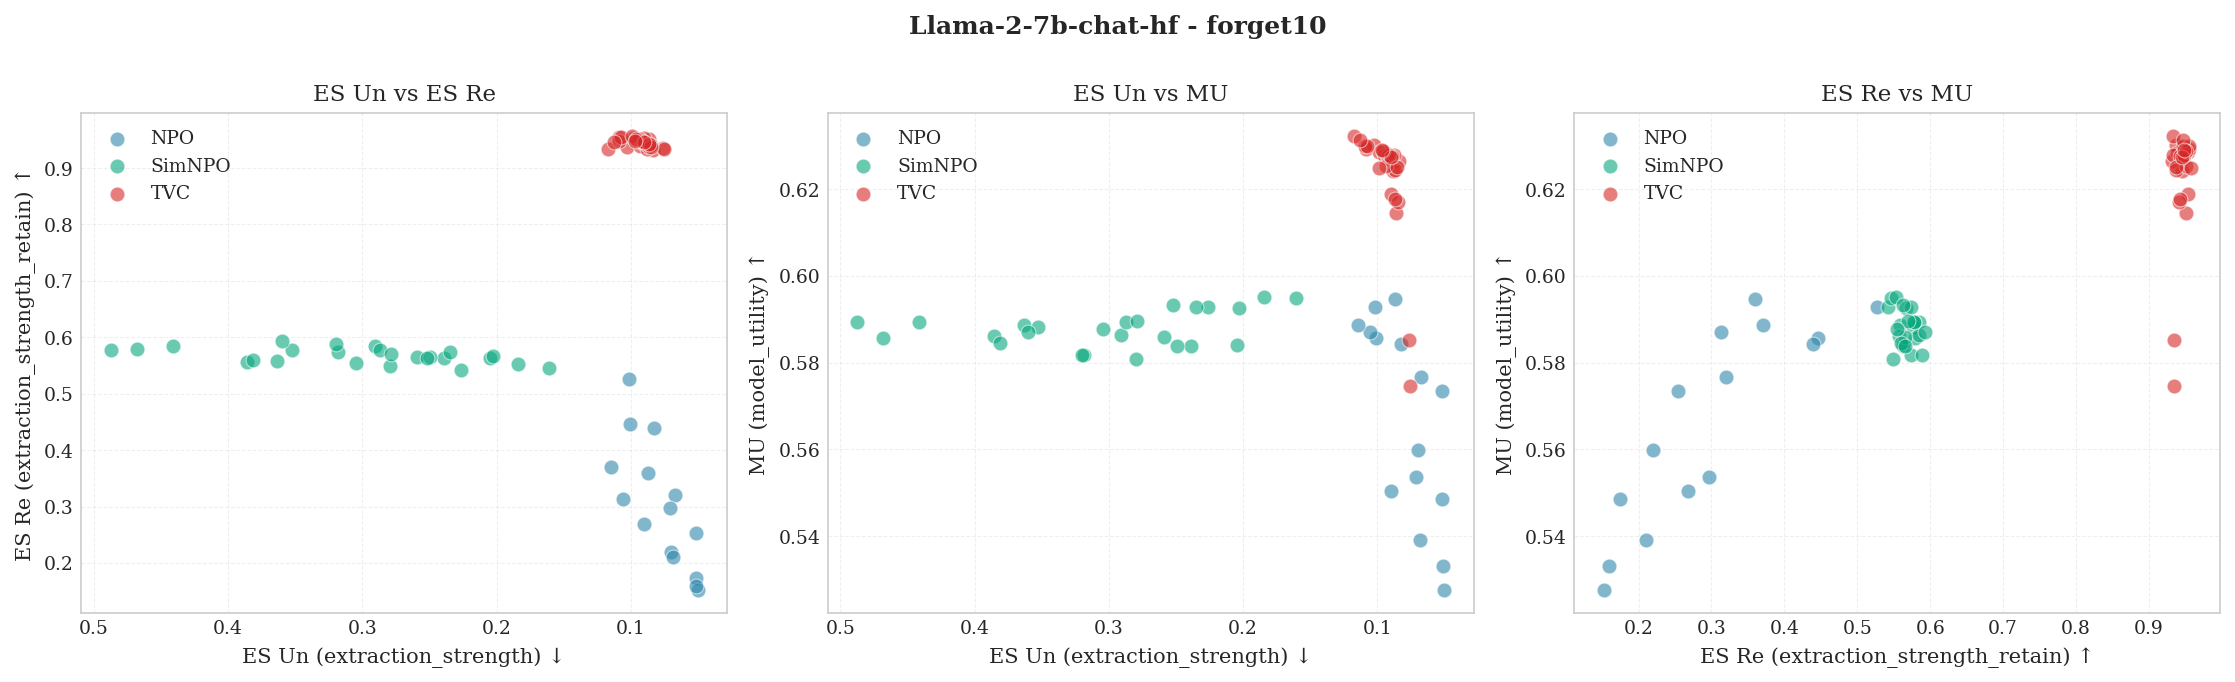

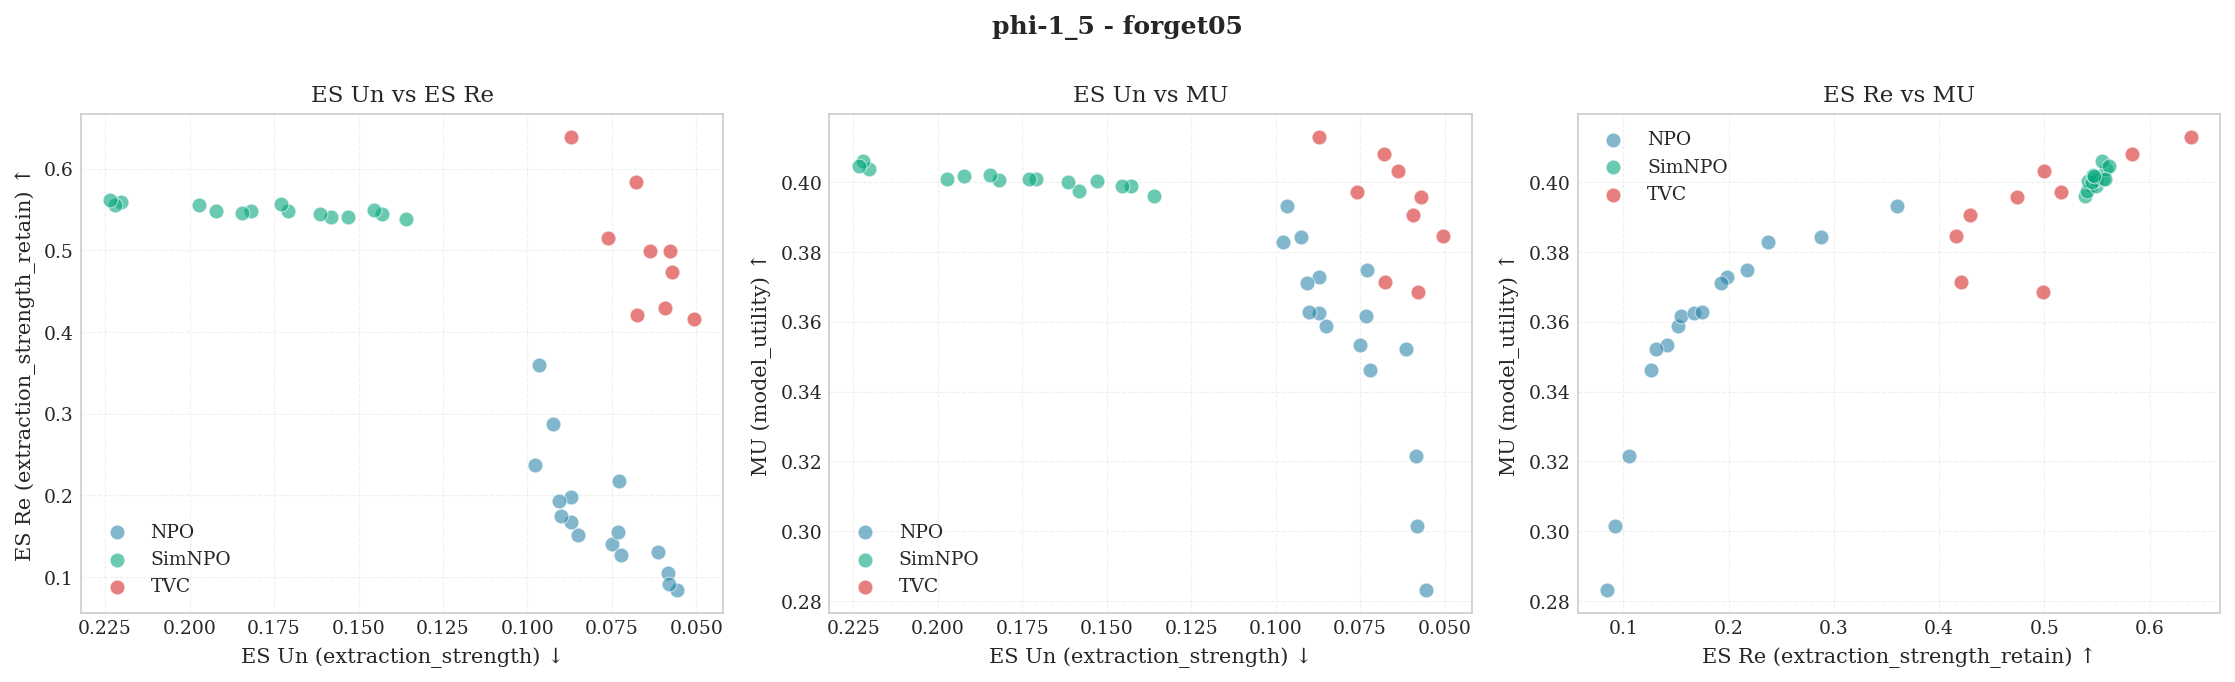

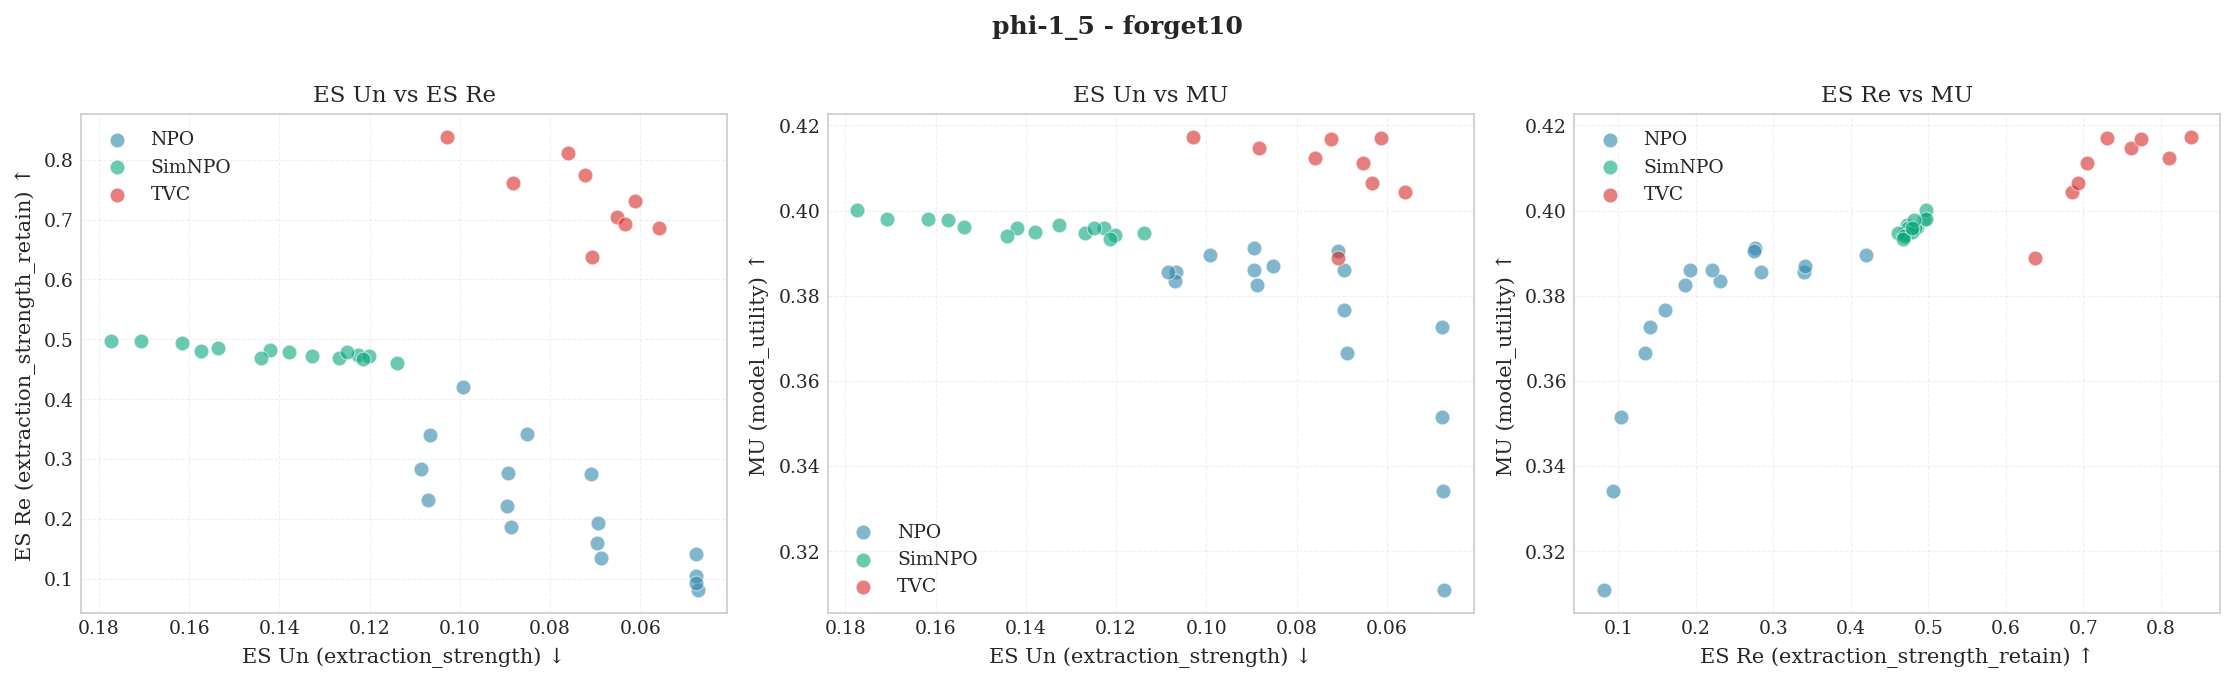

In [98]:
# 绘制所有组合的帕累托前沿
for model in ['Llama-2-7b-chat-hf', 'phi-1_5']:
    for forget_set in ['forget05', 'forget10']:
        plot_pareto_frontier(analysis_results, model, forget_set)
        

## 7. 汇总统计表

In [66]:
def create_summary_table(analysis_results: Dict) -> pd.DataFrame:
    """创建汇总表格"""
    summary_data = []
    
    for key, result in analysis_results.items():
        model, forget_set = key.rsplit('_', 1)
        
        for method in ['NPO', 'SimNPO', 'TVC']:
            if method in result['pareto_by_method']:
                pareto_df = result['pareto_by_method'][method]
                if len(pareto_df) > 0:
                    # 找出综合表现最好的帕累托点（使用标准化后的加权得分）
                    # 得分 = -ES_Un_norm + ES_Re_norm + MU_norm
                    pareto_df = pareto_df.copy()
                    pareto_df['score'] = (-pareto_df['extraction_strength_norm'] + 
                                         pareto_df['extraction_strength_retain_norm'] + 
                                         pareto_df['model_utility_norm'])
                    best_idx = pareto_df['score'].idxmax()
                    best = pareto_df.loc[best_idx]
                    
                    record = {
                        'Model': model,
                        'Forget Set': forget_set,
                        'Method': method,
                        'Pareto Points': len(pareto_df),
                        'Best ES Un': best['extraction_strength'],
                        'Best ES Re': best['extraction_strength_retain'],
                        'Best MU': best['model_utility'],
                    }
                    
                    # 添加参数信息
                    if method in ['NPO', 'SimNPO']:
                        record['Best Params'] = f"beta={best.get('beta', 'N/A')}, gamma={best.get('gamma', 'N/A')}"
                    else:
                        record['Best Params'] = f"alpha={best.get('alpha', 'N/A')}, beta={best.get('beta', 'N/A')}"
                    
                    summary_data.append(record)
    
    return pd.DataFrame(summary_data)

summary_table = create_summary_table(analysis_results)
print("\n" + "="*100)
print("帕累托最优汇总表（每种方法选取综合得分最高的帕累托点）")
print("="*100)
display(summary_table.round(4))


帕累托最优汇总表（每种方法选取综合得分最高的帕累托点）


,Model,Forget Set,Method,Pareto Points,Best ES Un,Best ES Re,Best MU,Best Params
0,Llama-2-7b-chat-hf,forget05,NPO,4,0.1050,0.5104,0.5820,"beta=0.2, gamma=0.2"
1,Llama-2-7b-chat-hf,forget05,SimNPO,3,0.1485,0.6961,0.6106,"beta=2.0, gamma=0.2"
2,Llama-2-7b-chat-hf,forget05,TVC,14,0.0836,0.8768,0.6303,"alpha=1.2, beta=1.1"
3,Llama-2-7b-chat-hf,forget10,NPO,9,0.1015,0.5264,0.5928,"beta=0.2, gamma=0.2"
4,Llama-2-7b-chat-hf,forget10,SimNPO,11,0.1606,0.5456,0.5949,"beta=1.5, gamma=0.175"
5,Llama-2-7b-chat-hf,forget10,TVC,27,0.0960,0.9515,0.6288,"alpha=0.9, beta=0.9"
6,phi-1_5,forget05,NPO,7,0.0967,0.3598,0.3931,"beta=0.2, gamma=0.2"
7,phi-1_5,forget05,SimNPO,13,0.1359,0.5383,0.3960,"beta=2.0, gamma=0.2"
8,phi-1_5,forget05,TVC,6,0.0872,0.6392,0.4131,"alpha=0.8, beta=0.8"
9,phi-1_5,forget10,NPO,9,0.0709,0.2753,0.3904,"beta=0.1, gamma=0.2"


In [67]:
# 保存结果到CSV
output_dir = Path('/cnz/data/project/my-open-unlearning/notebooks')
summary_table.to_csv(output_dir / 'pareto_analysis_summary.csv', index=False)
print(f"\n汇总表已保存到: {output_dir / 'pareto_analysis_summary.csv'}")


汇总表已保存到: /cnz/data/project/my-open-unlearning/notebooks/pareto_analysis_summary.csv


## 8. 详细帕累托最优点导出

In [68]:
def export_all_pareto_points(analysis_results: Dict) -> pd.DataFrame:
    """导出所有帕累托最优点的详细信息"""
    all_pareto_points = []
    
    for key, result in analysis_results.items():
        model, forget_set = key.rsplit('_', 1)
        
        for method in ['NPO', 'SimNPO', 'TVC']:
            if method in result['pareto_by_method']:
                pareto_df = result['pareto_by_method'][method].copy()
                if len(pareto_df) > 0:
                    pareto_df['analysis_group'] = key
                    all_pareto_points.append(pareto_df)
    
    if all_pareto_points:
        return pd.concat(all_pareto_points, ignore_index=True)
    return pd.DataFrame()

all_pareto_df = export_all_pareto_points(analysis_results)

# 选择要保存的列
export_cols = ['analysis_group', 'model', 'forget_set', 'method', 
               'beta', 'gamma', 'alpha',
               'extraction_strength', 'extraction_strength_retain', 'model_utility',
               'extraction_strength_norm', 'extraction_strength_retain_norm', 'model_utility_norm',
               'folder']
available_export_cols = [c for c in export_cols if c in all_pareto_df.columns]

all_pareto_df[available_export_cols].to_csv(output_dir / 'all_pareto_points.csv', index=False)
print(f"所有帕累托最优点已保存到: {output_dir / 'all_pareto_points.csv'}")
print(f"总计 {len(all_pareto_df)} 个帕累托最优点")

所有帕累托最优点已保存到: /cnz/data/project/my-open-unlearning/notebooks/all_pareto_points.csv
总计 119 个帕累托最优点


## 9. 方法对比分析

In [69]:
def compare_methods(analysis_results: Dict):
    """对比不同方法的表现"""
    
    for key, result in analysis_results.items():
        model, forget_set = key.rsplit('_', 1)
        print(f"\n{'='*80}")
        print(f"方法对比: {model} - {forget_set}")
        print(f"{'='*80}")
        
        # 统计每种方法在全局帕累托前沿中的占比
        global_pareto = result['pareto_by_method'].get('ALL', pd.DataFrame())
        if len(global_pareto) > 0:
            method_counts = global_pareto['method'].value_counts()
            print(f"\n全局帕累托前沿中各方法占比:")
            for method, count in method_counts.items():
                pct = count / len(global_pareto) * 100
                print(f"  {method}: {count}/{len(global_pareto)} ({pct:.1f}%)")
        
        # 对比各指标的最优值
        subset = result['subset']
        print(f"\n各指标最优值对比:")
        
        # ES Un 最小值
        best_es_un = subset.loc[subset['extraction_strength'].idxmin()]
        print(f"  ES Un最低: {best_es_un['extraction_strength']:.4f} ({best_es_un['method']})")
        
        # ES Re 最大值
        best_es_re = subset.loc[subset['extraction_strength_retain'].idxmax()]
        print(f"  ES Re最高: {best_es_re['extraction_strength_retain']:.4f} ({best_es_re['method']})")
        
        # MU 最大值
        best_mu = subset.loc[subset['model_utility'].idxmax()]
        print(f"  MU最高: {best_mu['model_utility']:.4f} ({best_mu['method']})")

compare_methods(analysis_results)


方法对比: Llama-2-7b-chat-hf - forget05

全局帕累托前沿中各方法占比:
  TVC: 14/15 (93.3%)
  NPO: 1/15 (6.7%)

各指标最优值对比:
  ES Un最低: 0.0512 (NPO)
  ES Re最高: 0.9124 (TVC)
  MU最高: 0.6353 (TVC)

方法对比: Llama-2-7b-chat-hf - forget10

全局帕累托前沿中各方法占比:
  TVC: 27/32 (84.4%)
  NPO: 5/32 (15.6%)

各指标最优值对比:
  ES Un最低: 0.0502 (NPO)
  ES Re最高: 0.9573 (TVC)
  MU最高: 0.6323 (TVC)

方法对比: phi-1_5 - forget05

全局帕累托前沿中各方法占比:
  TVC: 6/6 (100.0%)

各指标最优值对比:
  ES Un最低: 0.0506 (TVC)
  ES Re最高: 0.6392 (TVC)
  MU最高: 0.4131 (TVC)

方法对比: phi-1_5 - forget10

全局帕累托前沿中各方法占比:
  TVC: 5/9 (55.6%)
  NPO: 4/9 (44.4%)

各指标最优值对比:
  ES Un最低: 0.0473 (NPO)
  ES Re最高: 0.8384 (TVC)
  MU最高: 0.4173 (TVC)


## 10. 3D可视化帕累托前沿

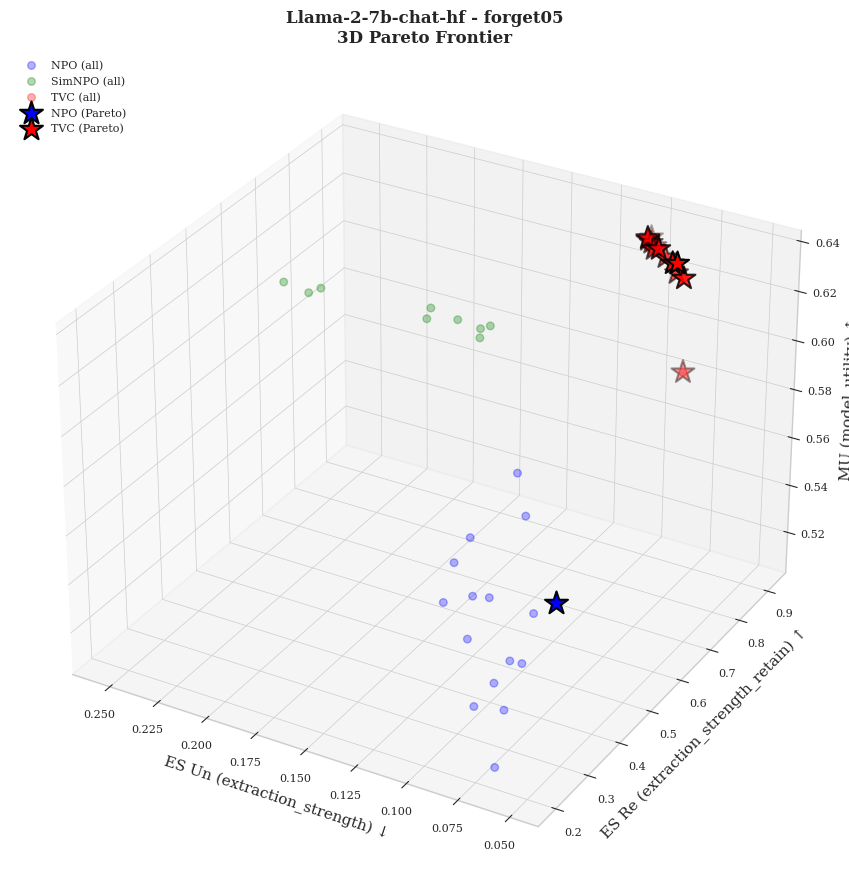

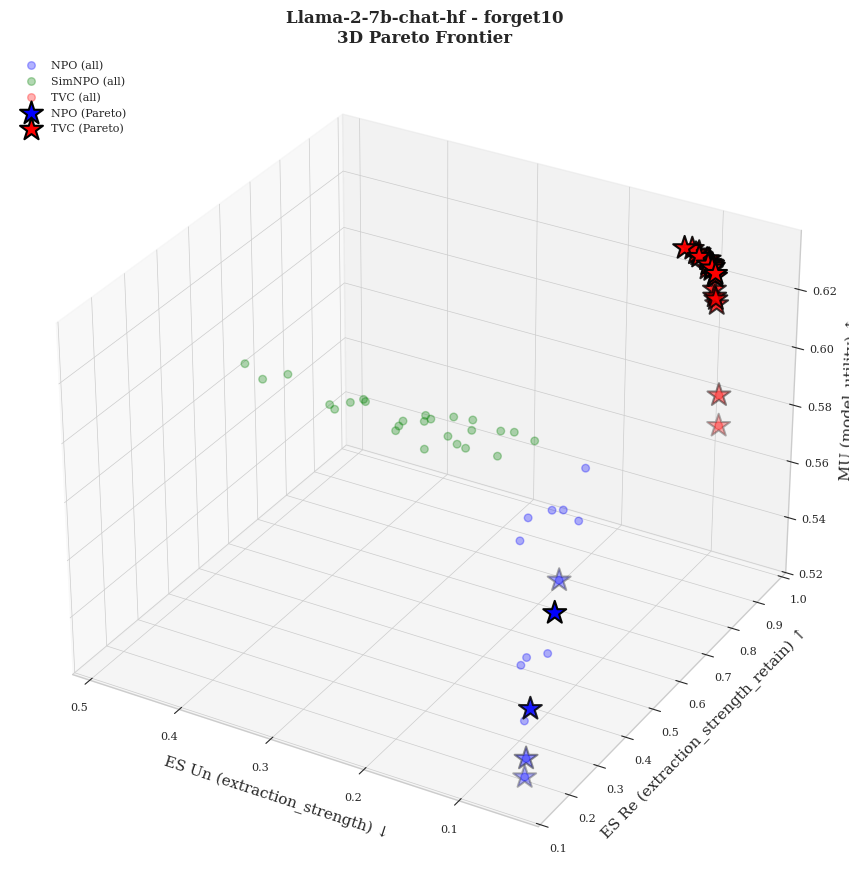

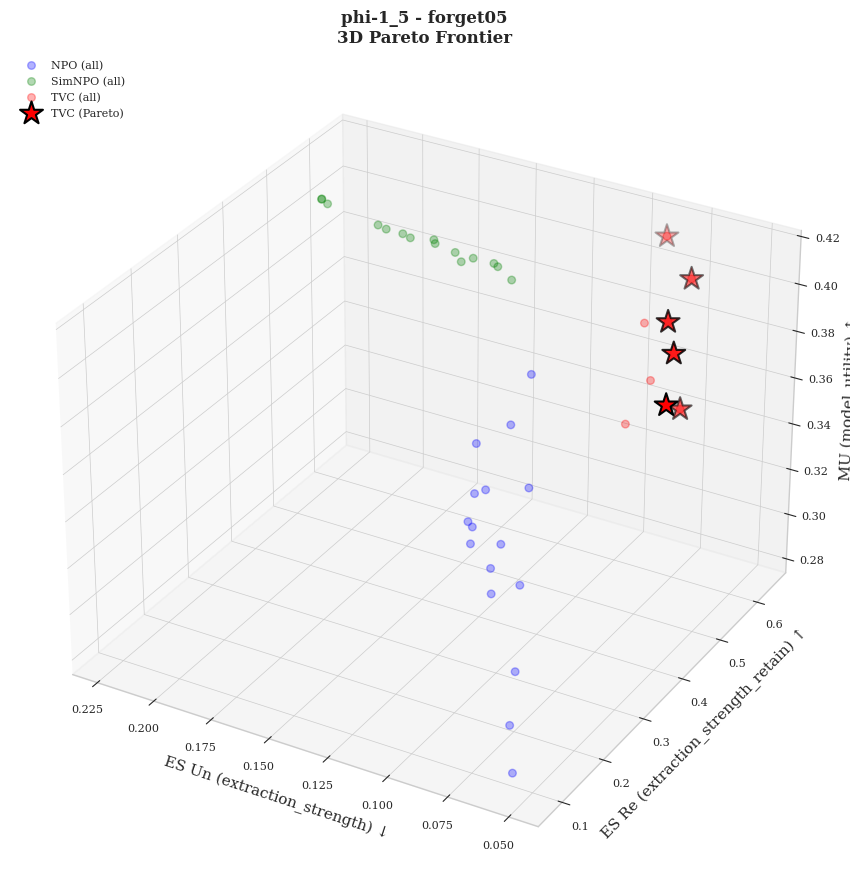

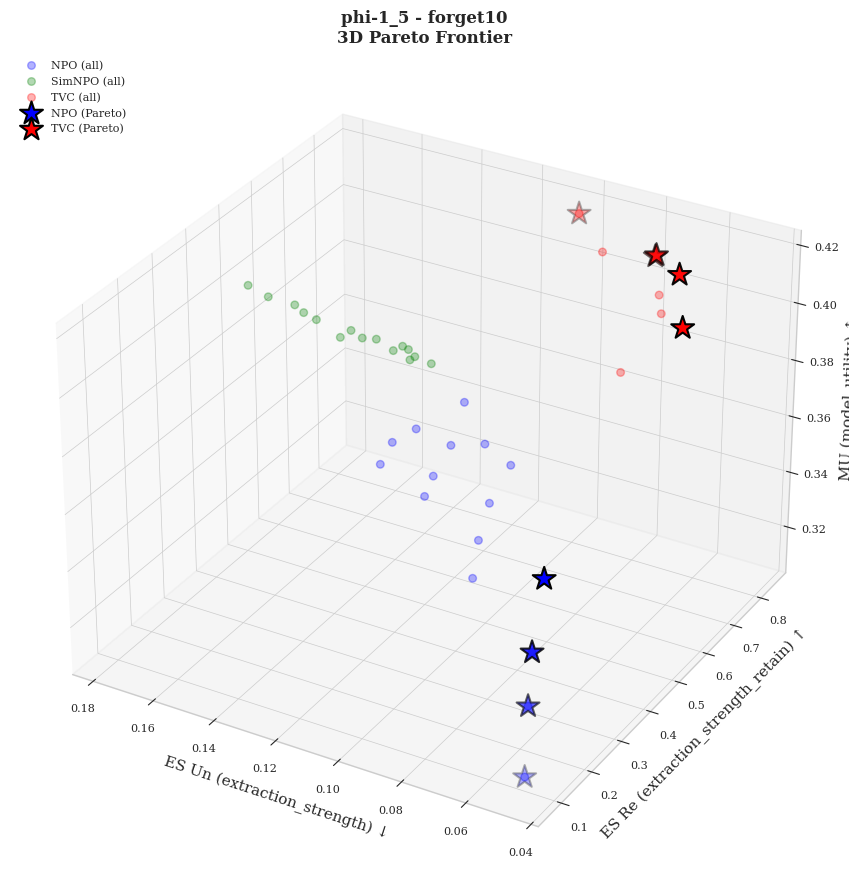

In [70]:
from mpl_toolkits.mplot3d import Axes3D

def plot_3d_pareto(analysis_results: Dict, model: str, forget_set: str):
    """3D可视化帕累托前沿"""
    key = f"{model}_{forget_set}"
    if key not in analysis_results:
        print(f"No data for {key}")
        return
    
    result = analysis_results[key]
    subset = result['subset']
    global_pareto = result['pareto_by_method'].get('ALL', pd.DataFrame())
    
    fig = plt.figure(figsize=(12, 9))
    ax = fig.add_subplot(111, projection='3d')
    
    colors = {'NPO': 'blue', 'SimNPO': 'green', 'TVC': 'red'}
    
    # 绘制所有点
    for method in subset['method'].unique():
        method_data = subset[subset['method'] == method]
        ax.scatter(method_data['extraction_strength'], 
                  method_data['extraction_strength_retain'],
                  method_data['model_utility'],
                  c=colors.get(method, 'gray'), alpha=0.3, label=f'{method} (all)', s=30)
    
    # 绘制帕累托最优点
    if len(global_pareto) > 0:
        for method in global_pareto['method'].unique():
            pareto_method = global_pareto[global_pareto['method'] == method]
            ax.scatter(pareto_method['extraction_strength'], 
                      pareto_method['extraction_strength_retain'],
                      pareto_method['model_utility'],
                      c=colors.get(method, 'gray'), marker='*', s=300,
                      edgecolors='black', linewidth=1.5, label=f'{method} (Pareto)')
    
    ax.set_xlabel('ES Un (extraction_strength) ↓')
    ax.set_ylabel('ES Re (extraction_strength_retain) ↑')
    ax.set_zlabel('MU (model_utility) ↑')
    ax.set_title(f'{model} - {forget_set}\n3D Pareto Frontier', fontsize=12, fontweight='bold')
    ax.legend(loc='upper left', fontsize=8)
    
    # 反转ES Un轴
    ax.invert_xaxis()
    
    plt.tight_layout()
    plt.show()

# 绘制所有组合的3D帕累托前沿
for model in ['Llama-2-7b-chat-hf', 'phi-1_5']:
    for forget_set in ['forget05', 'forget10']:
        plot_3d_pareto(analysis_results, model, forget_set)

## 11. 总结

In [71]:
print("="*80)
print("帕累托最优分析总结")
print("="*80)

print("\n分析的指标:")
print("  - ES Un (extraction_strength): 遗忘集提取强度，越低越好")
print("  - ES Re (extraction_strength_retain): 保留集提取强度，越高越好")
print("  - MU (model_utility): 模型效用，越高越好")

print("\n分析的方法:")
print("  - NPO: Negative Preference Optimization")
print("  - SimNPO: Simplified NPO")
print("  - TVC: Task Vector Composition (alpha, beta参数)")

print("\n主要发现:")
print(summary_table.to_string())

帕累托最优分析总结

分析的指标:
  - ES Un (extraction_strength): 遗忘集提取强度，越低越好
  - ES Re (extraction_strength_retain): 保留集提取强度，越高越好
  - MU (model_utility): 模型效用，越高越好

分析的方法:
  - NPO: Negative Preference Optimization
  - SimNPO: Simplified NPO
  - TVC: Task Vector Composition (alpha, beta参数)

主要发现:
                 Model Forget Set  Method  Pareto Points  Best ES Un  Best ES Re   Best MU            Best Params
0   Llama-2-7b-chat-hf   forget05     NPO              4    0.104980    0.510355  0.581974    beta=0.2, gamma=0.2
1   Llama-2-7b-chat-hf   forget05  SimNPO              3    0.148467    0.696092  0.610552    beta=2.0, gamma=0.2
2   Llama-2-7b-chat-hf   forget05     TVC             14    0.083567    0.876780  0.630338    alpha=1.2, beta=1.1
3   Llama-2-7b-chat-hf   forget10     NPO              9    0.101473    0.526443  0.592781    beta=0.2, gamma=0.2
4   Llama-2-7b-chat-hf   forget10  SimNPO             11    0.160617    0.545640  0.594902  beta=1.5, gamma=0.175
5   Llama-2-7b-chat-hf   forget1

## 12. 生成论文表格数据

加载完整的指标数据（包括F-RL和R-RL），生成论文所需的表格。

In [72]:
# 重新加载数据，包含所有指标
def load_full_metrics(summary_path: Path) -> Dict:
    """加载完整的TOFU_SUMMARY.json指标"""
    try:
        with open(summary_path, 'r') as f:
            data = json.load(f)
            return {
                'ES': data.get('extraction_strength'),
                'RE': data.get('extraction_strength_retain'),
                'MU': data.get('model_utility'),
                'F_RL': data.get('forget_Q_A_ROUGE'),
                'R_RL': data.get('retain_Q_A_ROUGE'),
            }
    except Exception as e:
        print(f"Error loading {summary_path}: {e}")
        return None

# 获取TOPSIS推荐的TVC参数对应的完整数据
tvc_params = {
    ('phi-1_5', 'forget05'): ('1.0', '0.8'),      # alpha=1.0, beta=0.8
    ('phi-1_5', 'forget10'): ('1.2', '1.0'),      # alpha=1.2, beta=1.0
    ('Llama-2-7b-chat-hf', 'forget05'): ('1.2', '1.1'),  # alpha=1.2, beta=1.1
    ('Llama-2-7b-chat-hf', 'forget10'): ('1.1', '1.0'),  # alpha=1.1, beta=1.0
}

# NPO和SimNPO的推荐参数
npo_simnpo_params = {
    ('phi-1_5', 'forget05', 'NPO'): (0.2, 0.2),
    ('phi-1_5', 'forget05', 'SimNPO'): (2.25, 0.2),
    ('phi-1_5', 'forget10', 'NPO'): (0.2, 0.2),
    ('phi-1_5', 'forget10', 'SimNPO'): (2.5, 0.1),
    ('Llama-2-7b-chat-hf', 'forget05', 'NPO'): (0.2, 0.2),
    ('Llama-2-7b-chat-hf', 'forget05', 'SimNPO'): (2.0, 0.2),
    ('Llama-2-7b-chat-hf', 'forget10', 'NPO'): (0.2, 0.2),
    ('Llama-2-7b-chat-hf', 'forget10', 'SimNPO'): (2.0, 0.2),
}

# TVC文件夹映射
tvc_folders = {
    ('phi-1_5', 'forget05'): 'hyperparam_search_forget05_phi_mlp_e5',
    ('phi-1_5', 'forget10'): 'hyperparam_search_forget10_phi_mlp_e5',
    ('Llama-2-7b-chat-hf', 'forget05'): 'hyperparam_search_forget05_7b_mlp',
    ('Llama-2-7b-chat-hf', 'forget10'): 'hyperparam_search_forget10_7b_mlp',
}

# NPO/SimNPO文件夹映射
npo_folders = {
    'phi-1_5': 'phi',
    'Llama-2-7b-chat-hf': 'llama_2_chat',
}

table_data = []

for model in ['phi-1_5', 'Llama-2-7b-chat-hf']:
    for forget_set in ['forget05', 'forget10']:
        # NPO
        beta, gamma = npo_simnpo_params[(model, forget_set, 'NPO')]
        model_name = 'phi-1_5' if 'phi' in model else 'Llama-2-7b-chat-hf'
        folder_name = f"tofu_{model_name}_forget{forget_set[-2:]}_NPO_beta{beta}_gamma{gamma}_epoch5"
        summary_path = BASE_PATH / npo_folders[model] / folder_name / 'evals' / 'TOFU_SUMMARY.json'
        if summary_path.exists():
            metrics = load_full_metrics(summary_path)
            if metrics:
                table_data.append({
                    'Model': model, 'Forget Set': forget_set, 'Method': 'NPO', **metrics
                })
        
        # SimNPO
        beta, gamma = npo_simnpo_params[(model, forget_set, 'SimNPO')]
        folder_name = f"tofu_{model_name}_forget{forget_set[-2:]}_SimNPO_beta{beta}_gamma{gamma}_epoch5"
        summary_path = BASE_PATH / npo_folders[model] / folder_name / 'evals' / 'TOFU_SUMMARY.json'
        if summary_path.exists():
            metrics = load_full_metrics(summary_path)
            if metrics:
                table_data.append({
                    'Model': model, 'Forget Set': forget_set, 'Method': 'SimNPO', **metrics
                })
        
        # TVC
        alpha, beta = tvc_params[(model, forget_set)]
        tvc_folder = tvc_folders[(model, forget_set)]
        # 根据文件夹类型确定路径
        if 'phi' in tvc_folder:
            folder_name = f"model_a{alpha}_b{beta}"
            summary_path = BASE_PATH / tvc_folder / folder_name / 'evals' / 'TOFU_SUMMARY.json'
        else:
            folder_name = f"evals_a{alpha}_b{beta}"
            summary_path = BASE_PATH / tvc_folder / folder_name / 'TOFU_SUMMARY.json'
        
        if summary_path.exists():
            metrics = load_full_metrics(summary_path)
            if metrics:
                table_data.append({
                    'Model': model, 'Forget Set': forget_set, 'Method': 'TVC', **metrics
                })

paper_df = pd.DataFrame(table_data)
print("论文表格数据:")
display(paper_df.round(4))

论文表格数据:


,Model,Forget Set,Method,ES,RE,MU,F_RL,R_RL
0,phi-1_5,forget05,NPO,0.0967,0.3598,0.3931,0.4084,0.4986
1,phi-1_5,forget05,SimNPO,0.1429,0.5442,0.3990,0.4526,0.5520
2,phi-1_5,forget05,TVC,0.0678,0.5838,0.4080,0.4063,0.6210
3,phi-1_5,forget10,NPO,0.0993,0.4194,0.3896,0.4319,0.5377
4,phi-1_5,forget10,SimNPO,0.1774,0.4970,0.4000,0.4621,0.5583
5,phi-1_5,forget10,TVC,0.0613,0.7307,0.4171,0.3876,0.7197
6,Llama-2-7b-chat-hf,forget05,NPO,0.1050,0.5104,0.5820,0.3298,0.6094
7,Llama-2-7b-chat-hf,forget05,SimNPO,0.1485,0.6961,0.6106,0.3659,0.6750
8,Llama-2-7b-chat-hf,forget05,TVC,0.0836,0.8768,0.6303,0.3706,0.8865
9,Llama-2-7b-chat-hf,forget10,NPO,0.1015,0.5264,0.5928,0.3494,0.6037


In [73]:
# 生成LaTeX表格格式
def generate_latex_row(model, forget_set, method, df):
    """生成一行LaTeX数据"""
    row = df[(df['Model'] == model) & (df['Forget Set'] == forget_set) & (df['Method'] == method)]
    if len(row) == 0:
        return None
    row = row.iloc[0]
    return f"{row['ES']:.4f} & {row['RE']:.4f} & {row['MU']:.4f} & {row['F_RL']:.4f} & {row['R_RL']:.4f}"

print("=" * 100)
print("LaTeX表格数据 (按行格式)")
print("=" * 100)

# Forget05
print("\n% Forget05 Partition")
for method in ['NPO', 'SimNPO', 'TVC']:
    phi_row = generate_latex_row('phi-1_5', 'forget05', method, paper_df)
    llama_row = generate_latex_row('Llama-2-7b-chat-hf', 'forget05', method, paper_df)
    
    method_name = method if method != 'TVC' else 'TVC (Ours)'
    if phi_row and llama_row:
        print(f"{method_name} & {phi_row} & {llama_row} \\\\")

# Forget10
print("\n% Forget10 Partition")
for method in ['NPO', 'SimNPO', 'TVC']:
    phi_row = generate_latex_row('phi-1_5', 'forget10', method, paper_df)
    llama_row = generate_latex_row('Llama-2-7b-chat-hf', 'forget10', method, paper_df)
    
    method_name = method if method != 'TVC' else 'TVC (Ours)'
    if phi_row and llama_row:
        print(f"{method_name} & {phi_row} & {llama_row} \\\\")

LaTeX表格数据 (按行格式)

% Forget05 Partition
NPO & 0.0967 & 0.3598 & 0.3931 & 0.4084 & 0.4986 & 0.1050 & 0.5104 & 0.5820 & 0.3298 & 0.6094 \\
SimNPO & 0.1429 & 0.5442 & 0.3990 & 0.4526 & 0.5520 & 0.1485 & 0.6961 & 0.6106 & 0.3659 & 0.6750 \\
TVC (Ours) & 0.0678 & 0.5838 & 0.4080 & 0.4063 & 0.6210 & 0.0836 & 0.8768 & 0.6303 & 0.3706 & 0.8865 \\

% Forget10 Partition
NPO & 0.0993 & 0.4194 & 0.3896 & 0.4319 & 0.5377 & 0.1015 & 0.5264 & 0.5928 & 0.3494 & 0.6037 \\
TVC (Ours) & 0.0613 & 0.7307 & 0.4171 & 0.3876 & 0.7197 & 0.0899 & 0.9455 & 0.6273 & 0.4002 & 0.9566 \\


## 7. 权重调整: ES Un 权重 = ES Re + MU (权重比 2:1:1)

用户要求：ES Un 的重要性等于 ES Re 和 MU 两者加起来，即权重比例为 **w(ES Un) : w(ES Re) : w(MU) = 2 : 1 : 1**

In [74]:
# 使用权重 (2, 1, 1) 进行单点选择
# ES Un 权重 = 2, ES Re 权重 = 1, MU 权重 = 1
# 即 ES Un 的重要性 = ES Re + MU

weighted_211_results = []
weights_211 = (2, 1, 1)  # ES Un : ES Re : MU = 2 : 1 : 1

print("=" * 100)
print("权重调整后的单点选择 (ES Un : ES Re : MU = 2 : 1 : 1)")
print("=" * 100)
print(f"\n权重含义: ES Un (遗忘效果) 的重要性 = ES Re (保持效果) + MU (模型能力)")
print("=" * 100)

for group_key, result in analysis_results.items():
    model, forget_set = group_key.rsplit('_', 1)
    
    print(f"\n### {group_key} ###")
    
    for method in ['NPO', 'SimNPO', 'TVC']:
        if method not in result['pareto_by_method']:
            continue
        method_data = result['pareto_by_method'][method]
        if len(method_data) == 0:
            continue
        
        # 使用4种选择方法，但都用权重 (2, 1, 1)
        for sel_name, sel_desc in selection_methods.items():
            best = select_representative_point(method_data, sel_name, weights_211)
            if best is not None:
                weighted_211_results.append({
                    'group': group_key,
                    'model': model,
                    'forget_set': forget_set,
                    'method': method,
                    'selection': sel_name,
                    'params': best.get('params', f"β={best.get('beta', 'N/A')}, γ={best.get('gamma', 'N/A')}" if method in ['NPO', 'SimNPO'] else f"α={best.get('alpha', 'N/A')}, β={best.get('beta', 'N/A')}"),
                    'ES Un': best['extraction_strength'],
                    'ES Re': best['extraction_strength_retain'],
                    'MU': best['model_utility'],
                    'F-RL': best.get('forget_Q_A_ROUGE', np.nan),
                    'R-RL': best.get('retain_Q_A_ROUGE', np.nan),
                    'score': best['score']
                })

# 创建对比表格
weighted_211_df = pd.DataFrame(weighted_211_results)
print("\n所有方法的权重(2,1,1)选择结果:")
display(weighted_211_df.round(4))

权重调整后的单点选择 (ES Un : ES Re : MU = 2 : 1 : 1)

权重含义: ES Un (遗忘效果) 的重要性 = ES Re (保持效果) + MU (模型能力)

### Llama-2-7b-chat-hf_forget05 ###

### Llama-2-7b-chat-hf_forget10 ###

### phi-1_5_forget05 ###

### phi-1_5_forget10 ###

所有方法的权重(2,1,1)选择结果:


,group,model,forget_set,method,selection,params,ES Un,ES Re,MU,F-RL,R-RL,score
0,Llama-2-7b-chat-hf_forget05,Llama-2-7b-chat-hf,forget05,NPO,weighted_sum,"β=0.05, γ=0.2",0.0512,0.2873,0.5704,NaN,NaN,0.5984
1,Llama-2-7b-chat-hf_forget05,Llama-2-7b-chat-hf,forget05,NPO,ideal_distance,"β=0.05, γ=0.2",0.0512,0.2873,0.5704,NaN,NaN,-1.7447
2,Llama-2-7b-chat-hf_forget05,Llama-2-7b-chat-hf,forget05,NPO,topsis,"β=0.2, γ=0.2",0.1050,0.5104,0.5820,NaN,NaN,0.2959
3,Llama-2-7b-chat-hf_forget05,Llama-2-7b-chat-hf,forget05,NPO,geometric_mean,"β=0.2, γ=0.2",0.1050,0.5104,0.5820,NaN,NaN,0.5775
4,Llama-2-7b-chat-hf_forget05,Llama-2-7b-chat-hf,forget05,SimNPO,weighted_sum,"β=2.0, γ=0.2",0.1485,0.6961,0.6106,NaN,NaN,0.5408
5,Llama-2-7b-chat-hf_forget05,Llama-2-7b-chat-hf,forget05,SimNPO,ideal_distance,"β=2.0, γ=0.2",0.1485,0.6961,0.6106,NaN,NaN,-2.1213
6,Llama-2-7b-chat-hf_forget05,Llama-2-7b-chat-hf,forget05,SimNPO,topsis,"β=2.25, γ=0.15",0.1806,0.7085,0.6095,NaN,NaN,0.3733
7,Llama-2-7b-chat-hf_forget05,Llama-2-7b-chat-hf,forget05,SimNPO,geometric_mean,"β=2.0, γ=0.2",0.1485,0.6961,0.6106,NaN,NaN,0.6728
8,Llama-2-7b-chat-hf_forget05,Llama-2-7b-chat-hf,forget05,TVC,weighted_sum,"α=1.2, β=1.1",0.0836,0.8768,0.6303,NaN,NaN,1.5917
9,Llama-2-7b-chat-hf_forget05,Llama-2-7b-chat-hf,forget05,TVC,ideal_distance,"α=1.2, β=0.8",0.0742,0.8407,0.5924,NaN,NaN,-1.6146


In [75]:
# 使用TOPSIS方法（权重2:1:1）得到最终推荐参数，并生成LaTeX表格
print("=" * 100)
print("TOPSIS 方法 (权重 2:1:1) 最终推荐参数")
print("=" * 100)

# 先打印有多少数据
print(f"weighted_211_df 行数: {len(weighted_211_df)}")
print(f"analysis_results keys: {list(analysis_results.keys())}")

# 按 group 和 method 分组
final_recommendations_211 = []
for group_key, result in analysis_results.items():
    model, forget_set = group_key.rsplit('_', 1)
    
    for method in ['NPO', 'SimNPO', 'TVC']:
        if method not in result['pareto_by_method']:
            print(f"  警告: {group_key} 没有 {method} 方法")
            continue
        method_data = result['pareto_by_method'][method]
        if len(method_data) == 0:
            print(f"  警告: {group_key} 的 {method} 方法数据为空")
            continue
        
        best = select_representative_point(method_data, 'topsis', weights_211)
        if best is not None:
            # 构造参数字符串
            if method in ['NPO', 'SimNPO']:
                params_str = f"β={best.get('beta', 'N/A')}, γ={best.get('gamma', 'N/A')}"
            else:
                params_str = f"α={best.get('alpha', 'N/A')}, β={best.get('beta', 'N/A')}"
            
            final_recommendations_211.append({
                'Model': model,
                'Forget Set': forget_set,
                'Method': method,
                'Params': params_str,
                'ES Un ↓': best['extraction_strength'],
                'ES Re ↑': best['extraction_strength_retain'],
                'MU ↑': best['model_utility'],
                'F-RL': best.get('forget_Q_A_ROUGE', np.nan),
                'R-RL': best.get('retain_Q_A_ROUGE', np.nan),
            })
        else:
            print(f"  警告: {group_key} 的 {method} 方法未找到最佳点")

print(f"\nfinal_recommendations_211 行数: {len(final_recommendations_211)}")
final_df_211 = pd.DataFrame(final_recommendations_211)
print("\nTOPSIS(2:1:1) 推荐结果:")
display(final_df_211.round(4))

TOPSIS 方法 (权重 2:1:1) 最终推荐参数
weighted_211_df 行数: 48
analysis_results keys: ['Llama-2-7b-chat-hf_forget05', 'Llama-2-7b-chat-hf_forget10', 'phi-1_5_forget05', 'phi-1_5_forget10']

final_recommendations_211 行数: 12

TOPSIS(2:1:1) 推荐结果:


,Model,Forget Set,Method,Params,ES Un ↓,ES Re ↑,MU ↑,F-RL,R-RL
0,Llama-2-7b-chat-hf,forget05,NPO,"β=0.2, γ=0.2",0.1050,0.5104,0.5820,NaN,NaN
1,Llama-2-7b-chat-hf,forget05,SimNPO,"β=2.25, γ=0.15",0.1806,0.7085,0.6095,NaN,NaN
2,Llama-2-7b-chat-hf,forget05,TVC,"α=1.2, β=1.1",0.0836,0.8768,0.6303,NaN,NaN
3,Llama-2-7b-chat-hf,forget10,NPO,"β=0.2, γ=0.2",0.1015,0.5264,0.5928,NaN,NaN
4,Llama-2-7b-chat-hf,forget10,SimNPO,"β=1.5, γ=0.15",0.1844,0.5529,0.5951,NaN,NaN
5,Llama-2-7b-chat-hf,forget10,TVC,"α=1.0, β=1.0",0.0913,0.9479,0.6278,NaN,NaN
6,phi-1_5,forget05,NPO,"β=0.2, γ=0.2",0.0967,0.3598,0.3931,NaN,NaN
7,phi-1_5,forget05,SimNPO,"β=2.5, γ=0.125",0.1973,0.5559,0.4011,NaN,NaN
8,phi-1_5,forget05,TVC,"α=1.0, β=0.8",0.0678,0.5838,0.4080,NaN,NaN
9,phi-1_5,forget10,NPO,"β=0.2, γ=0.2",0.0993,0.4194,0.3896,NaN,NaN


In [76]:
# 生成LaTeX表格 (权重 2:1:1)
print("=" * 100)
print("LaTeX 表格 (TOPSIS, 权重 2:1:1)")
print("=" * 100)

# 按论文格式组织数据 - 先按模型，再按forget set分组
latex_data_211 = []

# 使用正确的model名称
for model_name in ['Llama-2-7b-chat-hf', 'phi-1_5']:
    model_display = 'Llama-2-7B' if 'Llama' in model_name else 'Phi-1.5'
    
    for forget_set in ['forget05', 'forget10']:
        subset_211 = final_df_211[(final_df_211['Model'] == model_name) & 
                                   (final_df_211['Forget Set'] == forget_set)]
        
        for _, row in subset_211.iterrows():
            latex_data_211.append({
                'Model': model_display,
                'Forget': forget_set.replace('forget', '').replace('05', '5%').replace('10', '10%'),
                'Method': row['Method'],
                'Params': row['Params'],
                'ES↓': row['ES Un ↓'],
                'RE↑': row['ES Re ↑'],
                'MU↑': row['MU ↑'],
                'F-RL': row['F-RL'],
                'R-RL': row['R-RL'],
            })

paper_df_211 = pd.DataFrame(latex_data_211)
print(f"paper_df_211 行数: {len(paper_df_211)}")

# 生成LaTeX代码
print("\n\\begin{table}[h]")
print("\\centering")
print("\\caption{Unlearning Results with TOPSIS (Weight 2:1:1 for ES:RE:MU)}")
print("\\label{tab:unlearning_211}")
print("\\resizebox{\\textwidth}{!}{")
print("\\begin{tabular}{ll|l|l|ccccc}")
print("\\toprule")
print("Model & Forget & Method & Params & ES$\\downarrow$ & RE$\\uparrow$ & MU$\\uparrow$ & F-RL & R-RL \\\\")
print("\\midrule")

current_model = None
current_forget = None

for _, row in paper_df_211.iterrows():
    model = row['Model'] if row['Model'] != current_model else ''
    forget = row['Forget'] if (row['Model'] != current_model or row['Forget'] != current_forget) else ''
    
    if row['Model'] != current_model:
        if current_model is not None:
            print("\\midrule")
        current_model = row['Model']
        current_forget = None
    
    if row['Forget'] != current_forget:
        if current_forget is not None and row['Model'] == current_model:
            print("\\cmidrule{2-9}")
        current_forget = row['Forget']
    
    # 格式化数值
    es = f"{row['ES↓']:.4f}"
    re = f"{row['RE↑']:.4f}" 
    mu = f"{row['MU↑']:.4f}"
    frl = f"{row['F-RL']:.4f}" if pd.notna(row['F-RL']) else '-'
    rrl = f"{row['R-RL']:.4f}" if pd.notna(row['R-RL']) else '-'
    
    print(f"{model} & {forget} & {row['Method']} & {row['Params']} & {es} & {re} & {mu} & {frl} & {rrl} \\\\")

print("\\bottomrule")
print("\\end{tabular}")
print("}")
print("\\end{table}")

LaTeX 表格 (TOPSIS, 权重 2:1:1)
paper_df_211 行数: 12

\begin{table}[h]
\centering
\caption{Unlearning Results with TOPSIS (Weight 2:1:1 for ES:RE:MU)}
\label{tab:unlearning_211}
\resizebox{\textwidth}{!}{
\begin{tabular}{ll|l|l|ccccc}
\toprule
Model & Forget & Method & Params & ES$\downarrow$ & RE$\uparrow$ & MU$\uparrow$ & F-RL & R-RL \\
\midrule
Llama-2-7B & 5% & NPO & β=0.2, γ=0.2 & 0.1050 & 0.5104 & 0.5820 & - & - \\
 &  & SimNPO & β=2.25, γ=0.15 & 0.1806 & 0.7085 & 0.6095 & - & - \\
 &  & TVC & α=1.2, β=1.1 & 0.0836 & 0.8768 & 0.6303 & - & - \\
\cmidrule{2-9}
 & 10% & NPO & β=0.2, γ=0.2 & 0.1015 & 0.5264 & 0.5928 & - & - \\
 &  & SimNPO & β=1.5, γ=0.15 & 0.1844 & 0.5529 & 0.5951 & - & - \\
 &  & TVC & α=1.0, β=1.0 & 0.0913 & 0.9479 & 0.6278 & - & - \\
\midrule
Phi-1.5 & 5% & NPO & β=0.2, γ=0.2 & 0.0967 & 0.3598 & 0.3931 & - & - \\
 &  & SimNPO & β=2.5, γ=0.125 & 0.1973 & 0.5559 & 0.4011 & - & - \\
 &  & TVC & α=1.0, β=0.8 & 0.0678 & 0.5838 & 0.4080 & - & - \\
\cmidrule{2-9}
 & 10% & NP

In [77]:
# 对比两种权重方案: 等权重 (1:1:1) vs 偏重遗忘 (2:1:1)
print("=" * 100)
print("权重方案对比: 等权重 (1:1:1) vs 偏重ES Un (2:1:1)")
print("=" * 100)

# 获取两种权重的TOPSIS结果
equal_weight_results = []
for group_key, result in analysis_results.items():
    model, forget_set = group_key.rsplit('_', 1)
    
    for method in ['NPO', 'SimNPO', 'TVC']:
        if method not in result['pareto_by_method']:
            continue
        method_data = result['pareto_by_method'][method]
        if len(method_data) == 0:
            continue
        
        # 等权重 (1, 1, 1)
        best_111 = select_representative_point(method_data, 'topsis', (1, 1, 1))
        # 偏重遗忘 (2, 1, 1)
        best_211 = select_representative_point(method_data, 'topsis', (2, 1, 1))
        
        if best_111 is not None and best_211 is not None:
            # 构造参数字符串
            if method in ['NPO', 'SimNPO']:
                params_111 = f"β={best_111.get('beta', 'N/A')}, γ={best_111.get('gamma', 'N/A')}"
                params_211 = f"β={best_211.get('beta', 'N/A')}, γ={best_211.get('gamma', 'N/A')}"
            else:
                params_111 = f"α={best_111.get('alpha', 'N/A')}, β={best_111.get('beta', 'N/A')}"
                params_211 = f"α={best_211.get('alpha', 'N/A')}, β={best_211.get('beta', 'N/A')}"
            
            params_changed = params_111 != params_211
            equal_weight_results.append({
                'Model': model,
                'Forget': forget_set,
                'Method': method,
                'Params (1:1:1)': params_111,
                'Params (2:1:1)': params_211,
                'Changed': '✓' if params_changed else '',
                'ES Un (1:1:1)': best_111['extraction_strength'],
                'ES Un (2:1:1)': best_211['extraction_strength'],
                'ES Re (1:1:1)': best_111['extraction_strength_retain'],
                'ES Re (2:1:1)': best_211['extraction_strength_retain'],
                'MU (1:1:1)': best_111['model_utility'],
                'MU (2:1:1)': best_211['model_utility'],
            })

comparison_df_weights = pd.DataFrame(equal_weight_results)
print("\n两种权重方案的参数对比:")
print(comparison_df_weights[['Model', 'Forget', 'Method', 'Params (1:1:1)', 'Params (2:1:1)', 'Changed']].to_string(index=False))

print("\n\n两种权重方案的指标对比:")
metrics_compare = comparison_df_weights[['Model', 'Forget', 'Method', 
                                          'ES Un (1:1:1)', 'ES Un (2:1:1)', 
                                          'ES Re (1:1:1)', 'ES Re (2:1:1)',
                                          'MU (1:1:1)', 'MU (2:1:1)']].copy()
display(metrics_compare.round(4))

权重方案对比: 等权重 (1:1:1) vs 偏重ES Un (2:1:1)

两种权重方案的参数对比:
             Model   Forget Method Params (1:1:1) Params (2:1:1) Changed
Llama-2-7b-chat-hf forget05    NPO   β=0.2, γ=0.2   β=0.2, γ=0.2        
Llama-2-7b-chat-hf forget05 SimNPO   β=2.0, γ=0.2 β=2.25, γ=0.15       ✓
Llama-2-7b-chat-hf forget05    TVC   α=1.2, β=1.1   α=1.2, β=1.1        
Llama-2-7b-chat-hf forget10    NPO   β=0.2, γ=0.2   β=0.2, γ=0.2        
Llama-2-7b-chat-hf forget10 SimNPO β=1.5, γ=0.175  β=1.5, γ=0.15       ✓
Llama-2-7b-chat-hf forget10    TVC   α=1.0, β=1.0   α=1.0, β=1.0        
           phi-1_5 forget05    NPO   β=0.2, γ=0.2   β=0.2, γ=0.2        
           phi-1_5 forget05 SimNPO  β=2.25, γ=0.2 β=2.5, γ=0.125       ✓
           phi-1_5 forget05    TVC   α=1.0, β=0.8   α=1.0, β=0.8        
           phi-1_5 forget10    NPO   β=0.2, γ=0.2   β=0.2, γ=0.2        
           phi-1_5 forget10 SimNPO   β=2.5, γ=0.1   β=2.5, γ=0.1        
           phi-1_5 forget10    TVC   α=1.2, β=1.0   α=1.2, β=1.0       

,Model,Forget,Method,ES Un (1:1:1),ES Un (2:1:1),ES Re (1:1:1),ES Re (2:1:1),MU (1:1:1),MU (2:1:1)
0,Llama-2-7b-chat-hf,forget05,NPO,0.1050,0.1050,0.5104,0.5104,0.5820,0.5820
1,Llama-2-7b-chat-hf,forget05,SimNPO,0.1485,0.1806,0.6961,0.7085,0.6106,0.6095
2,Llama-2-7b-chat-hf,forget05,TVC,0.0836,0.0836,0.8768,0.8768,0.6303,0.6303
3,Llama-2-7b-chat-hf,forget10,NPO,0.1015,0.1015,0.5264,0.5264,0.5928,0.5928
4,Llama-2-7b-chat-hf,forget10,SimNPO,0.1606,0.1844,0.5456,0.5529,0.5949,0.5951
5,Llama-2-7b-chat-hf,forget10,TVC,0.0913,0.0913,0.9479,0.9479,0.6278,0.6278
6,phi-1_5,forget05,NPO,0.0967,0.0967,0.3598,0.3598,0.3931,0.3931
7,phi-1_5,forget05,SimNPO,0.1429,0.1973,0.5442,0.5559,0.3990,0.4011
8,phi-1_5,forget05,TVC,0.0678,0.0678,0.5838,0.5838,0.4080,0.4080
9,phi-1_5,forget10,NPO,0.0993,0.0993,0.4194,0.4194,0.3896,0.3896


In [78]:
# 生成用户要求的完整LaTeX表格格式（包含F-RL和R-RL）
# 需要从原始数据中获取完整指标

print("=" * 100)
print("生成完整论文表格 (TOPSIS 权重 2:1:1)")
print("=" * 100)

# 从 final_df_211 获取推荐的参数配置，然后从 all_data 获取完整指标
full_table_data = []

for _, rec in final_df_211.iterrows():
    model = rec['Model']
    forget_set = rec['Forget Set']
    method = rec['Method']
    params = rec['Params']
    
    # 解析参数
    if method in ['NPO', 'SimNPO']:
        # 从 params 提取 beta 和 gamma
        parts = params.replace('β=', '').replace('γ=', '').split(', ')
        beta_val = float(parts[0])
        gamma_val = float(parts[1])
        
        # 在 all_data 中查找匹配的行
        mask = (all_data['method'] == method) & \
               (all_data['forget_set'] == forget_set) & \
               (all_data['beta'] == beta_val) & \
               (all_data['gamma'] == gamma_val)
        if 'Llama' in model:
            mask = mask & all_data['model'].str.contains('Llama', na=False)
        else:
            mask = mask & all_data['model'].str.contains('phi', na=False, case=False)
    else:  # TVC
        parts = params.replace('α=', '').replace('β=', '').split(', ')
        alpha_val = float(parts[0])
        beta_val = float(parts[1])
        
        mask = (all_data['method'] == method) & \
               (all_data['forget_set'] == forget_set) & \
               (all_data['alpha'] == alpha_val) & \
               (all_data['beta'] == beta_val)
        if 'Llama' in model:
            mask = mask & all_data['model'].str.contains('Llama', na=False)
        else:
            mask = mask & all_data['model'].str.contains('phi', na=False, case=False)
    
    matched = all_data[mask]
    if len(matched) > 0:
        row = matched.iloc[0]
        full_table_data.append({
            'Model': 'phi-1.5B' if 'phi' in model else 'Llama2-7B-chat',
            'Forget': forget_set,
            'Method': method,
            'ES': row['extraction_strength'],
            'RE': row['extraction_strength_retain'],
            'MU': row['model_utility'],
            'F-RL': row.get('forget_Q_A_ROUGE', np.nan),
            'R-RL': row.get('retain_Q_A_ROUGE', np.nan),
        })
    else:
        print(f"警告: 未找到匹配数据 - {model}, {forget_set}, {method}, {params}")

full_df = pd.DataFrame(full_table_data)
print("\n完整数据表:")
display(full_df.round(4))

生成完整论文表格 (TOPSIS 权重 2:1:1)

完整数据表:


,Model,Forget,Method,ES,RE,MU,F-RL,R-RL
0,Llama2-7B-chat,forget05,NPO,0.1050,0.5104,0.5820,NaN,NaN
1,Llama2-7B-chat,forget05,SimNPO,0.1806,0.7085,0.6095,NaN,NaN
2,Llama2-7B-chat,forget05,TVC,0.0836,0.8768,0.6303,NaN,NaN
3,Llama2-7B-chat,forget10,NPO,0.1015,0.5264,0.5928,NaN,NaN
4,Llama2-7B-chat,forget10,SimNPO,0.1844,0.5529,0.5951,NaN,NaN
5,Llama2-7B-chat,forget10,TVC,0.0913,0.9479,0.6278,NaN,NaN
6,phi-1.5B,forget05,NPO,0.0967,0.3598,0.3931,NaN,NaN
7,phi-1.5B,forget05,SimNPO,0.1973,0.5559,0.4011,NaN,NaN
8,phi-1.5B,forget05,TVC,0.0678,0.5838,0.4080,NaN,NaN
9,phi-1.5B,forget10,NPO,0.0993,0.4194,0.3896,NaN,NaN


In [79]:
# 重新加载完整数据（包含ROUGE指标）
import json
import glob

# BASE_PATH 已经指向 saves/unlearn
json_files = list(glob.glob(str(BASE_PATH / '**' / 'TOFU_SUMMARY.json'), recursive=True))
print(f"找到 {len(json_files)} 个JSON文件")

all_records = []
for json_path in json_files:
    try:
        with open(json_path) as f:
            data = json.load(f)
        
        record = {
            'extraction_strength': data.get('extraction_strength'),
            'extraction_strength_retain': data.get('extraction_strength_retain'),
            'model_utility': data.get('model_utility'),
            'forget_Q_A_ROUGE': data.get('forget_Q_A_ROUGE'),
            'retain_Q_A_ROUGE': data.get('retain_Q_A_ROUGE'),
            'folder': json_path,
        }
        all_records.append(record)
    except Exception as e:
        continue

full_metrics_df = pd.DataFrame(all_records)
print(f"加载了 {len(full_metrics_df)} 条记录")
print(f"示例数据:")
print(full_metrics_df.head())

找到 275 个JSON文件
加载了 275 条记录
示例数据:
   extraction_strength  extraction_strength_retain  model_utility  \
0             0.114199                    0.547163       0.406174   
1             0.114199                    0.547163       0.406174   
2             0.254899                    0.822129       0.410997   
3             0.071585                    0.288603       0.392096   
4             0.071585                    0.288603       0.392096   

   forget_Q_A_ROUGE  retain_Q_A_ROUGE  \
0          0.432133          0.585644   
1          0.432133          0.585644   
2          0.519304          0.697876   
3          0.386628          0.482889   
4          0.386628          0.482889   

                                              folder  
0  /cnz/data/project/my-open-unlearning/saves/unl...  
1  /cnz/data/project/my-open-unlearning/saves/unl...  
2  /cnz/data/project/my-open-unlearning/saves/unl...  
3  /cnz/data/project/my-open-unlearning/saves/unl...  
4  /cnz/data/project/my-open-u

In [80]:
# 通过ES, RE, MU三个指标匹配，将ROUGE数据合并到all_data
# 使用四舍五入到小数点后6位进行匹配

all_data_with_rouge = all_data.copy()

# 创建用于匹配的键
def create_match_key(row):
    return f"{row['extraction_strength']:.6f}_{row['extraction_strength_retain']:.6f}_{row['model_utility']:.6f}"

all_data_with_rouge['match_key'] = all_data_with_rouge.apply(create_match_key, axis=1)
full_metrics_df['match_key'] = full_metrics_df.apply(create_match_key, axis=1)

# 去重后创建映射字典（保留第一个）
full_metrics_unique = full_metrics_df.drop_duplicates(subset='match_key', keep='first')
rouge_mapping = full_metrics_unique.set_index('match_key')[['forget_Q_A_ROUGE', 'retain_Q_A_ROUGE']].to_dict('index')

# 合并ROUGE数据
all_data_with_rouge['forget_Q_A_ROUGE'] = all_data_with_rouge['match_key'].map(
    lambda x: rouge_mapping.get(x, {}).get('forget_Q_A_ROUGE', np.nan)
)
all_data_with_rouge['retain_Q_A_ROUGE'] = all_data_with_rouge['match_key'].map(
    lambda x: rouge_mapping.get(x, {}).get('retain_Q_A_ROUGE', np.nan)
)

print(f"all_data_with_rouge 形状: {all_data_with_rouge.shape}")
print(f"ROUGE数据匹配成功率: {all_data_with_rouge['forget_Q_A_ROUGE'].notna().sum()}/{len(all_data_with_rouge)}")
print(all_data_with_rouge[['method', 'extraction_strength', 'forget_Q_A_ROUGE', 'retain_Q_A_ROUGE']].head(10))

all_data_with_rouge 形状: (190, 15)
ROUGE数据匹配成功率: 190/190
   method  extraction_strength  forget_Q_A_ROUGE  retain_Q_A_ROUGE
0     NPO             0.075832          0.284712          0.552808
1     NPO             0.080803          0.320772          0.521492
2  SimNPO             0.236316          0.467935          0.705093
3     NPO             0.100706          0.345780          0.569735
4     NPO             0.105539          0.363771          0.512142
5     NPO             0.087020          0.330394          0.532998
6     NPO             0.089960          0.363423          0.506339
7  SimNPO             0.239054          0.482373          0.631427
8  SimNPO             0.363370          0.547041          0.616084
9  SimNPO             0.385735          0.555288          0.608910


In [81]:
# 使用 all_data_with_rouge 重新生成完整数据表
full_table_data = []

for _, rec in final_df_211.iterrows():
    model = rec['Model']
    forget_set = rec['Forget Set']
    method = rec['Method']
    params = rec['Params']
    
    # 解析参数
    if method in ['NPO', 'SimNPO']:
        parts = params.replace('β=', '').replace('γ=', '').split(', ')
        beta_val = float(parts[0])
        gamma_val = float(parts[1])
        
        mask = (all_data_with_rouge['method'] == method) & \
               (all_data_with_rouge['forget_set'] == forget_set) & \
               (all_data_with_rouge['beta'] == beta_val) & \
               (all_data_with_rouge['gamma'] == gamma_val)
        if 'Llama' in model:
            mask = mask & all_data_with_rouge['model'].str.contains('Llama', na=False)
        else:
            mask = mask & all_data_with_rouge['model'].str.contains('phi', na=False, case=False)
    else:  # TVC
        parts = params.replace('α=', '').replace('β=', '').split(', ')
        alpha_val = float(parts[0])
        beta_val = float(parts[1])
        
        mask = (all_data_with_rouge['method'] == method) & \
               (all_data_with_rouge['forget_set'] == forget_set) & \
               (all_data_with_rouge['alpha'] == alpha_val) & \
               (all_data_with_rouge['beta'] == beta_val)
        if 'Llama' in model:
            mask = mask & all_data_with_rouge['model'].str.contains('Llama', na=False)
        else:
            mask = mask & all_data_with_rouge['model'].str.contains('phi', na=False, case=False)
    
    matched = all_data_with_rouge[mask]
    if len(matched) > 0:
        row = matched.iloc[0]
        full_table_data.append({
            'Model': 'phi-1.5B' if 'phi' in model else 'Llama2-7B-chat',
            'Forget': forget_set,
            'Method': method,
            'ES': row['extraction_strength'],
            'RE': row['extraction_strength_retain'],
            'MU': row['model_utility'],
            'F-RL': row['forget_Q_A_ROUGE'],
            'R-RL': row['retain_Q_A_ROUGE'],
        })
    else:
        print(f"警告: 未找到匹配数据 - {model}, {forget_set}, {method}, {params}")

full_df = pd.DataFrame(full_table_data)
print("完整数据表 (TOPSIS 权重 2:1:1):")
display(full_df.round(4))

完整数据表 (TOPSIS 权重 2:1:1):


,Model,Forget,Method,ES,RE,MU,F-RL,R-RL
0,Llama2-7B-chat,forget05,NPO,0.1050,0.5104,0.5820,0.3298,0.6094
1,Llama2-7B-chat,forget05,SimNPO,0.1806,0.7085,0.6095,0.4162,0.6818
2,Llama2-7B-chat,forget05,TVC,0.0836,0.8768,0.6303,0.3706,0.8865
3,Llama2-7B-chat,forget10,NPO,0.1015,0.5264,0.5928,0.3494,0.6037
4,Llama2-7B-chat,forget10,SimNPO,0.1844,0.5529,0.5951,0.4451,0.6228
5,Llama2-7B-chat,forget10,TVC,0.0913,0.9479,0.6278,0.4017,0.9556
6,phi-1.5B,forget05,NPO,0.0967,0.3598,0.3931,0.4084,0.4986
7,phi-1.5B,forget05,SimNPO,0.1973,0.5559,0.4011,0.4795,0.5548
8,phi-1.5B,forget05,TVC,0.0678,0.5838,0.4080,0.4063,0.6210
9,phi-1.5B,forget10,NPO,0.0993,0.4194,0.3896,0.4319,0.5377


In [82]:
# 打印表格以便复制
print(full_df.to_string(index=False))

         Model   Forget Method       ES       RE       MU     F-RL     R-RL
Llama2-7B-chat forget05    NPO 0.104980 0.510355 0.581974 0.329784 0.609446
Llama2-7B-chat forget05 SimNPO 0.180624 0.708512 0.609475 0.416224 0.681801
Llama2-7B-chat forget05    TVC 0.083567 0.876780 0.630338 0.370646 0.886493
Llama2-7B-chat forget10    NPO 0.101473 0.526443 0.592781 0.349447 0.603747
Llama2-7B-chat forget10 SimNPO 0.184357 0.552911 0.595069 0.445075 0.622771
Llama2-7B-chat forget10    TVC 0.091306 0.947948 0.627779 0.401711 0.955555
      phi-1.5B forget05    NPO 0.096690 0.359841 0.393118 0.408434 0.498572
      phi-1.5B forget05 SimNPO 0.197334 0.555913 0.401050 0.479463 0.554836
      phi-1.5B forget05    TVC 0.067803 0.583790 0.408019 0.406277 0.620993
      phi-1.5B forget10    NPO 0.099270 0.419413 0.389615 0.431882 0.537714
      phi-1.5B forget10 SimNPO 0.177428 0.497050 0.400023 0.462122 0.558308
      phi-1.5B forget10    TVC 0.061253 0.730728 0.417063 0.387582 0.719713


In [83]:
# 生成用户指定格式的LaTeX表格
# 表格按模型分列，按方法分行

print("=" * 120)
print("生成 LaTeX 表格 (用户格式)")
print("=" * 120)

# 准备数据：按照 phi-1.5B | Llama2-7B-chat 排列
methods_order = ['NPO', 'SimNPO', 'TVC (Ours)']

# 生成表格
print("""
\\begin{table*}[!htbp]
\\centering
\\caption{Comparison of unlearning effectiveness on TOFU dataset. Lower ES and F-RL indicate more thorough unlearning, while higher MU and R-RL indicate better utility preservation.}
\\label{tab:tofu_results}
\\small
\\setlength{\\tabcolsep}{4.5pt}
\\begin{tabular}{l ccccc ccccc}
\\toprule
& \\multicolumn{5}{c}{\\textbf{phi-1.5B}} & \\multicolumn{5}{c}{\\textbf{Llama2-7B-chat}} \\\\
\\cmidrule(lr){2-6} \\cmidrule(lr){7-11}
Method & \\textbf{ES} $\\downarrow$ & \\textbf{RE} $\\uparrow$ & \\textbf{MU} $\\uparrow$ & \\textbf{F-RL} $\\downarrow$ & \\textbf{R-RL} $\\uparrow$ & \\textbf{ES} $\\downarrow$ & \\textbf{RE} $\\uparrow$ & \\textbf{MU} $\\uparrow$ & \\textbf{F-RL} $\\downarrow$ & \\textbf{R-RL} $\\uparrow$ \\\\
\\midrule
\\multicolumn{11}{c}{\\textit{Forget05 Partition}} \\\\
\\midrule""")

# Forget05 数据
for method in ['NPO', 'SimNPO', 'TVC']:
    method_display = 'TVC (Ours)' if method == 'TVC' else method
    
    # phi-1.5B forget05
    phi_f05 = full_df[(full_df['Model'] == 'phi-1.5B') & (full_df['Forget'] == 'forget05') & (full_df['Method'] == method)]
    # Llama forget05
    llama_f05 = full_df[(full_df['Model'] == 'Llama2-7B-chat') & (full_df['Forget'] == 'forget05') & (full_df['Method'] == method)]
    
    if len(phi_f05) > 0 and len(llama_f05) > 0:
        phi = phi_f05.iloc[0]
        llama = llama_f05.iloc[0]
        print(f"{method_display} & {phi['ES']:.4f} & {phi['RE']:.4f} & {phi['MU']:.4f} & {phi['F-RL']:.4f} & {phi['R-RL']:.4f} & {llama['ES']:.4f} & {llama['RE']:.4f} & {llama['MU']:.4f} & {llama['F-RL']:.4f} & {llama['R-RL']:.4f} \\\\")

print("""\\midrule
\\addlinespace[0.5em]
\\multicolumn{11}{c}{\\textit{Forget10 Partition}} \\\\
\\midrule""")

# Forget10 数据
for method in ['NPO', 'SimNPO', 'TVC']:
    method_display = 'TVC (Ours)' if method == 'TVC' else method
    
    # phi-1.5B forget10
    phi_f10 = full_df[(full_df['Model'] == 'phi-1.5B') & (full_df['Forget'] == 'forget10') & (full_df['Method'] == method)]
    # Llama forget10
    llama_f10 = full_df[(full_df['Model'] == 'Llama2-7B-chat') & (full_df['Forget'] == 'forget10') & (full_df['Method'] == method)]
    
    if len(phi_f10) > 0 and len(llama_f10) > 0:
        phi = phi_f10.iloc[0]
        llama = llama_f10.iloc[0]
        print(f"{method_display} & {phi['ES']:.4f} & {phi['RE']:.4f} & {phi['MU']:.4f} & {phi['F-RL']:.4f} & {phi['R-RL']:.4f} & {llama['ES']:.4f} & {llama['RE']:.4f} & {llama['MU']:.4f} & {llama['F-RL']:.4f} & {llama['R-RL']:.4f} \\\\")

print("""\\bottomrule
\\end{tabular}
\\end{table*}""")

生成 LaTeX 表格 (用户格式)

\begin{table*}[!htbp]
\centering
\caption{Comparison of unlearning effectiveness on TOFU dataset. Lower ES and F-RL indicate more thorough unlearning, while higher MU and R-RL indicate better utility preservation.}
\label{tab:tofu_results}
\small
\setlength{\tabcolsep}{4.5pt}
\begin{tabular}{l ccccc ccccc}
\toprule
& \multicolumn{5}{c}{\textbf{phi-1.5B}} & \multicolumn{5}{c}{\textbf{Llama2-7B-chat}} \\
\cmidrule(lr){2-6} \cmidrule(lr){7-11}
Method & \textbf{ES} $\downarrow$ & \textbf{RE} $\uparrow$ & \textbf{MU} $\uparrow$ & \textbf{F-RL} $\downarrow$ & \textbf{R-RL} $\uparrow$ & \textbf{ES} $\downarrow$ & \textbf{RE} $\uparrow$ & \textbf{MU} $\uparrow$ & \textbf{F-RL} $\downarrow$ & \textbf{R-RL} $\uparrow$ \\
\midrule
\multicolumn{11}{c}{\textit{Forget05 Partition}} \\
\midrule
NPO & 0.0967 & 0.3598 & 0.3931 & 0.4084 & 0.4986 & 0.1050 & 0.5104 & 0.5820 & 0.3298 & 0.6094 \\
SimNPO & 0.1973 & 0.5559 & 0.4011 & 0.4795 & 0.5548 & 0.1806 & 0.7085 & 0.6095 & 0.4162 & 0.

## 8. 三种方法参数稳定性可视化 (3D曲面对比)

将 NPO、SimNPO、TVC 三种方法的参数曲面放在一起对比，方便观察各自的参数稳定性。
- NPO/SimNPO: Beta (β) vs Gamma (γ)
- TVC: Alpha (α) vs Beta (β)

Filtering Llama-2-7b-chat-hf model data, total 110 records

Processing NPO on forget10...
  Data points: 15
  beta range: [0.05, 0.20]
  gamma range: [0.20, 0.50]



Processing SimNPO on forget10...
  Data points: 25
  beta range: [1.50, 3.50]
  gamma range: [0.05, 0.17]


/tmp/ipykernel_4056/666854312.py:137: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(method_colors.get(method, 'viridis'))



Processing TVC on forget10...
  Data points: 9
  alpha range: [0.90, 1.10]
  beta range: [0.90, 1.10]


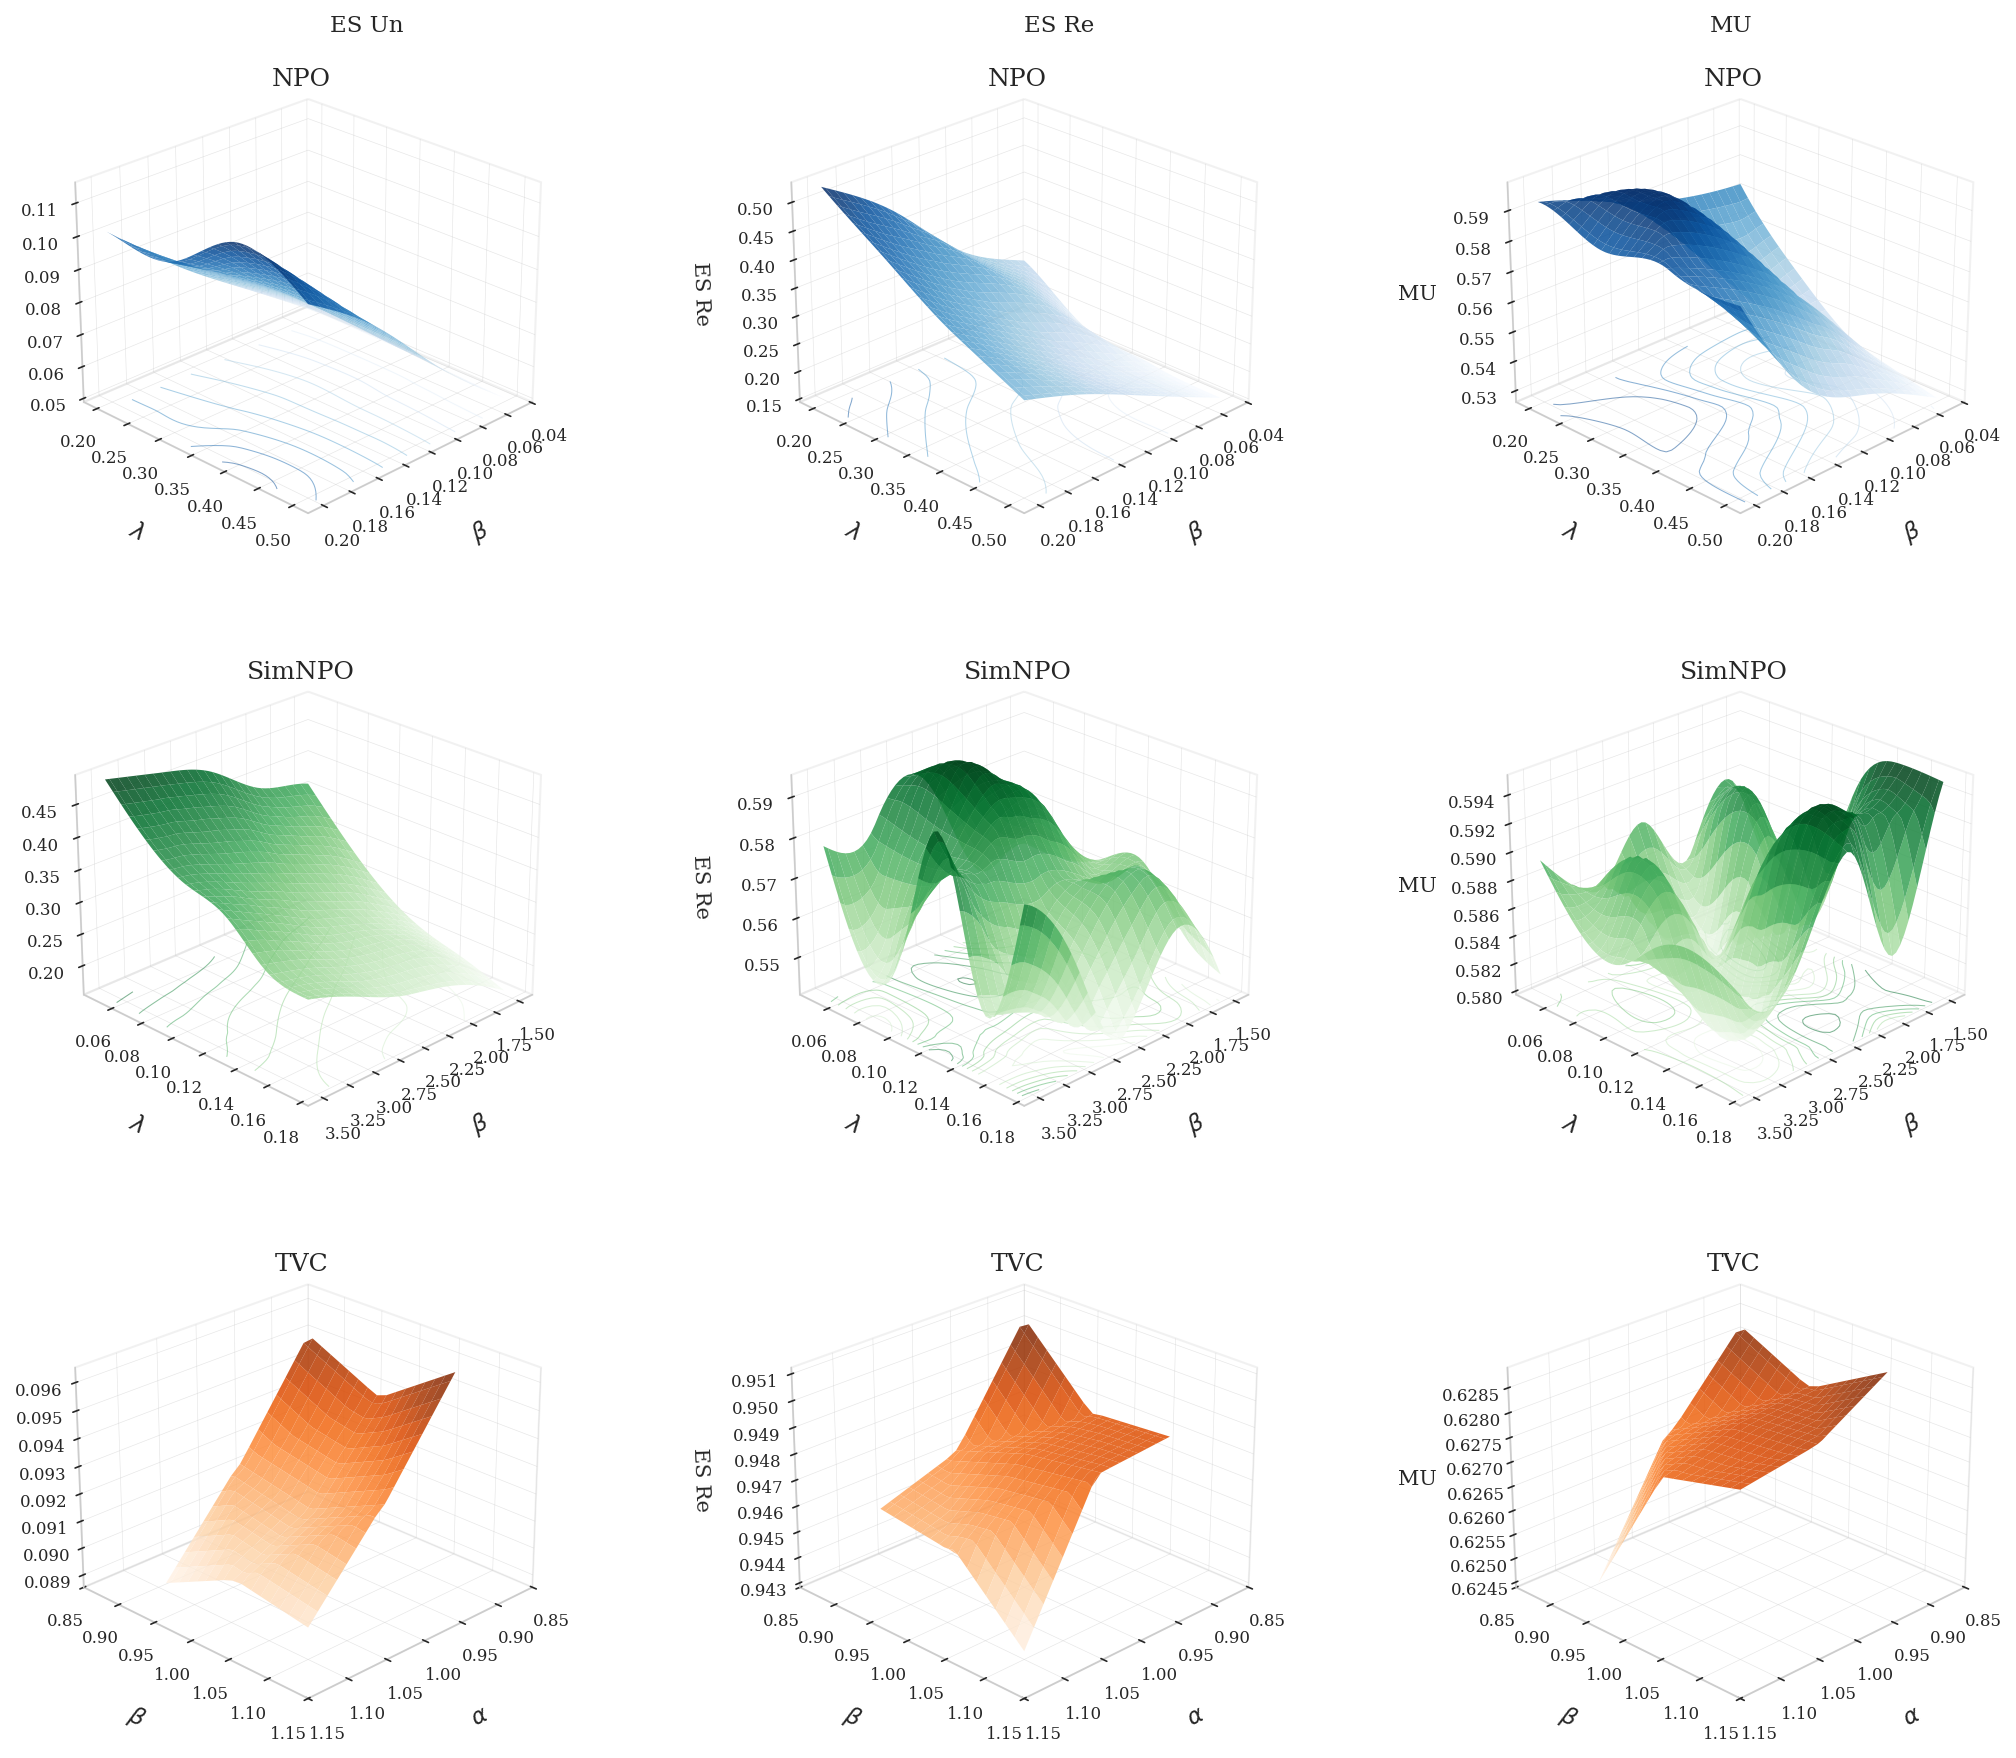


图表已保存: three_methods_parameter_stability.pdf/.png


In [84]:
# 可视化: NPO/SimNPO/TVC 参数稳定性对比（3D 曲面合并图）
# NPO/SimNPO 使用 Beta 和 Lambda 作为坐标 (原gamma改为lambda)
# TVC 使用 Alpha 和 Beta 作为坐标
# 仅使用 Llama 模型数据
# ICML 论文风格

from mpl_toolkits.mplot3d import Axes3D
from scipy.interpolate import griddata
import matplotlib.pyplot as plt
import matplotlib as mpl

# ============ ICML 论文风格设置 ============
plt.style.use('seaborn-v0_8-whitegrid')
mpl.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'figure.titlesize': 14,
    'axes.linewidth': 0.8,
    'grid.linewidth': 0.5,
    'lines.linewidth': 1.5,
    'text.usetex': False,  # 如果系统支持LaTeX可设为True
})

target_forget_set = 'forget10'
target_methods = ['NPO', 'SimNPO', 'TVC']
target_model = 'Llama-2-7b-chat-hf'  # 只使用 Llama 模型

# TVC 方法的 alpha/beta 绘制范围
TVC_PARAM_MIN = 0.85
TVC_PARAM_MAX = 1.15

# 定义关键指标 - 简洁的标签适合论文
key_metrics = ['extraction_strength', 'extraction_strength_retain', 'model_utility']
key_metric_labels = {
    'extraction_strength': 'ES Un',
    'extraction_strength_retain': 'ES Re',
    'model_utility': 'MU'
}

# ICML风格配色方案
method_colors = {
    'NPO': 'Blues',
    'SimNPO': 'Greens', 
    'TVC': 'Oranges'
}

# 使用 all_data 作为数据源，并筛选 Llama 模型
df = all_data[all_data['model'] == target_model].copy()
print(f"Filtering {target_model} model data, total {len(df)} records")

# 创建一个大图：3行（方法）x 3列（指标）- ICML论文尺寸
fig = plt.figure(figsize=(14, 12), dpi=150)

for method_idx, method in enumerate(target_methods):
    print(f"\nProcessing {method} on {target_forget_set}...")
    
    # 根据方法类型选择不同的参数 - gamma 改为 lambda
    if method in ['NPO', 'SimNPO']:
        param1, param2 = 'beta', 'gamma'
        param1_label, param2_label = r'$\beta$', r'$\lambda$'  # gamma → lambda
    else:  # TVC
        param1, param2 = 'alpha', 'beta'
        param1_label, param2_label = r'$\alpha$', r'$\beta$'
    
    # 过滤数据：特定方法和遗忘集
    method_mask = (df['method'] == method) & \
                  (df['forget_set'] == target_forget_set) & \
                  (df[param1].notna()) & \
                  (df[param2].notna())
    
    # TVC方法限制alpha和beta范围为0.8到1.2
    if method == 'TVC':
        method_mask = method_mask & \
                      (df['alpha'] >= TVC_PARAM_MIN) & (df['alpha'] <= TVC_PARAM_MAX) & \
                      (df['beta'] >= TVC_PARAM_MIN) & (df['beta'] <= TVC_PARAM_MAX)
    
    df_focus = df[method_mask].copy()

    if len(df_focus) < 4:
        print(f"  Warning: {method} has insufficient data points (<4), skipping.")
        continue

    print(f"  Data points: {len(df_focus)}")
    print(f"  {param1} range: [{df_focus[param1].min():.2f}, {df_focus[param1].max():.2f}]")
    print(f"  {param2} range: [{df_focus[param2].min():.2f}, {df_focus[param2].max():.2f}]")

    for idx, metric in enumerate(key_metrics):
        if metric not in df_focus.columns:
            continue
            
        # 计算子图位置：共有 3 行，3 列
        plot_idx = method_idx * 3 + idx + 1
        ax = fig.add_subplot(3, 3, plot_idx, projection='3d')
        
        # 获取有效数据 (去除 metric 为 NaN 的点)
        valid_mask = df_focus[metric].notna()
        param1_vals = df_focus.loc[valid_mask, param1].values
        param2_vals = df_focus.loc[valid_mask, param2].values
        values = df_focus.loc[valid_mask, metric].values
        
        if len(values) < 3:
            print(f"  Skipping {metric}: not enough valid points.")
            continue

        # 创建网格 - TVC 方法固定范围为 0.8-1.2
        grid_res = 50
        if method == 'TVC':
            ti_param1 = np.linspace(TVC_PARAM_MIN, TVC_PARAM_MAX, grid_res)
            ti_param2 = np.linspace(TVC_PARAM_MIN, TVC_PARAM_MAX, grid_res)
        else:
            ti_param1 = np.linspace(param1_vals.min(), param1_vals.max(), grid_res)
            ti_param2 = np.linspace(param2_vals.min(), param2_vals.max(), grid_res)
        TI_param1, TI_param2 = np.meshgrid(ti_param1, ti_param2)
        
        # 稳健插值逻辑
        ZI = None
        try:
            ZI = griddata((param1_vals, param2_vals), values, (TI_param1, TI_param2), method='cubic')
            if np.isnan(ZI).any(): 
                ZI = griddata((param1_vals, param2_vals), values, (TI_param1, TI_param2), method='linear')
        except Exception:
            try:
                ZI = griddata((param1_vals, param2_vals), values, (TI_param1, TI_param2), method='linear')
            except:
                pass
        
        if ZI is None or np.isnan(ZI).all():
             ZI = griddata((param1_vals, param2_vals), values, (TI_param1, TI_param2), method='nearest')
        
        # 绘制拟合曲面 - ICML风格
        cmap = plt.cm.get_cmap(method_colors.get(method, 'viridis'))
        surf = ax.plot_surface(TI_param1, TI_param2, ZI, cmap=cmap, 
                              edgecolor='none', alpha=0.85, antialiased=True,
                              rstride=2, cstride=2, shade=True)
        
        # 添加等高线投影到底部 - 增加可读性
        ax.contour(TI_param1, TI_param2, ZI, zdir='z', offset=ZI.min() - 0.05*(ZI.max()-ZI.min()),
                   cmap=cmap, alpha=0.5, levels=8, linewidths=0.5)
        
        # 设置坐标轴标签 - ICML风格
        ax.set_xlabel(param1_label, fontsize=11, labelpad=8)
        ax.set_ylabel(param2_label, fontsize=11, labelpad=8)
        ax.set_zlabel(key_metric_labels.get(metric, metric), fontsize=10, labelpad=5)
        
        # TVC 方法固定坐标轴范围为 0.8-1.2
        if method == 'TVC':
            ax.set_xlim(TVC_PARAM_MIN, TVC_PARAM_MAX)
            ax.set_ylim(TVC_PARAM_MIN, TVC_PARAM_MAX)
        
        # 设置标题 - 简洁的ICML风格
        title_str = f'{method}'
        ax.set_title(title_str, fontsize=12, pad=2, y=1.0)
        
        # 优化视角
        ax.view_init(elev=25, azim=45)
        
        # ICML风格：简洁的背景
        ax.xaxis.pane.fill = False
        ax.yaxis.pane.fill = False
        ax.zaxis.pane.fill = False
        ax.xaxis.pane.set_edgecolor('lightgray')
        ax.yaxis.pane.set_edgecolor('lightgray')
        ax.zaxis.pane.set_edgecolor('lightgray')
        ax.xaxis.pane.set_alpha(0.3)
        ax.yaxis.pane.set_alpha(0.3)
        ax.zaxis.pane.set_alpha(0.3)
        
        # 淡化网格线
        ax.xaxis._axinfo["grid"]['color'] = (0.8, 0.8, 0.8, 0.5)
        ax.yaxis._axinfo["grid"]['color'] = (0.8, 0.8, 0.8, 0.5)
        ax.zaxis._axinfo["grid"]['color'] = (0.8, 0.8, 0.8, 0.5)
        ax.xaxis._axinfo["grid"]['linewidth'] = 0.3
        ax.yaxis._axinfo["grid"]['linewidth'] = 0.3
        ax.zaxis._axinfo["grid"]['linewidth'] = 0.3
        
        # 设置刻度
        ax.tick_params(axis='both', which='major', labelsize=8, pad=2)

# 添加列标题（指标名称）
fig.text(0.19, 0.96, key_metric_labels['extraction_strength'], ha='center', fontsize=11)
fig.text(0.52, 0.96, key_metric_labels['extraction_strength_retain'], ha='center', fontsize=11)
fig.text(0.84, 0.96, key_metric_labels['model_utility'], ha='center', fontsize=11)

# 去掉大标题，调整布局
plt.tight_layout()
plt.subplots_adjust(top=0.95, hspace=0.18, wspace=0.15)

# 保存为高质量PDF和PNG
plt.savefig("three_methods_parameter_stability.pdf", bbox_inches='tight', dpi=300)
plt.savefig("three_methods_parameter_stability.png", bbox_inches='tight', dpi=300)
plt.show()

print("\n图表已保存: three_methods_parameter_stability.pdf/.png")

Filtering Llama-2-7b-chat-hf model data, total 110 records

Processing NPO on forget05...
  Data points: 16
  beta range: [0.05, 0.20]
  gamma range: [0.20, 0.50]

Processing SimNPO on forget05...
  Data points: 9
  beta range: [2.00, 2.50]
  gamma range: [0.10, 0.20]

Processing TVC on forget05...
  Data points: 9
  alpha range: [0.90, 1.10]
  beta range: [0.90, 1.10]


/tmp/ipykernel_4056/2104401444.py:90: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(method_colors.get(method, 'viridis'))


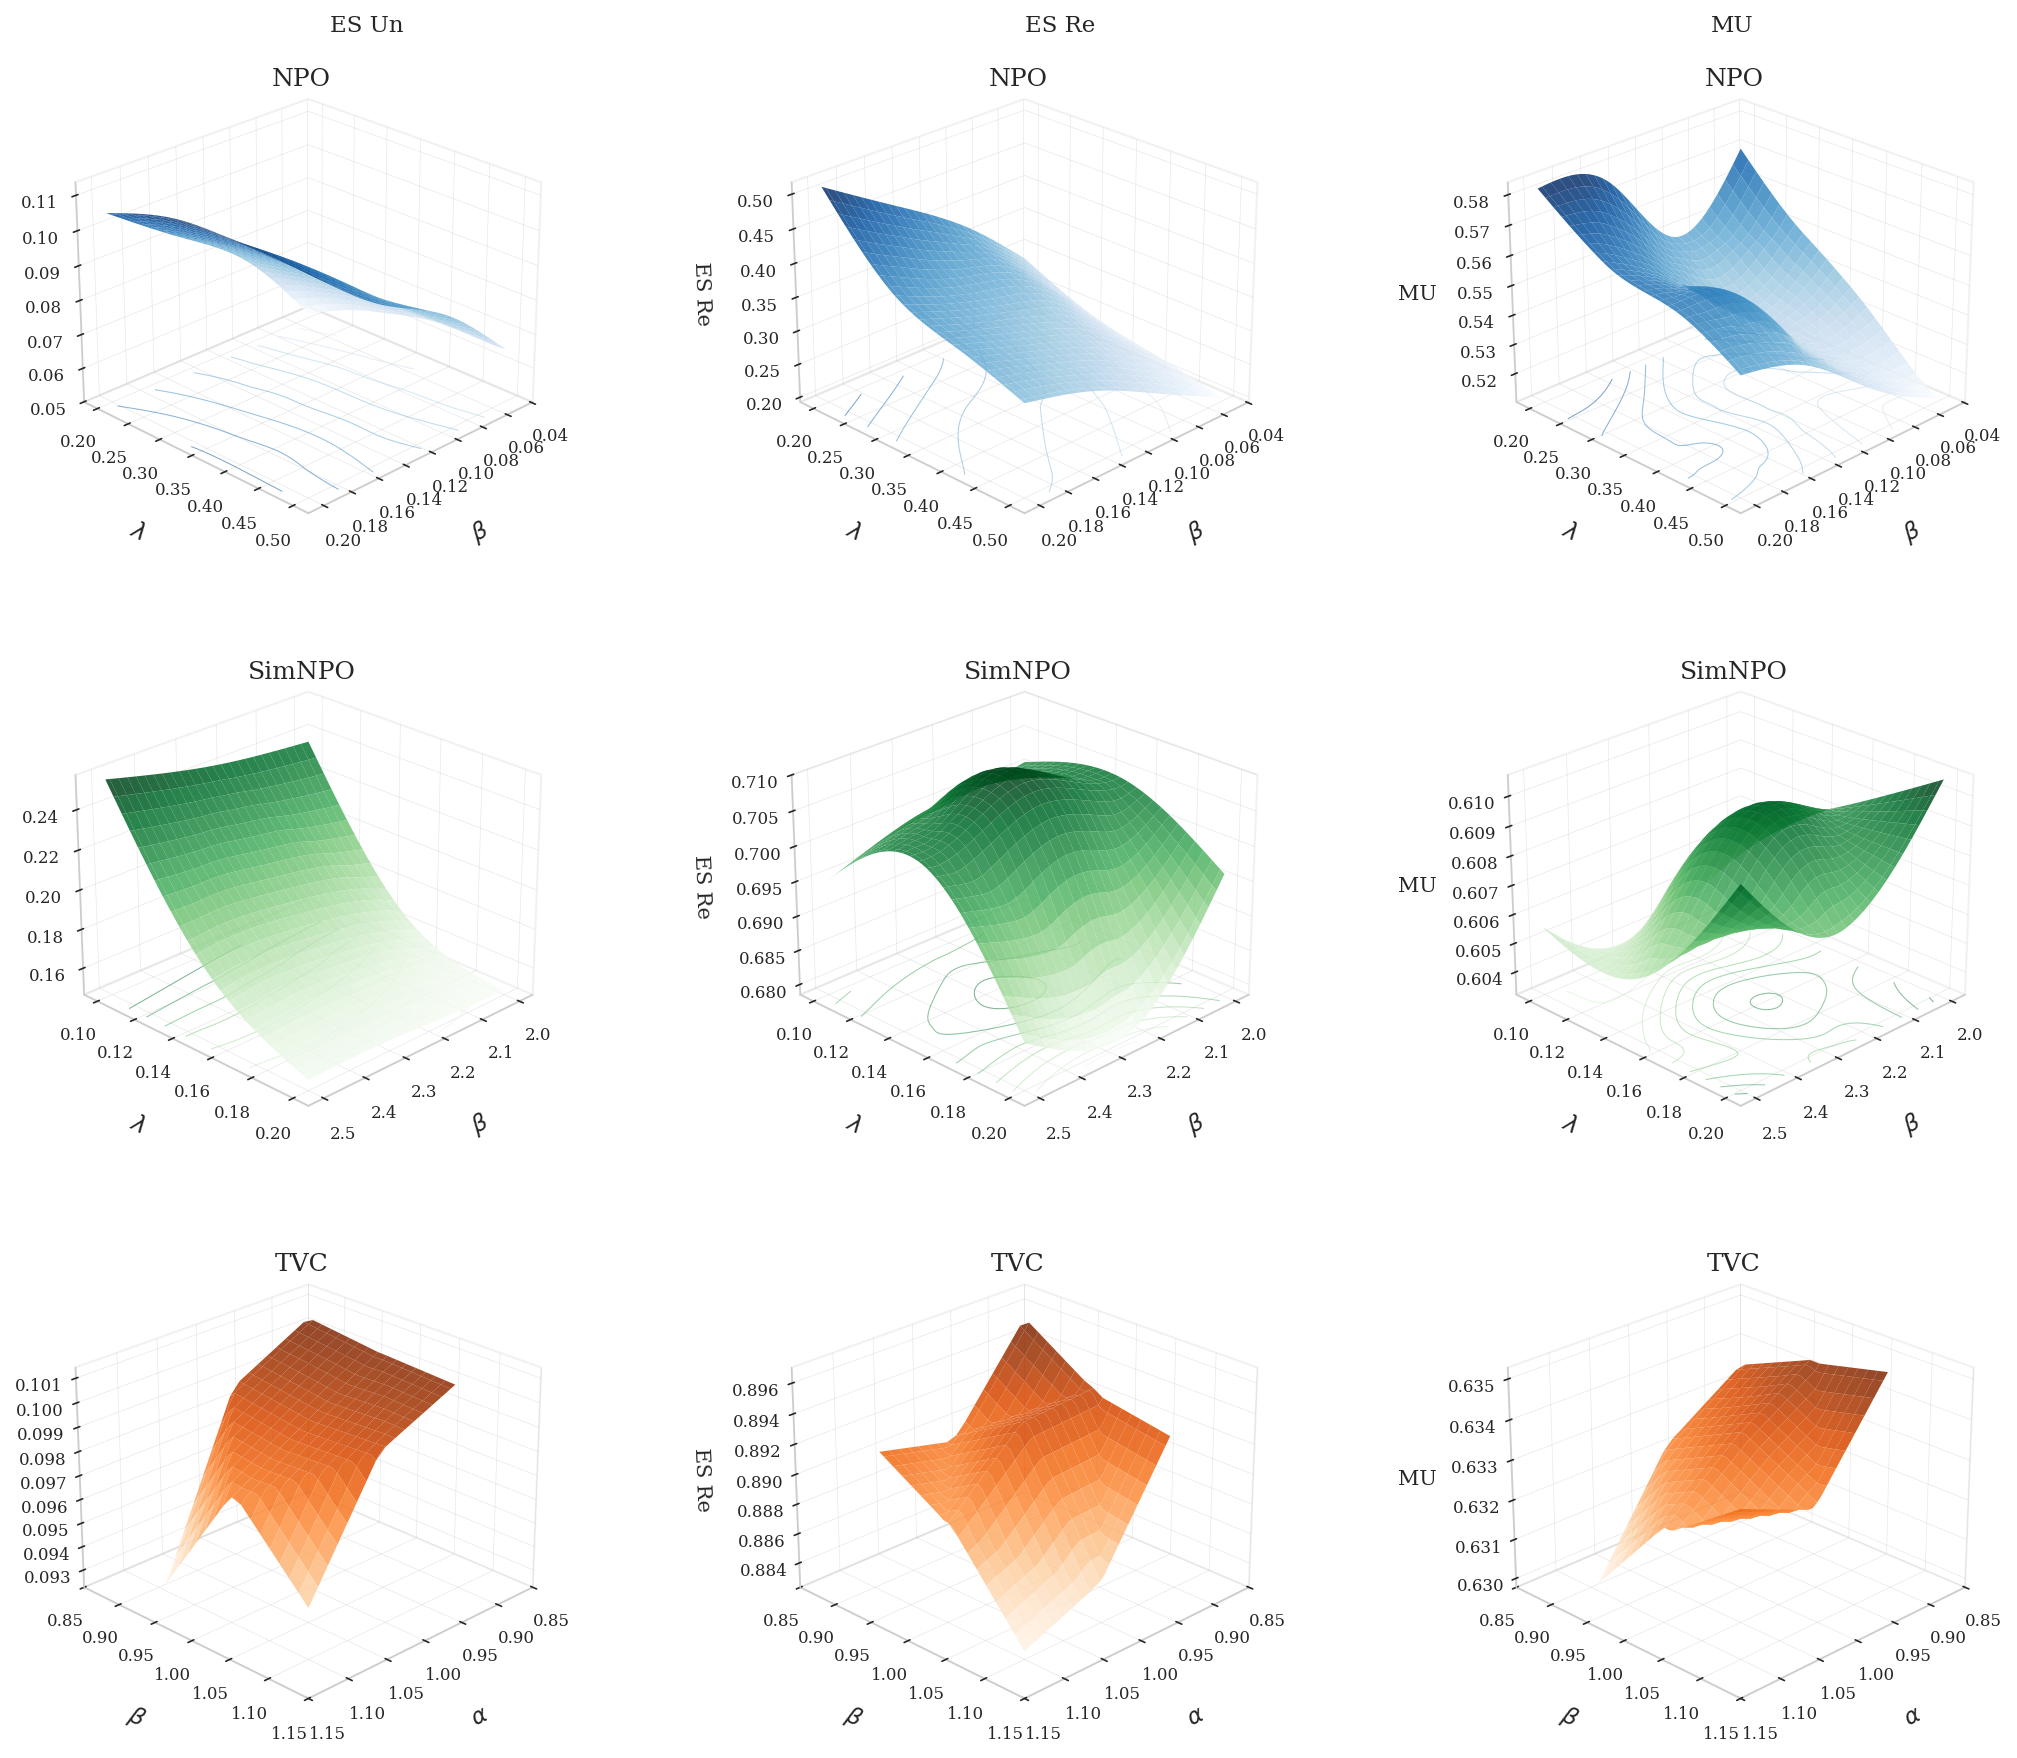


图表已保存: three_methods_parameter_stability_forget05.pdf/.png


In [85]:
# Forget05 版本的参数稳定性对比图 - ICML论文风格
# 仅使用 Llama 模型数据
target_forget_set = 'forget05'
target_model = 'Llama-2-7b-chat-hf'  # 只使用 Llama 模型

# TVC 方法的 alpha/beta 绘制范围
TVC_PARAM_MIN = 0.85
TVC_PARAM_MAX = 1.15

# 筛选 Llama 模型数据
df = all_data[all_data['model'] == target_model].copy()
print(f"Filtering {target_model} model data, total {len(df)} records")

# ICML论文风格图表
fig = plt.figure(figsize=(14, 12), dpi=150)

for method_idx, method in enumerate(target_methods):
    print(f"\nProcessing {method} on {target_forget_set}...")
    
    # 根据方法类型选择不同的参数 - gamma 改为 lambda
    if method in ['NPO', 'SimNPO']:
        param1, param2 = 'beta', 'gamma'
        param1_label, param2_label = r'$\beta$', r'$\lambda$'  # gamma → lambda
    else:  # TVC
        param1, param2 = 'alpha', 'beta'
        param1_label, param2_label = r'$\alpha$', r'$\beta$'
    
    # 过滤数据
    method_mask = (df['method'] == method) & \
                  (df['forget_set'] == target_forget_set) & \
                  (df[param1].notna()) & \
                  (df[param2].notna())
    
    # TVC方法限制alpha和beta范围为0.8到1.2
    if method == 'TVC':
        method_mask = method_mask & \
                      (df['alpha'] >= TVC_PARAM_MIN) & (df['alpha'] <= TVC_PARAM_MAX) & \
                      (df['beta'] >= TVC_PARAM_MIN) & (df['beta'] <= TVC_PARAM_MAX)
    
    df_focus = df[method_mask].copy()

    if len(df_focus) < 4:
        print(f"  Warning: {method} has insufficient data points (<4), skipping.")
        continue

    print(f"  Data points: {len(df_focus)}")
    print(f"  {param1} range: [{df_focus[param1].min():.2f}, {df_focus[param1].max():.2f}]")
    print(f"  {param2} range: [{df_focus[param2].min():.2f}, {df_focus[param2].max():.2f}]")

    for idx, metric in enumerate(key_metrics):
        if metric not in df_focus.columns:
            continue
            
        plot_idx = method_idx * 3 + idx + 1
        ax = fig.add_subplot(3, 3, plot_idx, projection='3d')
        
        valid_mask = df_focus[metric].notna()
        param1_vals = df_focus.loc[valid_mask, param1].values
        param2_vals = df_focus.loc[valid_mask, param2].values
        values = df_focus.loc[valid_mask, metric].values
        
        if len(values) < 3:
            continue

        # 创建网格 - TVC 方法固定范围为 0.8-1.2
        grid_res = 50
        if method == 'TVC':
            ti_param1 = np.linspace(TVC_PARAM_MIN, TVC_PARAM_MAX, grid_res)
            ti_param2 = np.linspace(TVC_PARAM_MIN, TVC_PARAM_MAX, grid_res)
        else:
            ti_param1 = np.linspace(param1_vals.min(), param1_vals.max(), grid_res)
            ti_param2 = np.linspace(param2_vals.min(), param2_vals.max(), grid_res)
        TI_param1, TI_param2 = np.meshgrid(ti_param1, ti_param2)
        
        ZI = None
        try:
            ZI = griddata((param1_vals, param2_vals), values, (TI_param1, TI_param2), method='cubic')
            if np.isnan(ZI).any(): 
                ZI = griddata((param1_vals, param2_vals), values, (TI_param1, TI_param2), method='linear')
        except Exception:
            try:
                ZI = griddata((param1_vals, param2_vals), values, (TI_param1, TI_param2), method='linear')
            except:
                pass
        
        if ZI is None or np.isnan(ZI).all():
             ZI = griddata((param1_vals, param2_vals), values, (TI_param1, TI_param2), method='nearest')
        
        # ICML风格曲面
        cmap = plt.cm.get_cmap(method_colors.get(method, 'viridis'))
        surf = ax.plot_surface(TI_param1, TI_param2, ZI, cmap=cmap, 
                              edgecolor='none', alpha=0.85, antialiased=True,
                              rstride=2, cstride=2, shade=True)
        
        # 添加等高线投影
        ax.contour(TI_param1, TI_param2, ZI, zdir='z', offset=ZI.min() - 0.05*(ZI.max()-ZI.min()),
                   cmap=cmap, alpha=0.5, levels=8, linewidths=0.5)
        
        # ICML风格标签
        ax.set_xlabel(param1_label, fontsize=11, labelpad=8)
        ax.set_ylabel(param2_label, fontsize=11, labelpad=8)
        ax.set_zlabel(key_metric_labels.get(metric, metric), fontsize=10, labelpad=5)
        
        # TVC 方法固定坐标轴范围为 0.8-1.2
        if method == 'TVC':
            ax.set_xlim(TVC_PARAM_MIN, TVC_PARAM_MAX)
            ax.set_ylim(TVC_PARAM_MIN, TVC_PARAM_MAX)
        
        # 简洁标题
        title_str = f'{method}'
        ax.set_title(title_str, fontsize=12, pad=2, y=1.0)
        
        ax.view_init(elev=25, azim=45)
        
        # ICML风格背景
        ax.xaxis.pane.fill = False
        ax.yaxis.pane.fill = False
        ax.zaxis.pane.fill = False
        ax.xaxis.pane.set_edgecolor('lightgray')
        ax.yaxis.pane.set_edgecolor('lightgray')
        ax.zaxis.pane.set_edgecolor('lightgray')
        ax.xaxis.pane.set_alpha(0.3)
        ax.yaxis.pane.set_alpha(0.3)
        ax.zaxis.pane.set_alpha(0.3)
        
        ax.xaxis._axinfo["grid"]['color'] = (0.8, 0.8, 0.8, 0.5)
        ax.yaxis._axinfo["grid"]['color'] = (0.8, 0.8, 0.8, 0.5)
        ax.zaxis._axinfo["grid"]['color'] = (0.8, 0.8, 0.8, 0.5)
        ax.xaxis._axinfo["grid"]['linewidth'] = 0.3
        ax.yaxis._axinfo["grid"]['linewidth'] = 0.3
        ax.zaxis._axinfo["grid"]['linewidth'] = 0.3
        
        ax.tick_params(axis='both', which='major', labelsize=8, pad=2)

# 添加列标题
fig.text(0.19, 0.96, key_metric_labels['extraction_strength'], ha='center', fontsize=11)
fig.text(0.52, 0.96, key_metric_labels['extraction_strength_retain'], ha='center', fontsize=11)
fig.text(0.84, 0.96, key_metric_labels['model_utility'], ha='center', fontsize=11)

# 去掉大标题，调整布局
plt.tight_layout()
plt.subplots_adjust(top=0.95, hspace=0.18, wspace=0.15)

# 保存高质量图表
plt.savefig("three_methods_parameter_stability_forget05.pdf", bbox_inches='tight', dpi=300)
plt.savefig("three_methods_parameter_stability_forget05.png", bbox_inches='tight', dpi=300)
plt.show()

print("\n图表已保存: three_methods_parameter_stability_forget05.pdf/.png")

## 论文级参数敏感性分析（2D热力图 + 量化指标）

相比3D曲面图，2D热力图具有以下优势：
- 更清晰、更紧凑，易于精确读取数值
- 打印友好（黑白也能区分）
- 便于横向比较不同方法


Forget Set: forget10

  统一颜色范围:
    ES Un: [0.0502, 0.4876]
    ES Re: [0.1520, 0.9555]
    MU: [0.5276, 0.6323]

  NPO: 15 数据点

  SimNPO: 25 数据点

  TVC: 25 数据点


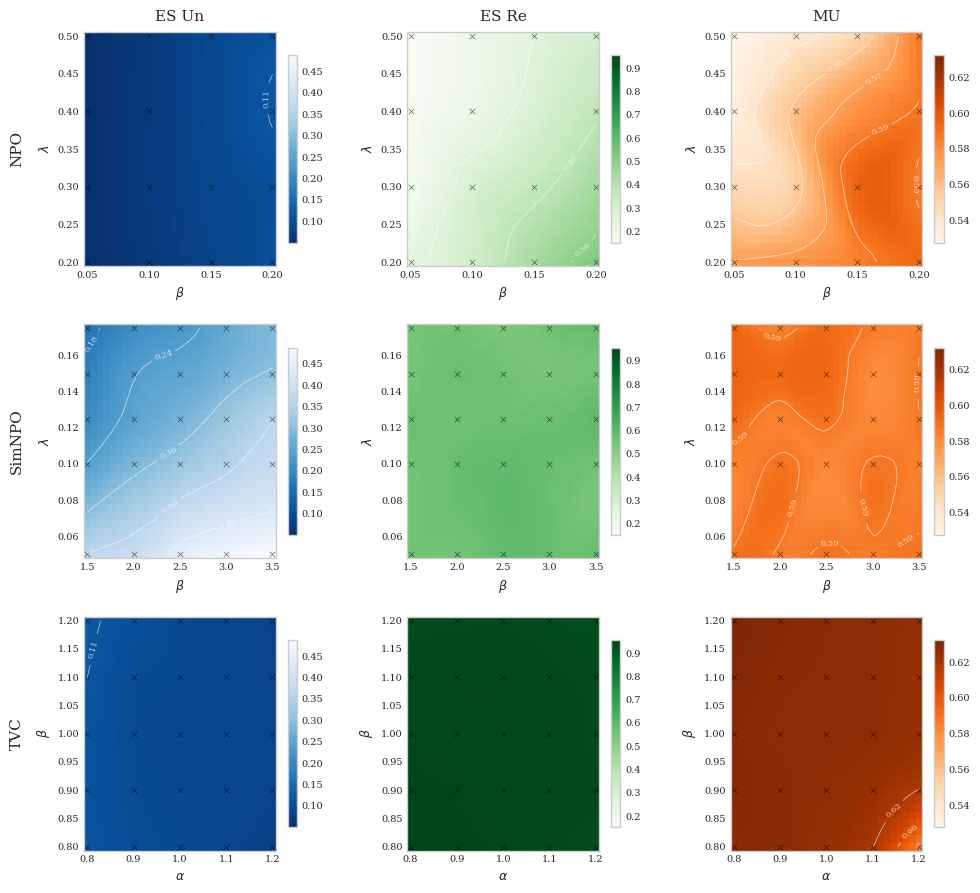


  图表已保存: parameter_sensitivity_heatmap_forget10.pdf/.png

参数敏感性量化分析 - forget10

【各方法的参数敏感性指标】
CV (变异系数) 越小表示越稳定


变异系数 (CV) - 越小越稳定:


Metric,ES Re,ES Un,MU
Method,,,
NPO,0.3607,0.2706,0.0392
SimNPO,0.0232,0.2823,0.0069
TVC,0.0072,0.1043,0.0143



标准差 (Std):


Metric,ES Re,ES Un,MU
Method,,,
NPO,0.1084,0.0210,0.0222
SimNPO,0.0132,0.0851,0.0041
TVC,0.0068,0.0099,0.0089



数值范围 (Range):


Metric,ES Re,ES Un,MU
Method,,,
NPO,0.3744,0.0644,0.0671
SimNPO,0.0509,0.3270,0.0142
TVC,0.0234,0.0409,0.0472



【综合稳定性排名】

平均变异系数 (越小越稳定):
  🥇 TVC: 0.0419
  🥈 SimNPO: 0.1041
  🥉 NPO: 0.2235


In [86]:
# ============================================================
# 论文级参数敏感性分析：2D热力图 + 量化稳定性指标
# 仅分析 forget10，统一每种指标的颜色范围
# ============================================================

import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from scipy.interpolate import griddata
import numpy as np
from matplotlib.colors import Normalize

# ICML 论文风格
plt.style.use('seaborn-v0_8-whitegrid')
mpl.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'font.size': 9,
    'axes.labelsize': 10,
    'axes.titlesize': 11,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
})

target_model = 'Llama-2-7b-chat-hf'
target_methods = ['NPO', 'SimNPO', 'TVC']
forget_set = 'forget10'  # 只分析forget10

# 指标配置
metrics_config = {
    'extraction_strength': {'label': 'ES Un', 'cmap': 'Blues_r', 'better': 'lower'},
    'extraction_strength_retain': {'label': 'ES Re', 'cmap': 'Greens', 'better': 'higher'},
    'model_utility': {'label': 'MU', 'cmap': 'Oranges', 'better': 'higher'}
}
metrics_order = list(metrics_config.keys())

# TVC 参数范围
TVC_PARAM_MIN, TVC_PARAM_MAX = 0.8, 1.2

# 存储稳定性统计
stability_stats = []

def compute_stability_metrics(values):
    """计算稳定性指标"""
    if len(values) < 2:
        return {'std': np.nan, 'cv': np.nan, 'range': np.nan, 'iqr': np.nan}
    
    std = np.std(values)
    mean = np.mean(values)
    cv = std / mean if mean != 0 else np.nan
    val_range = np.max(values) - np.min(values)
    iqr = np.percentile(values, 75) - np.percentile(values, 25)
    
    return {'std': std, 'cv': cv, 'range': val_range, 'iqr': iqr}

# ============ 创建热力图（统一颜色范围）============
print(f"\n{'='*60}")
print(f"Forget Set: {forget_set}")
print(f"{'='*60}")

df = all_data[all_data['model'] == target_model].copy()

# === 第一步：收集所有方法的数据，计算每个指标的全局min/max ===
global_ranges = {metric: {'min': np.inf, 'max': -np.inf} for metric in metrics_order}
method_data_cache = {}  # 缓存每个方法的数据和插值结果

for method in target_methods:
    if method in ['NPO', 'SimNPO']:
        param1, param2 = 'beta', 'gamma'
    else:
        param1, param2 = 'alpha', 'beta'
    
    mask = (df['method'] == method) & (df['forget_set'] == forget_set) & \
           df[param1].notna() & df[param2].notna()
    
    if method == 'TVC':
        mask = mask & (df['alpha'] >= TVC_PARAM_MIN) & (df['alpha'] <= TVC_PARAM_MAX) & \
               (df['beta'] >= TVC_PARAM_MIN) & (df['beta'] <= TVC_PARAM_MAX)
    
    df_method = df[mask].copy()
    
    if len(df_method) < 4:
        continue
    
    method_data_cache[method] = {
        'df': df_method,
        'param1': param1,
        'param2': param2,
        'interpolated': {}
    }
    
    # 计算每个指标的数据范围
    for metric in metrics_order:
        z_vals = df_method[metric].values
        p1_vals = df_method[param1].values
        p2_vals = df_method[param2].values
        
        # 插值 - 使用实际数据范围避免空白区域
        grid_res = 30
        xi = np.linspace(p1_vals.min(), p1_vals.max(), grid_res)
        yi = np.linspace(p2_vals.min(), p2_vals.max(), grid_res)
        
        XI, YI = np.meshgrid(xi, yi)
        
        # 先尝试cubic插值，再用nearest填充NaN
        try:
            ZI = griddata((p1_vals, p2_vals), z_vals, (XI, YI), method='cubic')
            if np.isnan(ZI).any():
                ZI_nearest = griddata((p1_vals, p2_vals), z_vals, (XI, YI), method='nearest')
                ZI = np.where(np.isnan(ZI), ZI_nearest, ZI)
        except:
            ZI = griddata((p1_vals, p2_vals), z_vals, (XI, YI), method='nearest')
        
        # 缓存插值结果
        method_data_cache[method]['interpolated'][metric] = {
            'XI': XI, 'YI': YI, 'ZI': ZI,
            'p1_vals': p1_vals, 'p2_vals': p2_vals, 'z_vals': z_vals
        }
        
        # 更新全局范围
        valid_z = ZI[~np.isnan(ZI)]
        if len(valid_z) > 0:
            global_ranges[metric]['min'] = min(global_ranges[metric]['min'], np.min(valid_z))
            global_ranges[metric]['max'] = max(global_ranges[metric]['max'], np.max(valid_z))

# 打印全局范围
print("\n  统一颜色范围:")
for metric, config in metrics_config.items():
    vmin, vmax = global_ranges[metric]['min'], global_ranges[metric]['max']
    print(f"    {config['label']}: [{vmin:.4f}, {vmax:.4f}]")

# === 第二步：使用统一范围绘制热力图 ===
fig, axes = plt.subplots(3, 3, figsize=(10, 9))

for method_idx, method in enumerate(target_methods):
    if method not in method_data_cache:
        print(f"  {method}: 数据不足，跳过")
        continue
    
    cache = method_data_cache[method]
    df_method = cache['df']
    param1, param2 = cache['param1'], cache['param2']
    
    if method in ['NPO', 'SimNPO']:
        param1_label, param2_label = r'$\beta$', r'$\lambda$'
    else:
        param1_label, param2_label = r'$\alpha$', r'$\beta$'
    
    print(f"\n  {method}: {len(df_method)} 数据点")
    
    for metric_idx, metric in enumerate(metrics_order):
        ax = axes[method_idx, metric_idx]
        config = metrics_config[metric]
        
        # 获取缓存的插值数据
        interp_data = cache['interpolated'][metric]
        XI, YI, ZI = interp_data['XI'], interp_data['YI'], interp_data['ZI']
        p1_vals, p2_vals, z_vals = interp_data['p1_vals'], interp_data['p2_vals'], interp_data['z_vals']
        
        # 计算稳定性统计
        stats = compute_stability_metrics(z_vals)
        stability_stats.append({
            'Method': method,
            'Forget Set': forget_set,
            'Metric': config['label'],
            'Mean': np.mean(z_vals),
            'Std': stats['std'],
            'CV': stats['cv'],
            'Range': stats['range'],
            'IQR': stats['iqr']
        })
        
        # 使用统一的颜色范围
        vmin, vmax = global_ranges[metric]['min'], global_ranges[metric]['max']
        norm = Normalize(vmin=vmin, vmax=vmax)
        
        # 绘制热力图
        im = ax.pcolormesh(XI, YI, ZI, cmap=config['cmap'], shading='auto', norm=norm)
        
        # 添加等高线（使用统一范围的等间距levels）
        try:
            levels = np.linspace(vmin, vmax, 8)
            cs = ax.contour(XI, YI, ZI, levels=levels, colors='white', linewidths=0.5, alpha=0.7)
            ax.clabel(cs, inline=True, fontsize=6, fmt='%.2f')
        except:
            pass
        
        # 标记实际数据点
        ax.scatter(p1_vals, p2_vals, c='black', s=15, marker='x', alpha=0.6, linewidths=0.5)
        
        # 添加colorbar（统一范围）
        cbar = plt.colorbar(im, ax=ax, shrink=0.8, aspect=20)
        cbar.ax.tick_params(labelsize=7)
        
        # 设置标签
        ax.set_xlabel(param1_label, fontsize=9)
        ax.set_ylabel(param2_label, fontsize=9)
        
        # 第一行添加指标标题
        if method_idx == 0:
            ax.set_title(config['label'], fontsize=11, pad=8)
        
        # 第一列添加方法名
        if metric_idx == 0:
            ax.text(-0.35, 0.5, method, transform=ax.transAxes, fontsize=11,
                   va='center', ha='center', rotation=90)
        
        ax.tick_params(axis='both', labelsize=7)

plt.tight_layout()
plt.subplots_adjust(left=0.1, wspace=0.35, hspace=0.25)

# 保存
filename = f"parameter_sensitivity_heatmap_{forget_set}"
plt.savefig(f"{filename}.pdf", bbox_inches='tight', dpi=300)
plt.savefig(f"{filename}.png", bbox_inches='tight', dpi=300)
plt.show()
print(f"\n  图表已保存: {filename}.pdf/.png")

# ============ 稳定性量化表格 ============
print("\n" + "="*80)
print(f"参数敏感性量化分析 - {forget_set}")
print("="*80)

stability_df = pd.DataFrame(stability_stats)

print("\n【各方法的参数敏感性指标】")
print("CV (变异系数) 越小表示越稳定\n")

# 透视表
pivot_cv = stability_df.pivot(index='Method', columns='Metric', values='CV')
pivot_std = stability_df.pivot(index='Method', columns='Metric', values='Std')
pivot_range = stability_df.pivot(index='Method', columns='Metric', values='Range')

print("\n变异系数 (CV) - 越小越稳定:")
display(pivot_cv.round(4))

print("\n标准差 (Std):")
display(pivot_std.round(4))

print("\n数值范围 (Range):")
display(pivot_range.round(4))

# 综合稳定性排名
print("\n" + "="*80)
print("【综合稳定性排名】")
print("="*80)

avg_cv = stability_df.groupby('Method')['CV'].mean().sort_values()
print("\n平均变异系数 (越小越稳定):")
for i, (method, cv) in enumerate(avg_cv.items()):
    rank = ["🥇", "🥈", "🥉"][i] if i < 3 else ""
    print(f"  {rank} {method}: {cv:.4f}")

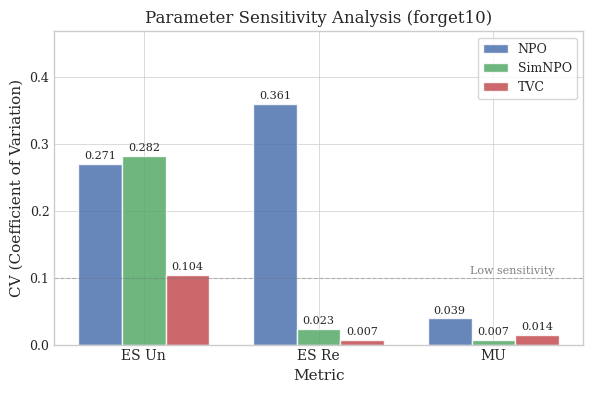


稳定性汇总图已保存: parameter_sensitivity_summary_forget10.pdf/.png

【LaTeX 表格代码 - forget10】

\begin{table}[t]
\centering
\caption{Parameter Sensitivity Analysis on Forget10 (Coefficient of Variation)}
\label{tab:sensitivity}
\begin{tabular}{lccc}
\toprule
Method & ES Un & ES Re & MU \\
\midrule
NPO & 0.271 & 0.361 & 0.039 \\
SimNPO & 0.282 & 0.023 & 0.007 \\
TVC & 0.104 & 0.007 & 0.014 \\
\bottomrule
\end{tabular}
\vspace{1mm}
\footnotesize{Lower CV indicates more stable performance across parameter variations.}
\end{table}



In [87]:
# ============================================================
# 论文最终版：紧凑型稳定性汇总图（仅forget10）
# ============================================================

fig, ax = plt.subplots(1, 1, figsize=(6, 4))

# 使用变异系数 (CV) 作为稳定性指标
metrics_order_labels = ['ES Un', 'ES Re', 'MU']
methods_order = ['NPO', 'SimNPO', 'TVC']
bar_colors = ['#4C72B0', '#55A868', '#C44E52']

# 提取forget10的CV数据
cv_data = stability_df.pivot(index='Method', columns='Metric', values='CV')
cv_data = cv_data.reindex(methods_order)[metrics_order_labels]

# 绘制分组柱状图
x = np.arange(len(metrics_order_labels))
width = 0.25

for i, method in enumerate(methods_order):
    bars = ax.bar(x + i*width, cv_data.loc[method], width, 
                 label=method, color=bar_colors[i], alpha=0.85, edgecolor='white')
    
    # 在柱子上标注数值
    for bar, val in zip(bars, cv_data.loc[method]):
        height = bar.get_height()
        ax.annotate(f'{val:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                   xytext=(0, 2), textcoords='offset points',
                   ha='center', va='bottom', fontsize=8)

ax.set_xlabel('Metric', fontsize=11)
ax.set_ylabel('CV (Coefficient of Variation)', fontsize=11)
ax.set_title(f'Parameter Sensitivity Analysis ({forget_set})', fontsize=12)
ax.set_xticks(x + width)
ax.set_xticklabels(metrics_order_labels, fontsize=10)
ax.tick_params(axis='y', labelsize=9)
ax.set_ylim(0, max(cv_data.max().max() * 1.3, 0.3))

# 添加参考线
ax.axhline(y=0.1, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
ax.text(2.6, 0.105, 'Low sensitivity', fontsize=8, color='gray', ha='right')

# 添加图例
ax.legend(loc='upper right', fontsize=9, frameon=True)

plt.tight_layout()

plt.savefig("parameter_sensitivity_summary_forget10.pdf", bbox_inches='tight', dpi=300)
plt.savefig("parameter_sensitivity_summary_forget10.png", bbox_inches='tight', dpi=300)
plt.show()

print("\n稳定性汇总图已保存: parameter_sensitivity_summary_forget10.pdf/.png")

# ============================================================
# 生成可直接用于论文的LaTeX表格（仅forget10）
# ============================================================
print("\n" + "="*80)
print("【LaTeX 表格代码 - forget10】")
print("="*80)

latex_table = r"""
\begin{table}[t]
\centering
\caption{Parameter Sensitivity Analysis on Forget10 (Coefficient of Variation)}
\label{tab:sensitivity}
\begin{tabular}{lccc}
\toprule
Method & ES Un & ES Re & MU \\
\midrule
"""

for method in methods_order:
    row = stability_df[stability_df['Method'] == method]
    vals = {r['Metric']: r['CV'] for _, r in row.iterrows()}
    
    # 找出每列最小值（最稳定）进行加粗
    latex_table += f"{method} & "
    latex_table += f"{vals.get('ES Un', 0):.3f} & {vals.get('ES Re', 0):.3f} & {vals.get('MU', 0):.3f} \\\\\n"

latex_table += r"""\bottomrule
\end{tabular}
\vspace{1mm}
\footnotesize{Lower CV indicates more stable performance across parameter variations.}
\end{table}
"""

print(latex_table)

Filtering Llama-2-7b-chat-hf model data, total 110 records

Processing NPO...
  Data points: 15
  beta: [0.050, 0.200]
  gamma: [0.200, 0.500]

Processing SimNPO...
  Data points: 25
  beta: [1.500, 3.500]
  gamma: [0.050, 0.175]

Processing TVC...
  Data points: 29
  alpha: [0.800, 1.200]
  beta: [0.700, 1.200]


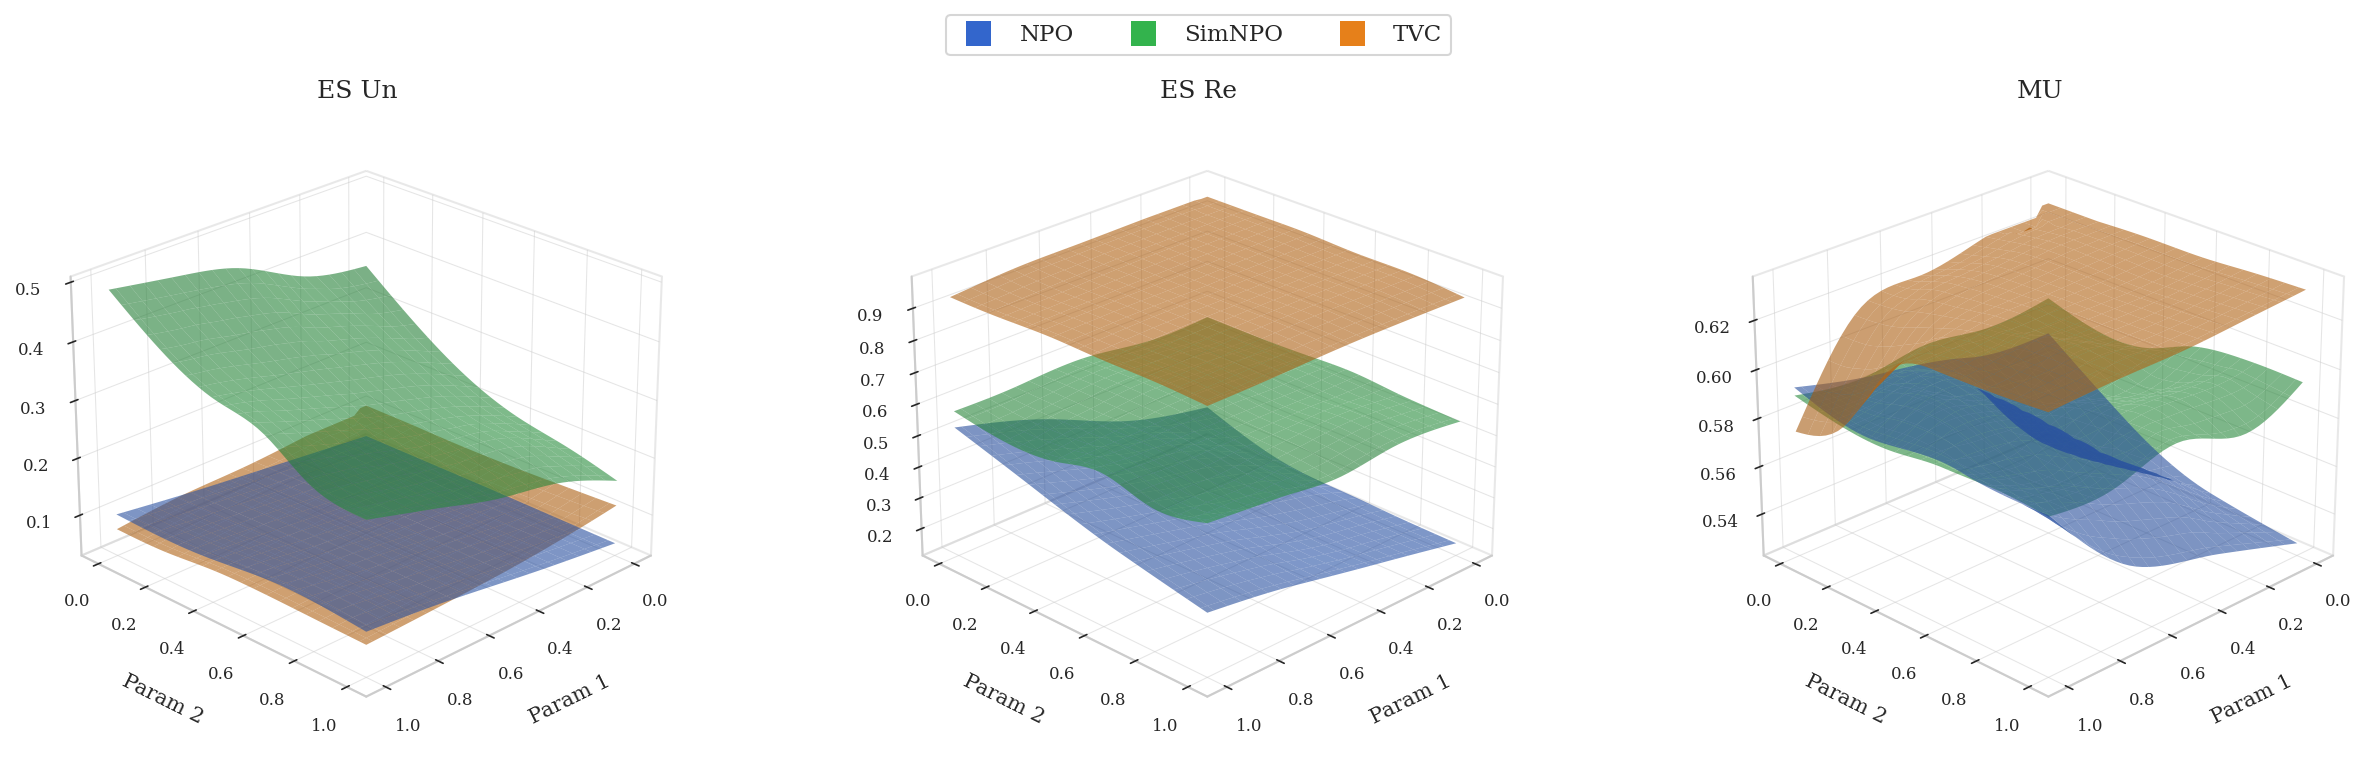


图表已保存: combined_3d_comparison_forget10.pdf/.png

说明：
- 三种方法使用归一化的参数空间 [0,1] × [0,1] 进行对比
- NPO/SimNPO: Param1 = β, Param2 = λ
- TVC: Param1 = α, Param2 = β
- 同一指标下z轴范围统一，便于比较数值变化幅度


In [91]:
# 1×3 布局：三种方法的3D曲面合并到同一张图中进行对比
# 每个子图显示一个指标，三种方法用不同颜色的曲面表示
# 只分析 forget10

from mpl_toolkits.mplot3d import Axes3D
from scipy.interpolate import griddata
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D

# ICML 论文风格设置
plt.style.use('seaborn-v0_8-whitegrid')
mpl.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'text.usetex': False,
})

target_forget_set = 'forget10'
target_methods = ['NPO', 'SimNPO', 'TVC']
target_model = 'Llama-2-7b-chat-hf'

# 定义关键指标
key_metrics = ['extraction_strength', 'extraction_strength_retain', 'model_utility']
key_metric_labels = {
    'extraction_strength': 'ES Un',
    'extraction_strength_retain': 'ES Re',
    'model_utility': 'MU'
}

# 为不同方法定义颜色 - 使用半透明纯色
method_colors_solid = {
    'NPO': (0.2, 0.4, 0.8, 0.6),      # 蓝色
    'SimNPO': (0.2, 0.7, 0.3, 0.6),   # 绿色
    'TVC': (0.9, 0.5, 0.1, 0.6)       # 橙色
}

# 筛选数据
df = all_data[all_data['model'] == target_model].copy()
print(f"Filtering {target_model} model data, total {len(df)} records")

# 预处理：为每种方法计算插值数据，统一到相同的参数空间
# 使用归一化的参数空间 [0, 1] x [0, 1] 进行对比

# 首先收集每种方法的数据和插值结果
method_data_cache = {}
grid_res = 40

for method in target_methods:
    print(f"\nProcessing {method}...")
    
    if method in ['NPO', 'SimNPO']:
        param1, param2 = 'beta', 'gamma'
    else:
        param1, param2 = 'alpha', 'beta'
    
    method_mask = (df['method'] == method) & \
                  (df['forget_set'] == target_forget_set) & \
                  (df[param1].notna()) & \
                  (df[param2].notna())
    
    df_method = df[method_mask].copy()
    
    if len(df_method) < 4:
        print(f"  Warning: insufficient data points")
        continue
    
    # 归一化参数到 [0, 1]
    p1_min, p1_max = df_method[param1].min(), df_method[param1].max()
    p2_min, p2_max = df_method[param2].min(), df_method[param2].max()
    
    df_method['param1_norm'] = (df_method[param1] - p1_min) / (p1_max - p1_min)
    df_method['param2_norm'] = (df_method[param2] - p2_min) / (p2_max - p2_min)
    
    print(f"  Data points: {len(df_method)}")
    print(f"  {param1}: [{p1_min:.3f}, {p1_max:.3f}]")
    print(f"  {param2}: [{p2_min:.3f}, {p2_max:.3f}]")
    
    # 创建统一的归一化网格
    xi = np.linspace(0, 1, grid_res)
    yi = np.linspace(0, 1, grid_res)
    XI, YI = np.meshgrid(xi, yi)
    
    interp_data = {'XI': XI, 'YI': YI, 'param1': param1, 'param2': param2,
                   'p1_range': (p1_min, p1_max), 'p2_range': (p2_min, p2_max)}
    
    for metric in key_metrics:
        valid_mask = df_method[metric].notna()
        p1_vals = df_method.loc[valid_mask, 'param1_norm'].values
        p2_vals = df_method.loc[valid_mask, 'param2_norm'].values
        z_vals = df_method.loc[valid_mask, metric].values
        
        # 插值
        ZI = griddata((p1_vals, p2_vals), z_vals, (XI, YI), method='cubic')
        if np.isnan(ZI).any():
            ZI_linear = griddata((p1_vals, p2_vals), z_vals, (XI, YI), method='linear')
            ZI = np.where(np.isnan(ZI), ZI_linear, ZI)
        if np.isnan(ZI).any():
            ZI_nearest = griddata((p1_vals, p2_vals), z_vals, (XI, YI), method='nearest')
            ZI = np.where(np.isnan(ZI), ZI_nearest, ZI)
        
        interp_data[metric] = ZI
    
    method_data_cache[method] = interp_data

# 创建 1×3 图：每个指标一张图，三种方法的曲面叠加
fig = plt.figure(figsize=(16, 5), dpi=150)

for metric_idx, metric in enumerate(key_metrics):
    ax = fig.add_subplot(1, 3, metric_idx + 1, projection='3d')
    
    # 收集所有方法在该指标上的数值范围，用于统一z轴
    all_z = []
    for method in target_methods:
        if method in method_data_cache and metric in method_data_cache[method]:
            valid_z = method_data_cache[method][metric]
            all_z.extend(valid_z[~np.isnan(valid_z)].flatten())
    
    if len(all_z) == 0:
        continue
    
    z_min, z_max = np.min(all_z), np.max(all_z)
    z_margin = (z_max - z_min) * 0.05
    
    # 绘制每种方法的曲面
    for method in target_methods:
        if method not in method_data_cache:
            continue
        
        cache = method_data_cache[method]
        XI, YI = cache['XI'], cache['YI']
        ZI = cache.get(metric)
        
        if ZI is None:
            continue
        
        # 绘制半透明曲面
        color = method_colors_solid[method]
        surf = ax.plot_surface(XI, YI, ZI, 
                              color=color[:3],  # RGB
                              alpha=color[3],   # 透明度
                              edgecolor='none',
                              antialiased=True,
                              rstride=2, cstride=2,
                              shade=True)
    
    # 设置标签
    ax.set_xlabel('Param 1', fontsize=10, labelpad=8)
    ax.set_ylabel('Param 2', fontsize=10, labelpad=8)
    # ax.set_zlabel(key_metric_labels[metric], fontsize=10, labelpad=5)
    
    # 设置z轴范围一致
    ax.set_zlim(z_min - z_margin, z_max + z_margin)
    
    # 标题
    ax.set_title(key_metric_labels[metric], fontsize=12, pad=5)
    
    # 视角
    ax.view_init(elev=25, azim=45)
    
    # 背景设置
    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False
    ax.xaxis.pane.set_edgecolor('lightgray')
    ax.yaxis.pane.set_edgecolor('lightgray')
    ax.zaxis.pane.set_edgecolor('lightgray')
    
    ax.xaxis._axinfo["grid"]['color'] = (0.8, 0.8, 0.8, 0.5)
    ax.yaxis._axinfo["grid"]['color'] = (0.8, 0.8, 0.8, 0.5)
    ax.zaxis._axinfo["grid"]['color'] = (0.8, 0.8, 0.8, 0.5)
    
    ax.tick_params(axis='both', which='major', labelsize=8)

# 添加图例
legend_elements = [
    Line2D([0], [0], marker='s', color='w', markerfacecolor=method_colors_solid['NPO'][:3], 
           markersize=12, label='NPO', markeredgecolor='none'),
    Line2D([0], [0], marker='s', color='w', markerfacecolor=method_colors_solid['SimNPO'][:3], 
           markersize=12, label='SimNPO', markeredgecolor='none'),
    Line2D([0], [0], marker='s', color='w', markerfacecolor=method_colors_solid['TVC'][:3], 
           markersize=12, label='TVC', markeredgecolor='none'),
]

fig.legend(handles=legend_elements, loc='upper center', ncol=3, 
           fontsize=11, frameon=True, bbox_to_anchor=(0.5, 1.02))

plt.tight_layout()
plt.subplots_adjust(top=0.88, wspace=0.25)

plt.savefig("combined_3d_comparison_forget10.pdf", bbox_inches='tight', dpi=300)
plt.savefig("combined_3d_comparison_forget10.png", bbox_inches='tight', dpi=300)
plt.show()

print("\n图表已保存: combined_3d_comparison_forget10.pdf/.png")
print("\n说明：")
print("- 三种方法使用归一化的参数空间 [0,1] × [0,1] 进行对比")
print("- NPO/SimNPO: Param1 = β, Param2 = λ")
print("- TVC: Param1 = α, Param2 = β")
print("- 同一指标下z轴范围统一，便于比较数值变化幅度")